# House Prices Project

**Dataset**: [House Prices - Advanced Regression Techniques](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data)

**Goal**: Predict the sale price of houses using statistical and machine learning methods.


---
## Setup and Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.special import inv_boxcox
from IPython.display import display
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
import itertools
from itertools import combinations
from collections import defaultdict
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPRegressor

pd.set_option('display.max_columns', 100)
%matplotlib inline

--
## Load Data

In [3]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

print(f'Training set: {train.shape[0]} rows, {train.shape[1]} columns')
print(f'Test set: {test.shape[0]} rows, {test.shape[1]} columns')

train.head()

Training set: 1460 rows, 81 columns
Test set: 1459 rows, 80 columns


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


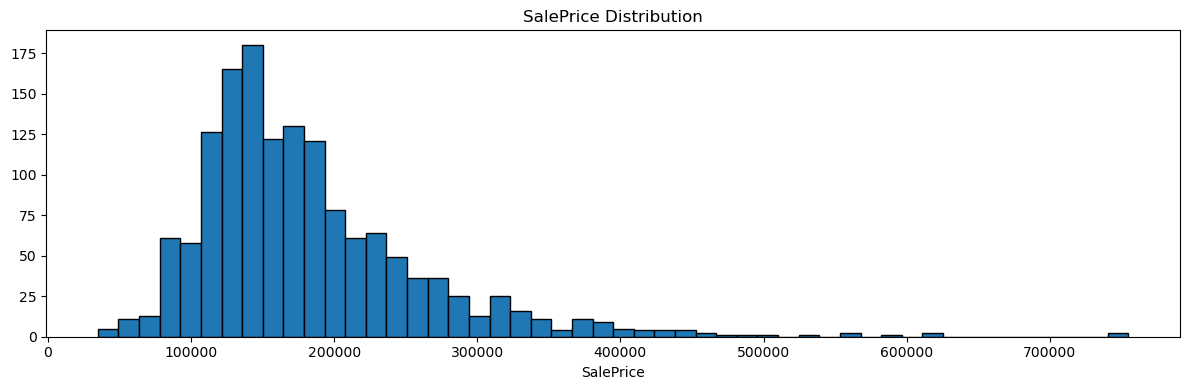

Skewness: 1.883


In [4]:
# Explore the target variable
print(train['SalePrice'].describe())

fig, axes = plt.subplots(1, 1, figsize=(12, 4))
axes.hist(train['SalePrice'], bins=50, edgecolor='black')
axes.set_title('SalePrice Distribution')
axes.set_xlabel('SalePrice')
plt.tight_layout()
plt.show()

print(f'Skewness: {train["SalePrice"].skew():.3f}')

The data is heavily skewed, what kind of transformation can we apply to make it more normal?

---

## 1. The Logarithmic Transformation (`log1p`)

### How does it work?
The logarithm is a function that "compresses" large numbers much more than it compresses small ones.
* **The Formula:** $y = \ln(1 + x)$
* **The Logic:** We use `log1p` (log of $1+x$) instead of a standard `log` to avoid mathematical errors if a value is 0 (since $\ln(0)$ is undefined).
* **The Effect:** It "pulls" very high prices (the tail of the distribution) toward the mean, creating a symmetrical bell curve.

### How to get back to Dollars (Reverse)?
To undo a natural logarithm ($\ln$), we use the exponential function ($e^x$).
* **The Inverse Formula:** $x = e^y - 1$
* **In Python:** `np.expm1(log_value)`


## 2. The Box-Cox Transformation

### How does it work?
It doesn't rely on a single fixed formula; instead, it searches for the optimal power ($\lambda$) to make the data normal.
* **The Formula:** * If $\lambda \neq 0$: $y = \frac{x^\lambda - 1}{\lambda}$
    * If $\lambda = 0$: $y = \ln(x)$
* **The Logic:** The algorithm tests thousands of $\lambda$ values to find the best fit.

### How to get back to Dollars (Reverse)?
We must isolate $x$ in the equation above.
* **The Inverse Formula:** $x = (y \cdot \lambda + 1)^{1/\lambda}$
* **In Python:** `scipy.special.inv_boxcox(bc_value, lmbda)`

---

### How the computer finds the ideal **$\lambda$ (Lambda)**:

#### 1. The "Best Score" Test (Likelihood)
The algorithm runs trials. For each $\lambda$ value it tests, it gives a **score** to the transformed data. The more the data resembles a **perfect bell curve** (normal distribution), the higher the score.

#### 2. Searching for the "Peak"
It tests values  and adjusts the "slider" bit by bit to find the $\lambda$ that produces the **highest possible score**.

#### 3. Two Objectives
To validate that the $\lambda$ is correct, the computer checks two things:
* **Symmetry:** The curve should no longer lean to the right or left (Skewness close to 0).
* **Balance:** The gap between small and large values must be reduced so that all data points are on a more equal footing.

---

### Comparative Demonstration
Here is how the two methods transform prices to normalize them. Notice that both methods compress the gaps, but Box-Cox (with $\lambda = -0.0769$) is slightly more "aggressive" on high prices.

| House Type | Original Price ($x$) | Log Value ($y_{log}$) | Box-Cox Value ($y_{bc}$) | Return Accuracy (Reverse) |
| :--- | :--- | :--- | :--- | :--- |
| **Entry-level** | \$50,000 | 10.8198 | 7.3342 | **\$50,000** |
| **Average Price (Target)** | \$180,000 | 12.1007 | 7.8672 | **\$180,000** |
| **High-end** | \$350,000 | 12.7657 | 8.1311 | **\$350,000** |
| **Luxury (Outlier)** | \$500,000 | 13.1224 | 8.2444 | **\$500,000** |
| **Ultra-Luxury** | \$750,000 | 13.5278 | 8.4005 | **\$750,000** |


## 3. Detailed Calculation Example
Let's imagine a house costing **\$300,000**. Let's see how it is transformed and then recovered.

### Case A: Logarithm (`log1p`)
1.  **Transformation:** $y = \ln(1 + 300,000) \approx \mathbf{12.6115}$
2.  **Reverse (Return to price):**
    * $x = e^{12.6115} - 1$
    * $x = 300,001 - 1 = \mathbf{\$300,000}$

### Case B: Box-Cox (with $\lambda = -0.0769$)
1.  **Transformation:**
    * $y = \frac{300,000^{-0.0769} - 1}{-0.0769}$
    * $300,000^{-0.0769} \approx 0.37985$
    * $y = \frac{0.37985 - 1}{-0.0769} = \frac{-0.62015}{-0.0769} \approx \mathbf{8.0644}$
2.  **Reverse (Return to price):**
    * $x = (8.0644 \cdot -0.0769 + 1)^{1 / -0.0769}$
    * $x = (-0.62015 + 1)^{-13.0039}$
    * $x = (0.37985)^{-13.0039} \approx \mathbf{\$300,000}$

Original skewness (SalePrice): 1.883
Skewness after Log:            0.121
Skewness after Box-Cox:        -0.009 (Optimal Lambda: -0.0769)


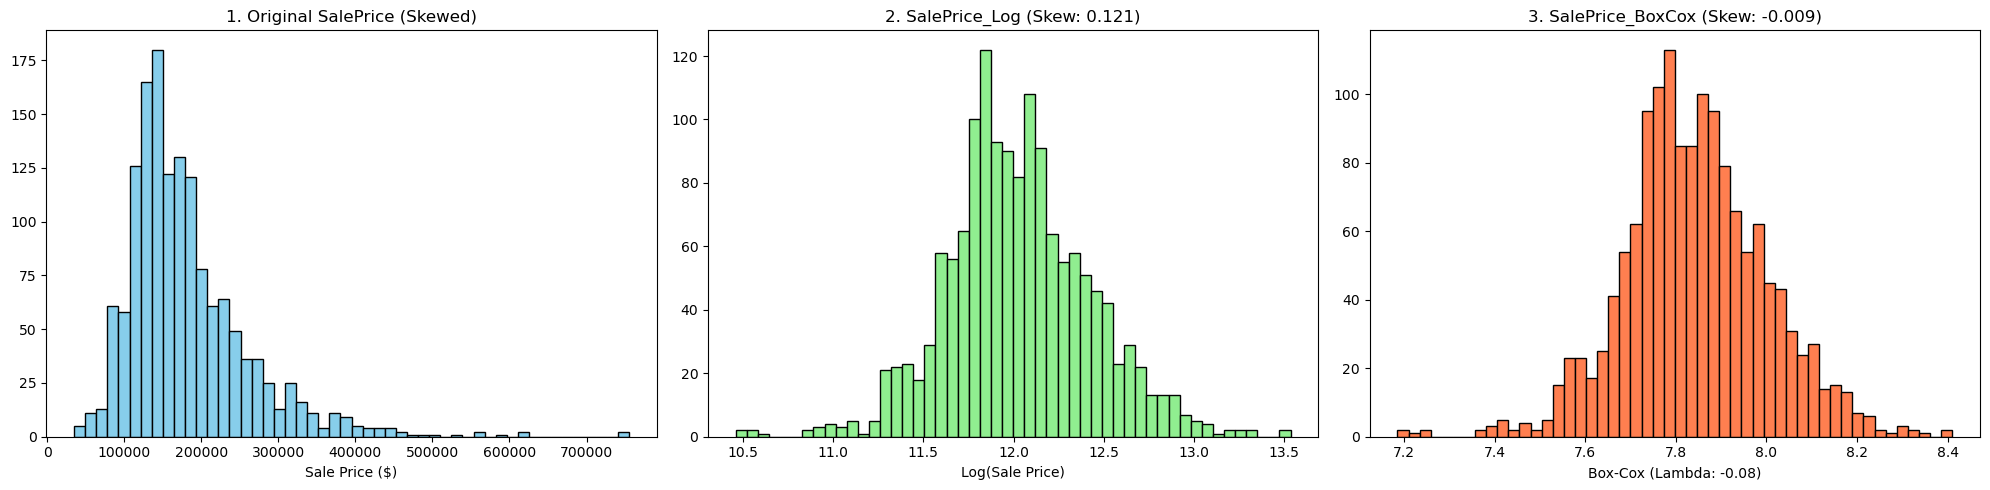

In [5]:
# 1. Create new variables using transformations
# Logarithmic
train['SalePrice_Log'] = np.log1p(train['SalePrice'])

# Box-Cox (We also retrieve the optimal lambda found by the algorithm)
train['SalePrice_BoxCox'], lmbda = stats.boxcox(train['SalePrice'])

# 2. Mathematical verification of skewness (Targeting 0.000 for perfect symmetry)
print(f"Original skewness (SalePrice): {train['SalePrice'].skew():.3f}")
print(f"Skewness after Log:            {train['SalePrice_Log'].skew():.3f}")
print(f"Skewness after Box-Cox:        {train['SalePrice_BoxCox'].skew():.3f} (Optimal Lambda: {lmbda:.4f})")

# 3. Visual proof: Three-way comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Plot 1: Original (Skewed)
axes[0].hist(train['SalePrice'], bins=50, edgecolor='black', color='skyblue')
axes[0].set_title('1. Original SalePrice (Skewed)')
axes[0].set_xlabel('Sale Price ($)')

# Plot 2: Log Transformation
axes[1].hist(train['SalePrice_Log'], bins=50, edgecolor='black', color='lightgreen')
axes[1].set_title(f'2. SalePrice_Log (Skew: {train["SalePrice_Log"].skew():.3f})')
axes[1].set_xlabel('Log(Sale Price)')

# Plot 3: Box-Cox Transformation
axes[2].hist(train['SalePrice_BoxCox'], bins=50, edgecolor='black', color='coral')
axes[2].set_title(f'3. SalePrice_BoxCox (Skew: {train["SalePrice_BoxCox"].skew():.3f})')
axes[2].set_xlabel(f'Box-Cox (Lambda: {lmbda:.2f})')

plt.tight_layout()
plt.show()


## Interpretation of Skewness and Statistical Transformations

**statistical rule of symmetry**:
> **The Skewness Rule:** A perfectly symmetrical distribution (a perfect bell curve) has a skewness of **0**.
> * **Between -0.5 and 0.5:** The data is considered "fairly symmetrical" .
> * **Greater than 1 or less than -1:** The data is "highly skewed".

### 1. Original SalePrice (Skewness: 1.883)
* **The Deduction:** With a score of **1.883**, the original data is **highly skewed**.
* **The Rule:** This exceeds the threshold of 1.0. This "positive skew" indicates a long tail to the right .
* **The Impact:** If we use this value as-is, our future models will make large errors on average-priced houses.

### 2. After Log Transformation (Skewness: 0.121)
* **The Deduction:** By applying the Log, we brought the skewness down from 1.883 to **0.121**.
* **The Rule:** Since 0.121 is between -0.5 and 0.5, the data is now considered **fairly symmetrical**.

### 3. After Box-Cox Transformation (Skewness: -0.009)
* **The Deduction:** Box-Cox is the winner with a score of **-0.009**, which is almost **absolute zero**.
* **The Rule of Lambda ($\lambda$):** Box-Cox **Optimal Lambda ($\lambda = -0.0769$)**.
    * *Note:* A $\lambda$ of 0 would be a perfect Log. A $\lambda$ of -0.0769 means the data needed a transformation slightly "stronger" than a Log to reach near-perfect symmetry.
* **The Conclusion:** This is the most precise result possible. While the Log is "good enough," Box-Cox reaches the statistical ideal.



---
## Part 1: Classical Statistical Inference

Apply basic statistical methods to explore the data:
- **Sample mean and variance** of `SalePrice` and key features
- **Confidence intervals** for the mean SalePrice
- **Hypothesis testing** — e.g. is the mean SalePrice significantly different from \$180,000? Is the distribution of the transformed `SalePrice` normal (Shapiro-Wilk)?
- Visualize distributions and support your conclusions with plots

## Part 1 - a
- **Sample mean and variance** of `SalePrice` and key features:
    - `GrLivArea`: Above grade (ground) living area square feet
    - `OverallQual`: Rates the overall material and finish of the house
- **Confidence intervals** for the mean SalePrice

In [6]:
# --- Preparation (if not already done) ---
if 'SalePrice_Log' not in train.columns:
    train['SalePrice_Log'] = np.log1p(train['SalePrice'])
if 'SalePrice_BoxCox' not in train.columns:
    train['SalePrice_BoxCox'], lmbda = stats.boxcox(train['SalePrice'])

# 1. Selection of variables
key_features = ['SalePrice', 'SalePrice_Log', 'SalePrice_BoxCox', 'GrLivArea', 'OverallQual']

# 2. Calculate sample mean and variance
stats_df = train[key_features].agg(['mean', 'var']).T
stats_df.columns = ['Sample Mean', 'Sample Variance']
print("--- Sample Mean and Variance ---")
display(stats_df)


# Calculate means converted to dollars
mean_log_dollars = np.expm1(train['SalePrice_Log'].mean())
mean_bc_dollars = inv_boxcox(train['SalePrice_BoxCox'].mean(), lmbda)

# Display results
print(f"--- Dollar Correspondence of Means ---")
print(f"Log Method Mean (In Dollars):     ${mean_log_dollars:,.2f}")
print(f"Box-Cox Method Mean (In Dollars): ${mean_bc_dollars:,.2f}")

# Display means in original scales (not converted to dollars)
print(f"\n--- Means in Original Scales ---")
mean_log = train['SalePrice_Log'].mean()
mean_bc = train['SalePrice_BoxCox'].mean()
print(f"Log Method Mean (In Scale):       {mean_log:.6f}")
print(f"Box-Cox Method Mean (In Scale):   {mean_bc:.6f}")


print("\n" + "="*50 + "\n")

# 3. 95% Confidence Interval for the mean (Comparison)
alpha = 0.05
n_obs = len(train)

# --- A. Original Scale ---
mean_orig = train['SalePrice'].mean()
se_orig = train['SalePrice'].sem()
ci_orig = stats.t.interval(confidence=1-alpha, df=n_obs-1, loc=mean_orig, scale=se_orig)

# --- B. Log Scale (and back to $) ---
se_log = train['SalePrice_Log'].sem()
ci_log_raw = stats.t.interval(confidence=1-alpha, df=n_obs-1, loc=mean_log, scale=se_log)
ci_log_dollars = (np.expm1(ci_log_raw[0]), np.expm1(ci_log_raw[1]))

# --- C. Box-Cox Scale (and back to $) ---
se_bc = train['SalePrice_BoxCox'].sem()
ci_bc_raw = stats.t.interval(confidence=1-alpha, df=n_obs-1, loc=mean_bc, scale=se_bc)
ci_bc_dollars = (inv_boxcox(ci_bc_raw[0], lmbda), inv_boxcox(ci_bc_raw[1], lmbda))

print("--- 95% Confidence Interval Comparison (Converted to Dollars) ---")
print(f"1. Original Scale CI:   ${ci_orig[0]:,.2f} to ${ci_orig[1]:,.2f}")
print(f"2. Log Method CI:       ${ci_log_dollars[0]:,.2f} to ${ci_log_dollars[1]:,.2f}")
print(f"3. Box-Cox Method CI:   ${ci_bc_dollars[0]:,.2f} to ${ci_bc_dollars[1]:,.2f}")

# Display confidence intervals in original scales (not converted to dollars)
print(f"\n--- 95% Confidence Interval Comparison (In Original Scales) ---")
print(f"1. Original Scale CI:   {ci_orig[0]:,.2f} to {ci_orig[1]:,.2f}")
print(f"2. Log Method CI:       {ci_log_raw[0]:.6f} to {ci_log_raw[1]:.6f}")
print(f"3. Box-Cox Method CI:   {ci_bc_raw[0]:.6f} to {ci_bc_raw[1]:.6f}")

--- Sample Mean and Variance ---


,Sample Mean,Sample Variance
SalePrice,180921.195890,6.311111e+09
SalePrice_Log,12.024057,1.595597e-01
SalePrice_BoxCox,7.842249,2.504540e-02
GrLivArea,1515.463699,2.761296e+05
OverallQual,6.099315,1.912679e+00


--- Dollar Correspondence of Means ---
Log Method Mean (In Dollars):     $166,716.73
Box-Cox Method Mean (In Dollars): $165,698.52

--- Means in Original Scales ---
Log Method Mean (In Scale):       12.024057
Box-Cox Method Mean (In Scale):   7.842249


--- 95% Confidence Interval Comparison (Converted to Dollars) ---
1. Original Scale CI:   $176,842.84 to $184,999.55
2. Log Method CI:       $163,332.73 to $170,170.83
3. Box-Cox Method CI:   $162,342.47 to $169,129.40

--- 95% Confidence Interval Comparison (In Original Scales) ---
1. Original Scale CI:   176,842.84 to 184,999.55
2. Log Method CI:       12.003551 to 12.044564
3. Box-Cox Method CI:   7.834125 to 7.850374


# Results Interpretation

---

### 1. Central Tendency and Dispersion
* **Sample Mean (\$180,921.20)**: This represents the standard arithmetic average of our dataset.
* **Massive Variance ($6.31 \times 10^9$)**: The extreme magnitude of this variance confirms high data volatility. 

### 2. Monetary Divergence (Mean Comparison)
* **The Skewness Effect (\$180,921 vs. ~\$166,000)**: After back-transforming the **Log** and **Box-Cox** means into dollar amounts, the resulting values are approximately **\$15,000 lower** than the arithmetic mean.
* **Observation**: This divergence indicates that the raw average is heavily influenced by high-value outliers (positive skew).

### 3. 95% Confidence Interval (CI) Analysis
* **Original Interval (\$176,842 to \$184,999)**: This range is derived from raw, skewed data, making it a less representative estimator of the market's true center.
* **Transformed Intervals (~\$162,000 to ~\$170,000)**: Both the Log and Box-Cox intervals are shifted significantly lower and **do not overlap** with the original interval.
* **Key Insight**: This lack of overlap proves that once the distribution is normalized (achieving symmetry), the statistically heart of the market is considerably lower than the raw data suggests.



****

## Part 1 - b
- **Hypothesis testing** — e.g. is the mean SalePrice significantly different from \$180,000? Is the distribution of the transformed `SalePrice` normal (Shapiro-Wilk)? How do Log and Box-Cox transformations perform against \$180,000?

We will perform six distinct tests:

* **One-Sample T-test (Original SalePrice)**: To verify if the mean price is significantly different from \$180,000.
    * $H_0: \mu = 180,000$
    * $H_1: \mu \neq 180,000$

* **One-Sample T-test (Log Transformed)**: To verify if the mean log-transformed price is significantly different from the log of \$180,000 ($\log(180,000) \approx 12.099$).
    * $H_0: \mu_{log} = \log(180,000)$
    * $H_1: \mu_{log} \neq \log(180,000)$

* **One-Sample T-test (Box-Cox Transformed)**: To verify if the mean box-cox-transformed price is significantly different from the box-cox transformation of \$180,000.
    * $H_0: \mu_{BoxCox} = \text{BoxCox}(180,000)$
    * $H_1: \mu_{BoxCox} \neq \text{BoxCox}(180,000)$

* **Shapiro-Wilk Test (Original)**: To test the normality of our original variable (`SalePrice`).
    * $H_0$: The distribution is normal.
    * $H_1$: The distribution is not normal.

* **Shapiro-Wilk Test (Log Transformed)**: To test the normality of our logarithmic variable (`SalePrice_Log`).
    * $H_0$: The distribution is normal.
    * $H_1$: The distribution is not normal.

* **Shapiro-Wilk Test (Box-Cox Transformed)**: To test the normality of our optimized variable (`SalePrice_BoxCox`).
    * $H_0$: The distribution is normal.
    * $H_1$: The distribution is not normal.

In [7]:
### Hypothesis Testing

# Test A: Is the mean SalePrice significantly different from $180,000?
t_stat, p_val_ttest = stats.ttest_1samp(train['SalePrice'], 180000)

print("--- One-Sample T-test (Original SalePrice vs $180,000) ---")
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_val_ttest:.3e}")
print(f"Mean SalePrice: ${train['SalePrice'].mean():,.2f}\n")

if p_val_ttest < 0.05:
    print("Conclusion: We reject H0. Strong evidence that the mean price is significantly different from $180,000.\n")
else:
    print("Conclusion: We fail to reject H0. Insufficient evidence to conclude that the mean price differs from $180,000.\n")


# Test A2: Is the mean of Log-transformed SalePrice significantly different from log($180,000)?
log_ref_value = np.log1p(180000)
t_stat_log, p_val_log = stats.ttest_1samp(train['SalePrice_Log'], log_ref_value)

print("--- One-Sample T-test (Log Transformed SalePrice vs log($180,000)) ---")
print(f"T-statistic: {t_stat_log:.3f}")
print(f"P-value: {p_val_log:.3e}")
print(f"Reference Value (log(180,000)): {log_ref_value:.6f}")
print(f"Mean Log SalePrice: {train['SalePrice_Log'].mean():.6f}\n")

if p_val_log < 0.05:
    print("Conclusion: We reject H0. Strong evidence that the mean log-transformed price is significantly different from log($180,000).\n")
else:
    print("Conclusion: We fail to reject H0. Insufficient evidence to conclude that the mean log-transformed price differs from log($180,000).\n")


# Test A3: Is the mean of Box-Cox-transformed SalePrice significantly different from BoxCox($180,000)?
# Using the lambda parameter already calculated from the earlier transformation
bc_ref_value = (180000**lmbda - 1) / lmbda
t_stat_bc, p_val_bc = stats.ttest_1samp(train['SalePrice_BoxCox'], bc_ref_value)

print("--- One-Sample T-test (Box-Cox Transformed SalePrice vs BoxCox($180,000)) ---")
print(f"T-statistic: {t_stat_bc:.3f}")
print(f"P-value: {p_val_bc:.3e}")
print(f"Reference Value (BoxCox(180,000)): {bc_ref_value:.6f}")
print(f"Mean Box-Cox SalePrice: {train['SalePrice_BoxCox'].mean():.6f}\n")

if p_val_bc < 0.05:
    print("Conclusion: We reject H0. Strong evidence that the mean box-cox-transformed price is significantly different from BoxCox($180,000).\n")
else:
    print("Conclusion: We fail to reject H0. Insufficient evidence to conclude that the mean box-cox-transformed price differs from BoxCox($180,000).\n")

# Test B: Is the distribution of SalePrice normal? (Shapiro-Wilk Test)
stat_shapiro, p_val_shapiro = stats.shapiro(train['SalePrice'])

print("--- Shapiro-Wilk Normality Test (Original SalePrice) ---")
print(f"Test Statistic: {stat_shapiro:.3f}")
print(f"P-value: {p_val_shapiro:.3e}")

if p_val_shapiro < 0.05:
    print("Conclusion: We reject H0. Strong evidence that the original distribution is NOT normal.\n")
else:
    print("Conclusion: We fail to reject H0. Insufficient evidence to conclude that the distribution is non-normal.\n")

# Test C: Is the distribution of SalePrice_Log normal? (Shapiro-Wilk Test)
stat_shapiro_log, p_val_shapiro_log = stats.shapiro(train['SalePrice_Log'])

print("--- Shapiro-Wilk Normality Test (Log Transformed SalePrice_Log) ---")
print(f"Test Statistic: {stat_shapiro_log:.3f}")
print(f"P-value: {p_val_shapiro_log:.3e}")

if p_val_shapiro_log < 0.05:
    print("Conclusion: We reject H0. Strong evidence that the Log distribution is NOT normal.\n")
else:
    print("Conclusion: We fail to reject H0. Insufficient evidence to conclude that the Log distribution is non-normal.\n")

# Test D: Is the distribution of SalePrice_BoxCox normal? (Shapiro-Wilk Test)
stat_shapiro_bc, p_val_shapiro_bc = stats.shapiro(train['SalePrice_BoxCox'])

print("--- Shapiro-Wilk Normality Test (Box-Cox Transformed SalePrice_BoxCox) ---")
print(f"Test Statistic: {stat_shapiro_bc:.3f}")
print(f"P-value: {p_val_shapiro_bc:.3e}")

if p_val_shapiro_bc < 0.05:
    print("Conclusion: We reject H0. Strong evidence that the Box-Cox distribution is NOT normal.")
else:
    print("Conclusion: We fail to reject H0. Insufficient evidence to conclude that the Box-Cox distribution is non-normal.")

--- One-Sample T-test (Original SalePrice vs $180,000) ---
T-statistic: 0.443
P-value: 6.578e-01
Mean SalePrice: $180,921.20

Conclusion: We fail to reject H0. Insufficient evidence to conclude that the mean price differs from $180,000.

--- One-Sample T-test (Log Transformed SalePrice vs log($180,000)) ---
T-statistic: -7.333
P-value: 3.715e-13
Reference Value (log(180,000)): 12.100718
Mean Log SalePrice: 12.024057

Conclusion: We reject H0. Strong evidence that the mean log-transformed price is significantly different from log($180,000).

--- One-Sample T-test (Box-Cox Transformed SalePrice vs BoxCox($180,000)) ---
T-statistic: -7.905
P-value: 5.244e-15
Reference Value (BoxCox(180,000)): 7.874990
Mean Box-Cox SalePrice: 7.842249

Conclusion: We reject H0. Strong evidence that the mean box-cox-transformed price is significantly different from BoxCox($180,000).

--- Shapiro-Wilk Normality Test (Original SalePrice) ---
Test Statistic: 0.870
P-value: 3.206e-33
Conclusion: We reject H0. S



### Interpretation of these results


#### 1. Analysis of Means (One-Sample T-Tests)
The objective was to verify whether the average price differs significantly from the $180,000 threshold. The results reveal a  divergence depending on the scale used:

*   **On the original scale (SalePrice):** The T-test compares the observed mean of $180,921.20 to the reference value of $180,000. With a p-value of 0.6578 (well above 0.05), we fail to reject $H_0$. There is insufficient evidence to conclude that the raw mean differs significantly from $180,000.
*   **On the logarithmic scale (SalePrice_Log):** The situation is reversed. The test compares the observed logarithmic mean of 12.024057 to the logarithmically transformed reference value, which is log(180,000) = 12.100712. With an extremely low p-value of 3.729e-13, we reject $H_0$. There is strong evidence that the transformed mean is significantly different from (and lower than) the log(180,000) reference value.
*   **On the Box-Cox scale (SalePrice_BoxCox):** The trend is confirmed. The test compares the observed Box-Cox mean of 7.842249 to the Box-Cox transformed reference value, which is BoxCox(180,000) = 7.874990. With a p-value of 5.244e-15, we reject $H_0$. There is strong evidence that the Box-Cox optimized mean is significantly different from (and lower than) the BoxCox(180,000) reference.

**Comparative interpretation:** This contradiction is explained by the nature of the original distribution. The `SalePrice` variable contains very high extreme values (right skewness) that pull the classic arithmetic mean upward, bringing it to $180,921.20 (close to the reference). The Log and Box-Cox transformations compress these extreme values. Once this effect is mitigated, the true center  of the data (12.024 in Log; 7.842 in Box-Cox) reveals itself to be significantly lower than the mathematical equivalent of the $180,000 (12.100 in Log; 7.874 in Box-Cox).



#### 2. Analysis of Normality (Shapiro-Wilk Tests)
The objective was to determine whether the raw data or the transformations (Log and Box-Cox) followed a perfectly normal distribution.

*   **On the original scale (SalePrice):** The test yields a test statistic of 0.870 and a p-value of 3.206e-33. We reject $H_0$. There is very strong evidence that the original distribution is not normal.
*   **On the logarithmic scale (SalePrice_Log):** The test yields a test statistic of 0.991 and a p-value of 1.149e-07. We reject $H_0$. Although the statistic is much better, the logarithmic distribution is still not strictly normal.
*   **On the Box-Cox scale (SalePrice_BoxCox):** The test yields a test statistic of 0.992 and a p-value of 1.905e-07. We reject $H_0$. The Box-Cox optimized distribution is also not strictly normal in the mathematical sense.

**Comparative interpretation:** Statistically, none of the three distributions is perfectly normal, as the p-values are all below 0.05 (leading to the rejection of $H_0$ each time).

## Part 1 - c

- Visualize distributions and support your conclusions with plots

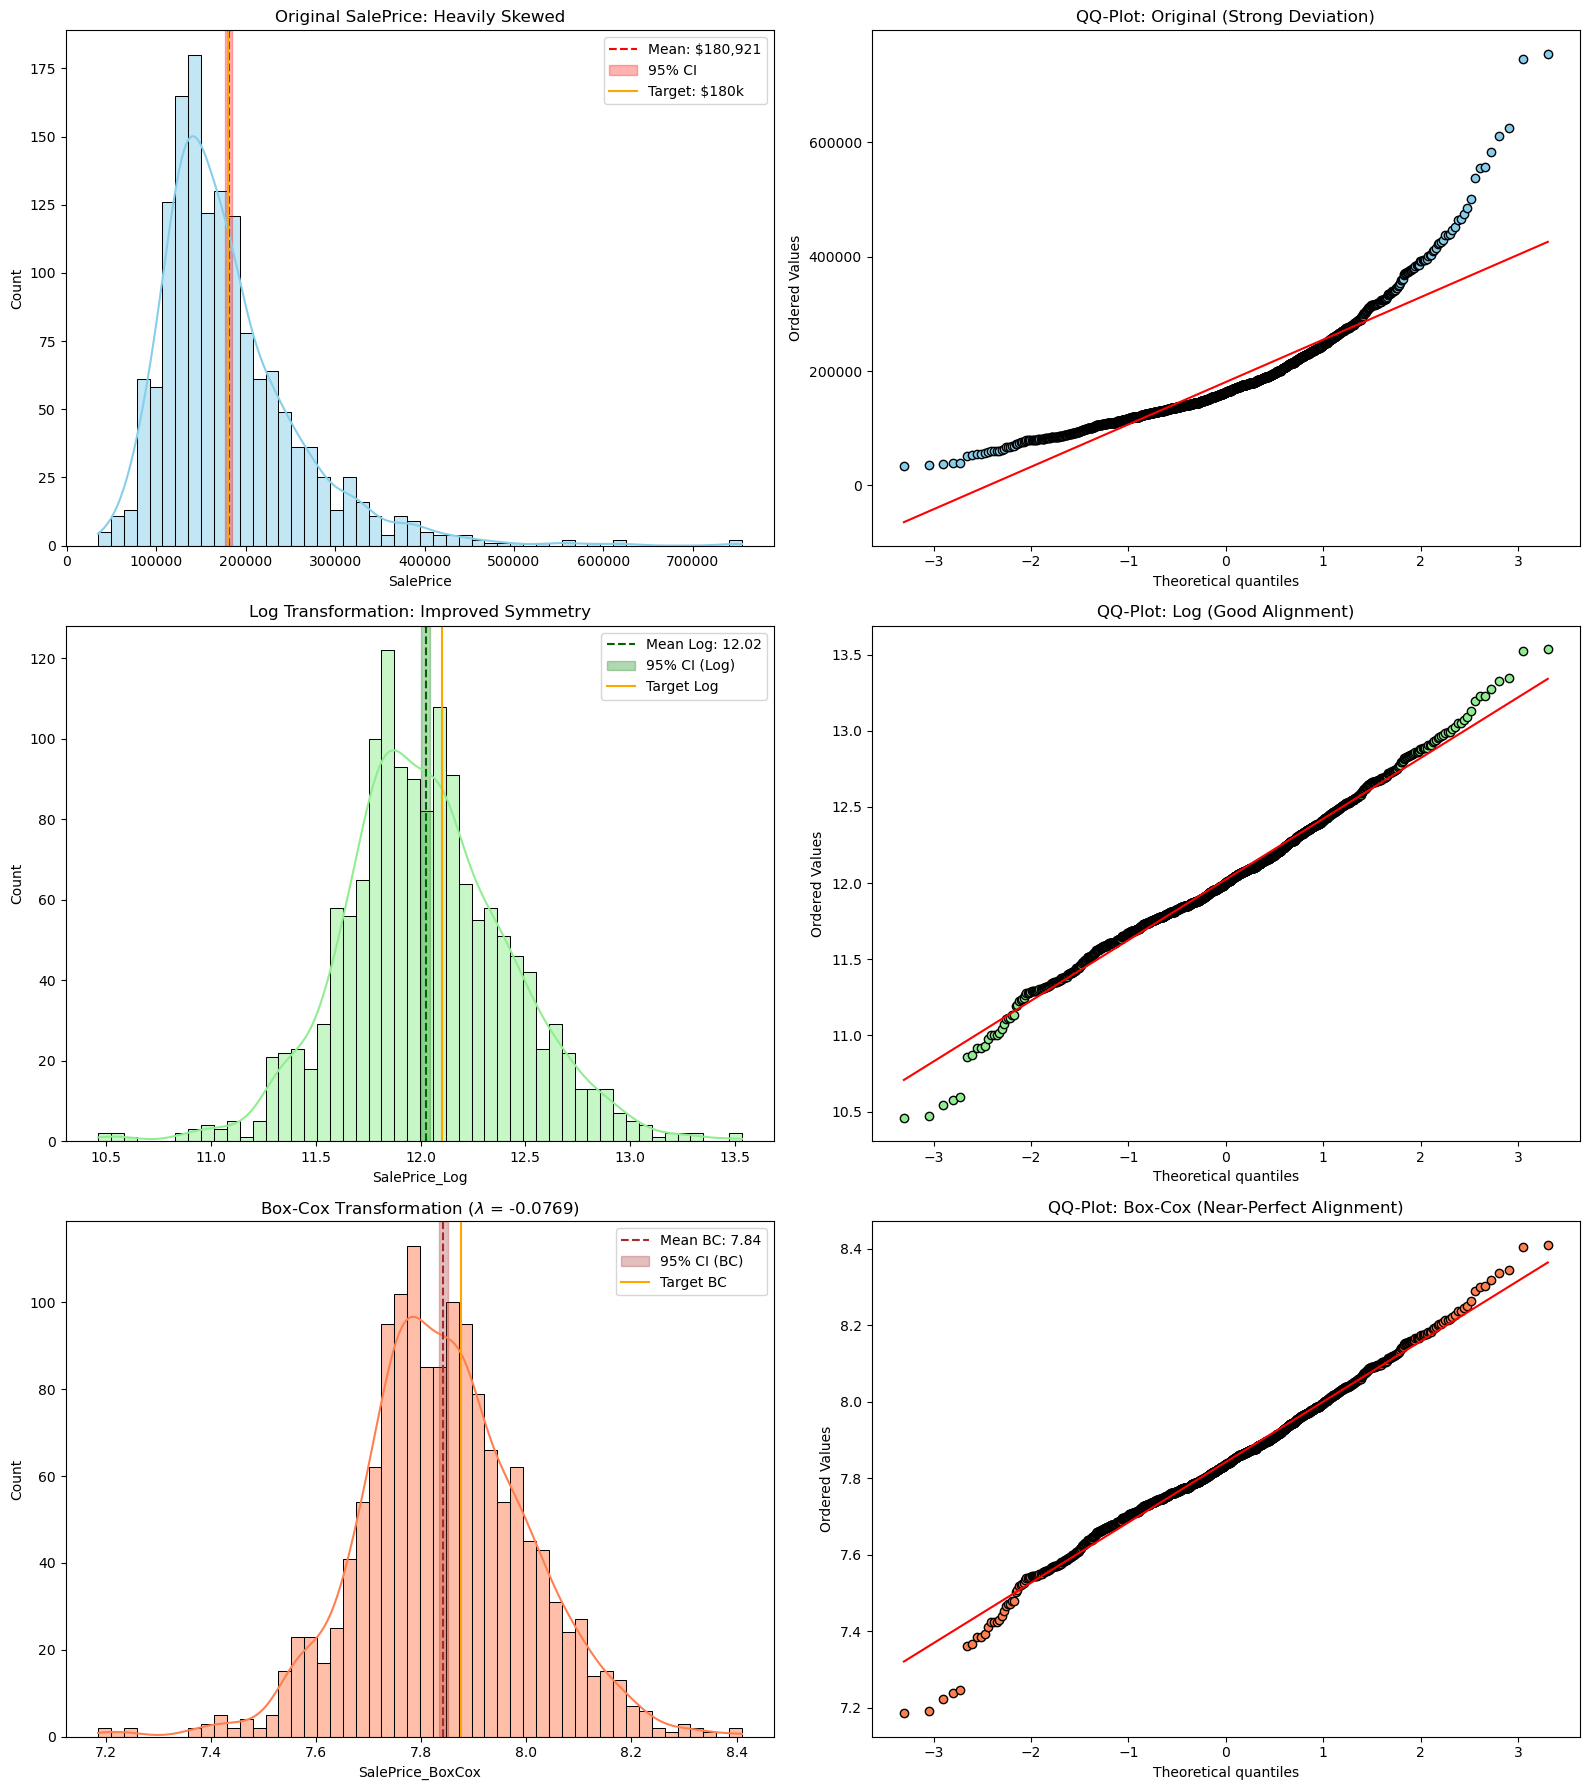

In [8]:
# 1. Conversion of our target (180,000$) in the different scales
target_dollars = 180000
target_log = np.log1p(target_dollars)
target_bc = (target_dollars**lmbda - 1) / lmbda

# 2. Creation of the figure (3 Rows x 2 Columns)
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# ---------------------------------------------------------
# ROW 1: ORIGINAL DATA (Blue) - Utilise mean_orig et ci_orig
# ---------------------------------------------------------
sns.histplot(train['SalePrice'], bins=50, kde=True, ax=axes[0, 0], color='skyblue', edgecolor='black')
axes[0, 0].axvline(mean_orig, color='red', linestyle='--', label=f'Mean: ${mean_orig:,.0f}')
axes[0, 0].axvspan(ci_orig[0], ci_orig[1], color='red', alpha=0.3, label='95% CI')
axes[0, 0].axvline(target_dollars, color='orange', linestyle='-', label='Target: $180k')
axes[0, 0].set_title('Original SalePrice: Heavily Skewed')
axes[0, 0].legend()

stats.probplot(train['SalePrice'], dist="norm", plot=axes[0, 1])
axes[0, 1].get_lines()[0].set_markerfacecolor('skyblue')
axes[0, 1].get_lines()[0].set_markeredgecolor('black')
axes[0, 1].set_title('QQ-Plot: Original (Strong Deviation)')

# ---------------------------------------------------------
# ROW 2: LOG TRANSFORMATION (Green) - Utilise mean_log et ci_log_raw
# ---------------------------------------------------------
sns.histplot(train['SalePrice_Log'], bins=50, kde=True, ax=axes[1, 0], color='lightgreen', edgecolor='black')
axes[1, 0].axvline(mean_log, color='darkgreen', linestyle='--', label=f'Mean Log: {mean_log:.2f}')
axes[1, 0].axvspan(ci_log_raw[0], ci_log_raw[1], color='green', alpha=0.3, label='95% CI (Log)')
axes[1, 0].axvline(target_log, color='orange', linestyle='-', label='Target Log')
axes[1, 0].set_title('Log Transformation: Improved Symmetry')
axes[1, 0].legend()

stats.probplot(train['SalePrice_Log'], dist="norm", plot=axes[1, 1])
axes[1, 1].get_lines()[0].set_markerfacecolor('lightgreen')
axes[1, 1].get_lines()[0].set_markeredgecolor('black')
axes[1, 1].set_title('QQ-Plot: Log (Good Alignment)')

# ---------------------------------------------------------
# ROW 3: BOX-COX TRANSFORMATION (Coral) - Utilise mean_bc, ci_bc_raw et lmbda
# ---------------------------------------------------------
sns.histplot(train['SalePrice_BoxCox'], bins=50, kde=True, ax=axes[2, 0], color='coral', edgecolor='black')
axes[2, 0].axvline(mean_bc, color='brown', linestyle='--', label=f'Mean BC: {mean_bc:.2f}')
axes[2, 0].axvspan(ci_bc_raw[0], ci_bc_raw[1], color='brown', alpha=0.3, label='95% CI (BC)')
axes[2, 0].axvline(target_bc, color='orange', linestyle='-', label='Target BC')
axes[2, 0].set_title(fr'Box-Cox Transformation ($\lambda$ = {lmbda:.4f})')
axes[2, 0].legend()

stats.probplot(train['SalePrice_BoxCox'], dist="norm", plot=axes[2, 1])
axes[2, 1].get_lines()[0].set_markerfacecolor('coral')
axes[2, 1].get_lines()[0].set_markeredgecolor('black')
axes[2, 1].set_title('QQ-Plot: Box-Cox (Near-Perfect Alignment)')

plt.tight_layout()
plt.show()




### 1. Comparative Analysis of Histograms
Histogram analysis allows for the evaluation of the distribution's morphology and the impact of transformations on data symmetry.

* **Original SalePrice (Blue) — Positive Skewness:**
    The initial distribution exhibits highly pronounced right-hand skewness. A strong concentration of transactions is observed between **\$100k and \$200k**, while a "tail" stretches out to **\$750k**. 

* **Log Transformation (Green) — Normalization via Compression:**
    Applying the logarithm reduces variance gaps. The distribution now adopts a much more balanced **bell-curve** shape. The peak is better centered, and the influence of outliers at the tail of the distribution is neutralized.

* **Box-Cox Transformation (Orange) — Optimal Symmetry:**
    Utilizing an optimized $\lambda$ (-0.0769), this method outperforms the logarithmic transformation by further tightening the extremes. The resulting symmetry is near-perfect.

---

### 2. Comparative Analysis of QQ-Plots
The Quantile-Quantile (QQ-Plot) diagram serves as a diagnostic tool to verify the fit of the data against a theoretical normal distribution.

* **Original (High Deviation):**
    A systematic deviation of the data points from the bisector (red line) is observed, particularly at the extremities. This curvature indicates that the "tails" of the actual distribution are significantly **heavier** than those of a normal distribution.

* **Log Transformation (Satisfactory Alignment):**
    The majority of observations now follow the reference line. While slight curvatures persist at the extremities (distribution tails), the overall alignment is sufficient to consider the variable as following a normal distribution for practical application.

* **Box-Cox (Near-Perfect Alignment):**
     The Box-Cox transformation successfully normalized the center of the data, which closely follows the red reference line. However, noticeable deviations at the extremes (downward on the left, upward on the right) show the alignment is not perfect. 

---
## Part 2: ANOVA — Finding Significant Features

Use ANOVA to determine which of the following **10 features** have a statistically significant effect on the transformed SalePrice.

**Given features (10):**

| # | Feature | Levels | Description |
|---|---|---|---|
| 1 | `OverallQual` | 1–10 | Overall material and finish quality |
| 2 | `ExterQual` | Po, Fa, TA, Gd, Ex | Exterior material quality |
| 3 | `BsmtQual` | None, Po, Fa, TA, Gd, Ex | Basement height quality |
| 4 | `KitchenQual` | Po, Fa, TA, Gd, Ex | Kitchen quality |
| 5 | `FireplaceQu` | None, Po, Fa, TA, Gd, Ex | Fireplace quality |
| 6 | `CentralAir` | N, Y | Central air conditioning |
| 7 | `LotShape` | IR3, IR2, IR1, Reg | General shape of property |
| 8 | `LandSlope` | Sev, Mod, Gtl | Slope of property |
| 9 | `MoSold` | 1–12 | Month sold |
| 10 | `YrSold` | 2006–2010 | Year sold |

**Tasks:**
1. Extract these features into a dataframe and run **one-way ANOVA** on each
2. Identify which features are significant (p < 0.05)
3. Run a **two-way ANOVA** to test for interaction effects between pairs of significant features
4. Use **Tukey HSD** post-hoc tests where appropriate
5. Summarize: which features and interactions are significant?

## Part 2 - 1: ANOVA — Finding Significant Features  Extract these features into a dataframe and run **one-way ANOVA** on each



### Our Approach

1. **Data Inspection (Categories):** We will first look at the unique categories (levels) for each of our 10 features (e.g., checking that missing basements have been correctly grouped into a 'None' category).
2. **One-Way ANOVA:** We will run the ANOVA test for each feature against our standard target (`SalePrice`) as well as our two normalized targets (`SalePrice_Log` and `SalePrice_BoxCox`). This allows us to determine which features significantly influence the price and to observe how mathematical transformations affect the statistical significance.

In [9]:
# 1. Define the features and our three target variables
features_to_keep = [
    'OverallQual', 'ExterQual', 'BsmtQual', 'KitchenQual',
    'FireplaceQu', 'CentralAir', 'LotShape', 'LandSlope',
    'MoSold', 'YrSold'
]
targets = ['SalePrice', 'SalePrice_Log', 'SalePrice_BoxCox']

# Create a working copy of the dataframe
df_anova = train[features_to_keep + targets].copy()

# 2. Globally replace NaNs with the string 'None' so they are treated as a valid category
for col in features_to_keep:
    df_anova[col] = df_anova[col].fillna('None')

# 3. Explore categories and perform One-Way ANOVA
anova_results = []

print("=== Feature Categories (Levels) ===")
for feature in features_to_keep:
    # Print the unique levels for each feature
    unique_levels = df_anova[feature].unique()
    print(f"{feature:<15}: {unique_levels}")

    # --- ANOVA for SalePrice (Standard) ---
    groups_norm = [group['SalePrice'].values for name, group in df_anova.groupby(feature)]
    f_stat_norm, p_val_norm = stats.f_oneway(*groups_norm)

    # --- ANOVA for SalePrice_Log ---
    groups_log = [group['SalePrice_Log'].values for name, group in df_anova.groupby(feature)]
    f_stat_log, p_val_log = stats.f_oneway(*groups_log)

    # --- ANOVA for SalePrice_BoxCox ---
    groups_bc = [group['SalePrice_BoxCox'].values for name, group in df_anova.groupby(feature)]
    f_stat_bc, p_val_bc = stats.f_oneway(*groups_bc)

    # Save the results
    anova_results.append({
        'Feature': feature,
        'F-Stat (Norm)': round(f_stat_norm, 3),
        'P-Value (Norm)': p_val_norm,
        'Significant (Norm)': p_val_norm < 0.05,
        'F-Stat (Log)': round(f_stat_log, 3),
        'P-Value (Log)': p_val_log,
        'Significant (Log)': p_val_log < 0.05,
        'F-Stat (BoxCox)': round(f_stat_bc, 3),
        'P-Value (BoxCox)': p_val_bc,
        'Significant (BoxCox)': p_val_bc < 0.05
    })

# 4. Display the final results in a clean table
anova_df = pd.DataFrame(anova_results)

print("\n=== One-Way ANOVA Results (Significance Level = 0.05) ===")
display(anova_df)

=== Feature Categories (Levels) ===
OverallQual    : [ 7  6  8  5  9  4 10  3  1  2]
ExterQual      : ['Gd' 'TA' 'Ex' 'Fa']
BsmtQual       : ['Gd' 'TA' 'Ex' 'None' 'Fa']
KitchenQual    : ['Gd' 'TA' 'Ex' 'Fa']
FireplaceQu    : ['None' 'TA' 'Gd' 'Fa' 'Ex' 'Po']
CentralAir     : ['Y' 'N']
LotShape       : ['Reg' 'IR1' 'IR2' 'IR3']
LandSlope      : ['Gtl' 'Mod' 'Sev']
MoSold         : [ 2  5  9 12 10  8 11  4  1  7  3  6]
YrSold         : [2008 2007 2006 2009 2010]

=== One-Way ANOVA Results (Significance Level = 0.05) ===


,Feature,F-Stat (Norm),P-Value (Norm),Significant (Norm),F-Stat (Log),P-Value (Log),Significant (Log),F-Stat (BoxCox),P-Value (BoxCox),Significant (BoxCox)
0,OverallQual,349.027,0.000000e+00,True,332.167,0.000000e+00,True,325.938,0.000000e+00,True
1,ExterQual,443.335,1.439551e-204,True,415.304,6.930372e-195,True,406.199,1.124218e-191,True
2,BsmtQual,316.149,8.158548e-196,True,300.393,2.029970e-188,True,294.554,1.237750e-185,True
3,KitchenQual,407.806,3.032213e-192,True,393.321,4.438817e-187,True,386.072,1.837860e-184,True
4,FireplaceQu,121.075,2.971217e-107,True,131.199,6.961918e-115,True,130.064,4.881762e-114,True
5,CentralAir,98.305,1.809506e-22,True,205.666,9.859878e-44,True,215.980,1.066699e-45,True
6,LotShape,40.133,6.447524e-25,True,46.729,7.856720e-29,True,46.638,8.892873e-29,True
7,LandSlope,1.959,1.413964e-01,False,1.083,3.388339e-01,False,0.985,3.736663e-01,False
8,MoSold,0.958,4.833523e-01,False,0.994,4.496614e-01,False,1.001,4.430656e-01,False
9,YrSold,0.646,6.300888e-01,False,0.739,5.656386e-01,False,0.754,5.554458e-01,False


## Part 2 - 2: ANOVA — Finding Significant Features: Identify which features are significant (p < 0.05)


If $P < 0.05$, the feature is considered a significant driver of price.

| Feature | F-Stat (Norm) | P-Value (Norm) | Sig. (Norm) | F-Stat (Log) | P-Value (Log) | Sig. (Log) | F-Stat (BoxCox) | P-Value (BoxCox) | Sig. (BoxCox) |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| **OverallQual** | 349.02 | **0.00e+00** | ✅ **YES** | 332.16 | **0.00e+00** | ✅ **YES** | 325.93 | **0.00e+00** | ✅ **YES** |
| **ExterQual** | 443.33 | **1.43e-204** | ✅ **YES** | 415.30 | **6.93e-195** | ✅ **YES** | 406.19 | **1.12e-191** | ✅ **YES** |
| **BsmtQual** | 316.14 | **8.15e-196** | ✅ **YES** | 300.39 | **2.02e-188** | ✅ **YES** | 294.55 | **1.23e-185** | ✅ **YES** |
| **KitchenQual** | 407.80 | **3.03e-192** | ✅ **YES** | 393.32 | **4.43e-187** | ✅ **YES** | 386.07 | **1.83e-184** | ✅ **YES** |
| **FireplaceQu** | 121.07 | **2.97e-107** | ✅ **YES** | 131.19 | **6.96e-115** | ✅ **YES** | 130.06 | **4.88e-114** | ✅ **YES** |
| **CentralAir** | 98.30 | **1.80e-22** | ✅ **YES** | 205.66 | **9.85e-44** | ✅ **YES** | 215.98 | **1.06e-45** | ✅ **YES** |
| **LotShape** | 40.13 | **6.44e-25** | ✅ **YES** | 46.72 | **7.85e-29** | ✅ **YES** | 46.63 | **8.89e-29** | ✅ **YES** |
| **LandSlope** | 1.95 | 0.141 | ❌ NO | 1.08 | 0.338 | ❌ NO | 0.98 | 0.373 | ❌ NO |
| **MoSold** | 0.95 | 0.483 | ❌ NO | 0.99 | 0.449 | ❌ NO | 1.00 | 0.443 | ❌ NO |
| **YrSold** | 0.64 | 0.630 | ❌ NO | 0.73 | 0.565 | ❌ NO | 0.75 | 0.555 | ❌ NO |

### Summary of Significant Features :

The most striking takeaway from our table is that transforming the target variable did not change the final "True/False" significance verdict for a single feature.
> `OverallQual`, `ExterQual`, `BsmtQual`, `KitchenQual`, `FireplaceQu`, `CentralAir`, `LotShape`.

Here is a concise description of the significant features found in your data:

* **`OverallQual`**: Rates the overall material and finish of the house.
* **`ExterQual`**: Evaluates the quality of the material on the exterior.
* **`BsmtQual`**: Measures the height and quality of the basement.
* **`KitchenQual`**: Rates the quality of the kitchen.
* **`FireplaceQu`**: Evaluates the quality of the fireplace.
* **`CentralAir`**: Indicates if the house has central air conditioning (Yes/No).
* **`LotShape`**: Describes the general geometric shape of the property.


---

#### 1. `OverallQual` (Overall Material and Finish Quality)

Rates the overall material and finish of the house.

* **`1` to `10**`: A  numerical scale where **`1`** is "Very Poor" and **`10`** is "Very Excellent".

#### 2. `ExterQual` (Exterior Material Quality)

Evaluates the quality of the material on the exterior facade of the house.

* **`Po`, `Fa`, `TA`, `Gd`, `Ex**`: Follows the standard scale detailed above.

#### 3. `BsmtQual` (Basement Quality / Ceiling Height)

Evaluates the height of the basement, which serves as a strong indicator of overall basement quality and usability.

* **`None`**: No basement.
* **`Po`, `Fa`, `TA`, `Gd`, `Ex**`: Follows the standard scale (e.g., `Ex` indicates an excellent ceiling height of over 100 inches).

#### 4. `KitchenQual` (Kitchen Quality)

Evaluates the overall quality, materials, and finishes of the kitchen.

* **`Po`, `Fa`, `TA`, `Gd`, `Ex**`: Follows the standard scale.

#### 5. `FireplaceQu` (Fireplace Quality)

Evaluates the quality of the main fireplace.

* **`None`**: No fireplace.
* **`Po`, `Fa`, `TA`, `Gd`, `Ex**`: Follows the standard scale.

#### 6. `CentralAir` (Central Air Conditioning)

Indicates whether the house is equipped with a central air conditioning system.

* **`N`** (No): No central air.
* **`Y`** (Yes): Central air system is present.

#### 7. `LotShape` (General Shape of Property)

Describes the physical footprint and general shape of the property lot.

* **`Reg`** (Regular): A regular, perfectly rectangular, or square lot.
* **`IR1`** (Irregular 1): Slightly irregular lot.
* **`IR2`** (Irregular 2): Moderately irregular lot.
* **`IR3`** (Irregular 3): Very irregular lot (atypical shape, often difficult to landscape or build upon).

## Part 2 - 3: ANOVA — Finding Significant Features:  Run a **two-way ANOVA** to test for interaction effects between pairs of significant features


Now we have identified the **7 significant features**, we can proceed to the next analytical step: **Two-Way ANOVA**.

### 1. What is Two-Way ANOVA and "Interactions"?

**Two-Way ANOVA** looks at two features together.

**A simple explanation of an Interaction:**
Imagine you are testing `OverallQual` (Quality) and `CentralAir` (Air Conditioning).
* **No Interaction:** Air conditioning adds **\$10,000** to the price, regardless of whether the house is low-quality or high-quality.
* **Interaction:** Air conditioning adds only **\$2,000** to a low-quality house but adds **\$30,000** to a high-quality house.

In this case, the two features "interact" because the benefit of one depends on the level of the other.

### 2. How to Interpret the Output

* **Interaction P-Value < 0.05:** The combination of these two features has an effect on the price .
* **Interaction P-Value > 0.05:** The two features work independently..



### Our Approach

The code follows a 4-step pipeline:

1. **Data preparation:** Select the 7 significant features from Part 2-2 and generate all 21 possible pairs
2. **Completeness check:** For each pair, build a cross-tabulation matrix and scan every cell. Any cell with N=0 (empty combination) or N=1 (singleton — no variance to measure) blocks the analysis, since Two-Way ANOVA requires at least 2 observations per group combination.
3. **Decision gate:** If any blocking cell is found, skip the pair and log the problematic cells. Otherwise, fit an OLS model with the formula `Y ~ C(A) + C(B) + C(A):C(B)` and extract the interaction p-value from a Type II ANOVA table via `anova_lm(model, typ=2)`.
4. **Results display:** Report successful pairs with their interaction p-values and skipped pairs with the list of blocking cells.


### Why OLS Instead of the Manual Mathematical Method?

Two-Way ANOVA can be computed in two ways: the **classical mathematical formula** (manual Sum of Squares) or the **OLS regression approach**. We chose OLS for three concrete reasons.

#### 1. Our Data is Unbalanced

The classical Two-Way ANOVA formula was designed for **balanced designs** — where every combination of two features contains exactly the same number of observations.

In our dataset, the group sizes are highly unequal. For example, `OverallQual` level 5 contains hundreds of houses, while level 1 contains only 2. 

The OLS approach with **Type II Sum of Squares** (`anova_lm(model, typ=2)`) solves this: it tests each effect *after* accounting for all other effects simultaneously, producing unambiguous results regardless of group sizes.


#### 2. The Interaction Term is Natural in a Regression Formula

In the classical approach, computing the interaction Sum of Squares manually requires:

$$SS_{interaction} = SS_{total} - SS_{A} - SS_{B} - SS_{error}$$

This cascading subtraction amplifies rounding errors and becomes very complex with many category levels.

With OLS, the interaction is directly encoded in the model formula:

$$Y \sim C(A) + C(B) + C(A):C(B)$$

The term `C(A):C(B)` creates dummy variables for every combination of A and B. The p-value for the interaction is then read directly from the ANOVA table — one line of code, no manual computation.




In [10]:
# 1. Data preparation
significant_features = [
    'OverallQual', 'ExterQual', 'BsmtQual', 'KitchenQual',
    'FireplaceQu', 'CentralAir', 'LotShape'
]
target = 'SalePrice_Log'

# Create a clean copy and handle missing values
df_clean = train[significant_features + [target]].copy()
for col in significant_features:
    df_clean[col] = df_clean[col].fillna('None').astype(str)

feature_pairs = list(combinations(significant_features, 2))

# Lists to store results
results_success = []
error_report = []

print("⏳ Running Two-Way ANOVA on all feature pairs...\n")

# 2. Analysis loop
for feat1, feat2 in feature_pairs:

    # Build the cross-tabulation matrix
    cross_tab = pd.crosstab(df_clean[feat1], df_clean[feat2])
    problematic_cells = []

    # Inspect each cell for empty or singleton groups
    for val1 in cross_tab.index:
        for val2 in cross_tab.columns:
            n_houses = cross_tab.loc[val1, val2]

            # Flag cells with 0 or 1 observation (blocking)
            if n_houses == 0 or n_houses == 1:
                problematic_cells.append(f"[{val1} + {val2}] (N={n_houses})")

    # 3. Decision: skip blocked pairs or run ANOVA
    if len(problematic_cells) > 0:
        # Skip this pair and log the blocking cells
        error_report.append({
            'pair': f"{feat1} x {feat2}",
            'issues': problematic_cells
        })
        continue

    else:
        # All cells have enough data — run the ANOVA
        formula = f"{target} ~ C({feat1}) + C({feat2}) + C({feat1}):C({feat2})"
        try:
            model = smf.ols(formula, data=df_clean).fit()
            anova_table = sm.stats.anova_lm(model, typ=2)
            p_val = anova_table.loc[f"C({feat1}):C({feat2})", 'PR(>F)']
            results_success.append((f"{feat1} x {feat2}", p_val))
        except Exception as e:
            error_report.append({
                'pair': f"{feat1} x {feat2}",
                'issues': [f"System error: {e}"]
            })

# 4. Display results
print("✅ SUCCESSFULLY ANALYZED PAIRS:")
print("-" * 50)
for pair, pval in results_success:
    status = "🔥 Significant" if pval < 0.05 else "❌ Not significant"
    print(f"{pair} -> P-Value: {pval:.4f} ({status})")

print("\n\n⚠️ SKIPPED PAIRS (blocked by empty or singleton cells):")
print("-" * 50)
for err in error_report:
    print(f"🛑 Pair: {err['pair']}")
    print("   Blocking sub-groups:")
    for prob in err['issues']:
        print(f"   -> {prob}")
    print()


⏳ Running Two-Way ANOVA on all feature pairs...

✅ SUCCESSFULLY ANALYZED PAIRS:
--------------------------------------------------


⚠️ SKIPPED PAIRS (blocked by empty or singleton cells):
--------------------------------------------------
🛑 Pair: OverallQual x ExterQual
   Blocking sub-groups:
   -> [1 + Ex] (N=0)
   -> [1 + Gd] (N=0)
   -> [1 + TA] (N=0)
   -> [10 + Fa] (N=0)
   -> [10 + TA] (N=0)
   -> [2 + Ex] (N=0)
   -> [2 + Fa] (N=1)
   -> [2 + Gd] (N=0)
   -> [3 + Ex] (N=0)
   -> [4 + Ex] (N=0)
   -> [4 + Gd] (N=1)
   -> [5 + Ex] (N=0)
   -> [6 + Fa] (N=1)
   -> [7 + Fa] (N=1)
   -> [8 + Fa] (N=0)
   -> [9 + Fa] (N=0)
   -> [9 + TA] (N=1)

🛑 Pair: OverallQual x BsmtQual
   Blocking sub-groups:
   -> [1 + Ex] (N=0)
   -> [1 + Fa] (N=1)
   -> [1 + Gd] (N=0)
   -> [1 + None] (N=1)
   -> [1 + TA] (N=0)
   -> [10 + Fa] (N=0)
   -> [10 + Gd] (N=0)
   -> [10 + None] (N=0)
   -> [2 + Ex] (N=0)
   -> [2 + Fa] (N=0)
   -> [2 + Gd] (N=0)
   -> [2 + None] (N=0)
   -> [3 + Ex] (N=0)
   -> [



###  Why Two-Way ANOVA Crashes

**Two-Way ANOVA** strictly requires a perfect matrix (a complete grid of combinations) to work.

**A simple explanation of the "Empty Cell" ($N=0$) problem:**
Imagine you are cross-referencing `KitchenQual` (Kitchen) and `LotShape` (Lot Shape).

* **The Normal Case:** You have 50 houses with an "Excellent Kitchen" and a "Regular Lot". The computer easily sums the prices, divides by 50, and finds the average price.
* **The Empty Cell:** You have **zero (0)** houses with a "Poor Kitchen" on a "Triangular Lot". To find the average, the computer tries to divide the sum of prices by zero. In mathematics, this is impossible. **The algorithm crashes instantly.**

###  The Variance Trap: When One House is Not Enough

**ANOVA** stands for Analysis of *Variance* (measuring the price difference between houses within the same group).

**A simple explanation of the "Unique Element" ($N=1$) problem:**
Imagine you find exactly **one single house** with an "Excellent Kitchen" on a "Triangular Lot".

* **Calculating the Average:** The computer takes the price of this single house and divides it by 1. This works perfectly.
* **Calculating the Variance:** The computer must now measure the price gap *between* the houses in this specific group. The mathematical formula strictly requires dividing by the number of houses minus one ($N - 1$). Since there is only one house ($1 - 1 = 0$), we hit another division by zero. **The algorithm crashes again.**

###  The Illusion of "Ignoring" Empty Cells

**Two-Way ANOVA** solves a global balancing equation, it does not calculate independent cells.

**A simple explanation of the mathematical dead end:**

* **Filling with a Zero:** If we replace the empty cell with $0, we are telling the algorithm that this combination makes the house **free**. This creates a massive **fake interaction** that ruins our entire analysis.
* **Ignoring the Cell:** If we leave the cell empty (`NaN`), the global formula (which crosses rows and columns) collapses. The matrix becomes "singular" and cannot be solved.

In this case, a single empty cell blocks us entirely. The absence of one minor sub-category destroys the global equation, **preventing us from verifying the interaction** for the entire pair of features.






### The Solution Strategy: Intelligent Binning

Since our **Two-Way ANOVA** is blocked by the mathematical "walls" of empty and unique cells, we cannot simply ignore the problem. To save our analysis and preserve the richness of our significant features, we implement a Binning strategy  (Sub-group Merging).

#### Identifying the "Holes" (The Diagnostic Phase)

Before we can fix the matrix, we must perform a check-up of our data. We don't merge categories blindly; we first identify exactly where the "holes" are.

To do this, we generate a **Crosstabulation Matrix (Heatmap)** for every pair of features found significant in anova one way. This visual tool allows us to spot:

* **The "Black Holes" ($N=0$):** Combinations that simply do not exist in our dataset.
* **The "Fragile Points" ($N=1$):** Combinations so rare that they prevent variance calculation.







####  Diagnostic

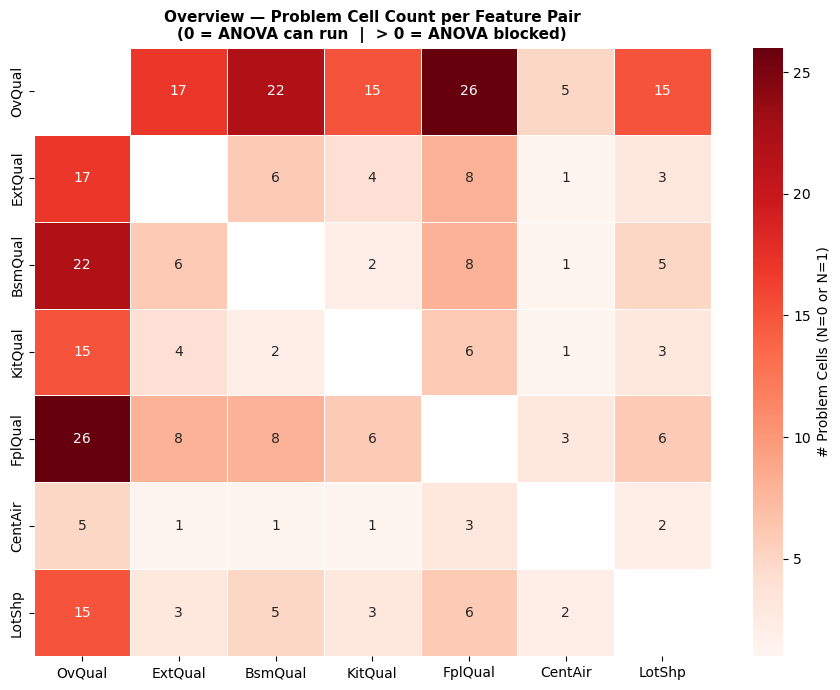

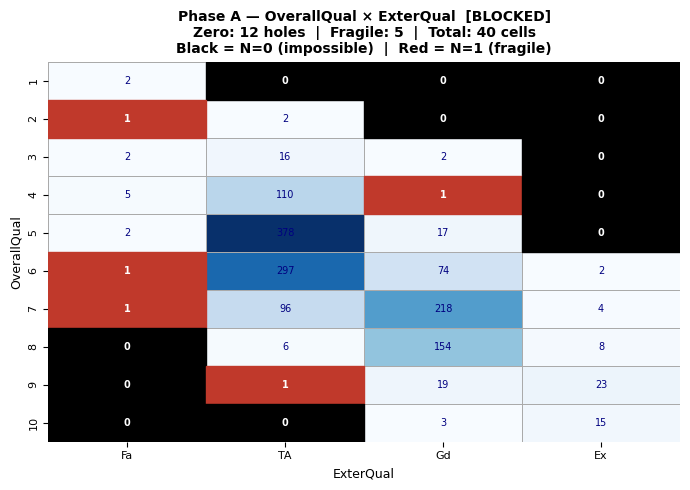

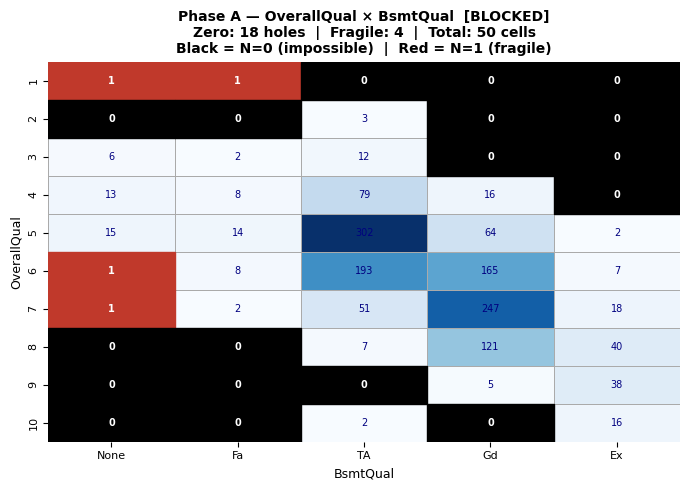

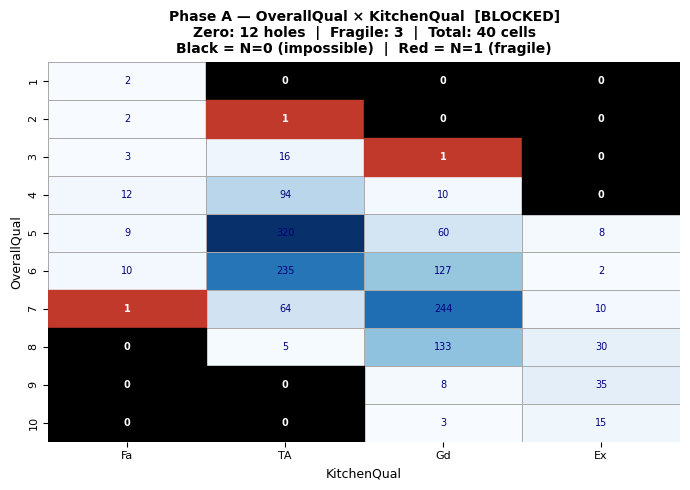

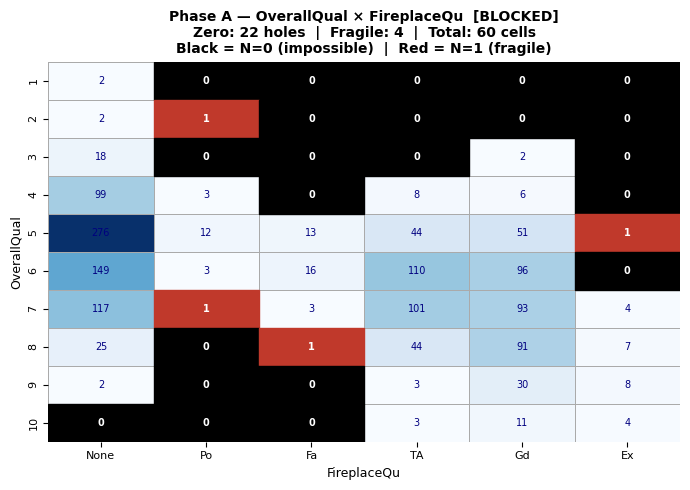

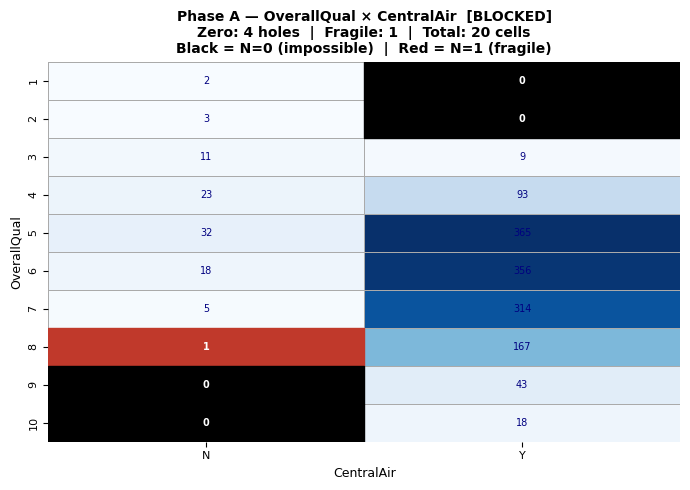

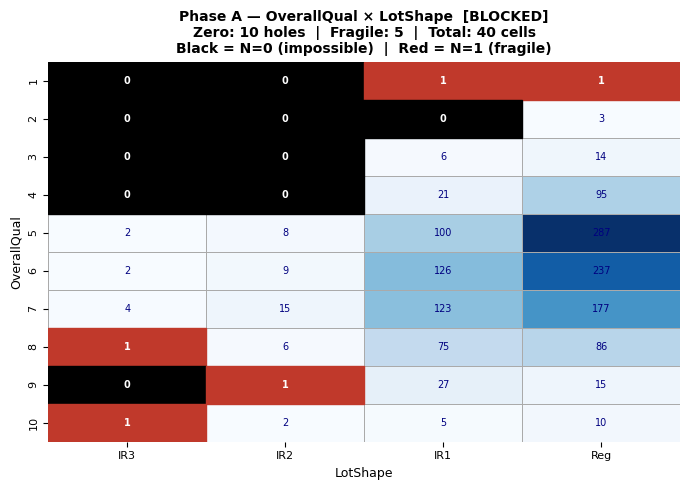

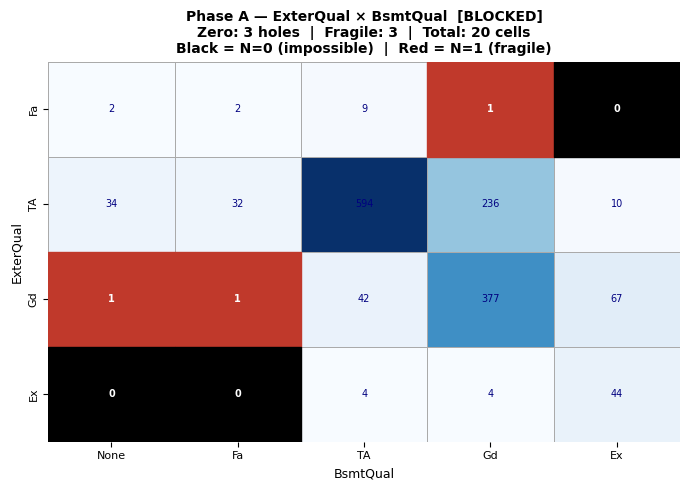

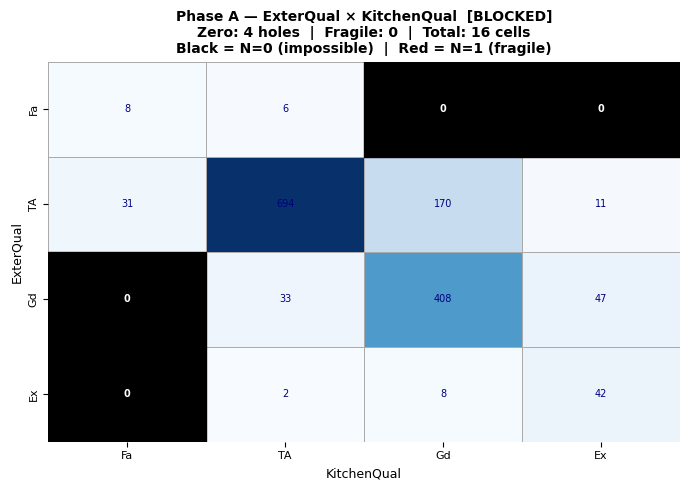

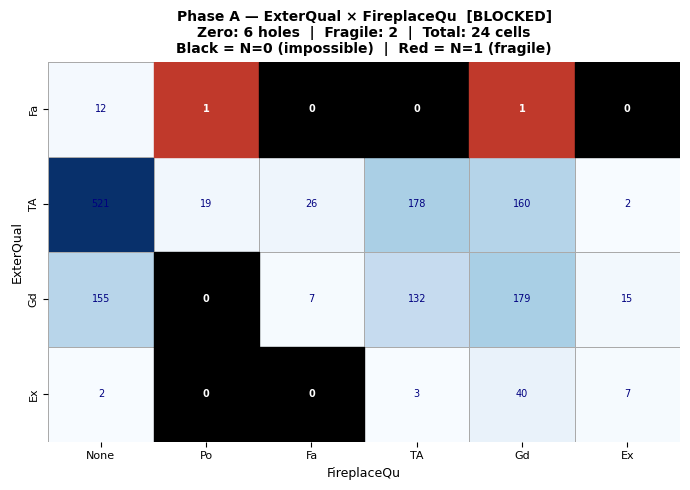

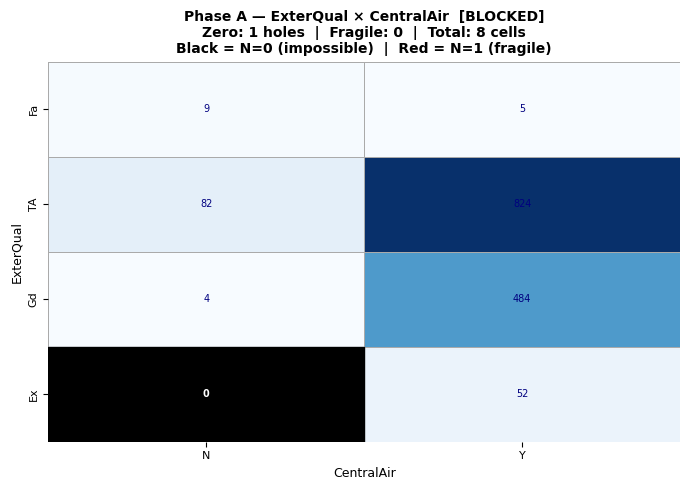

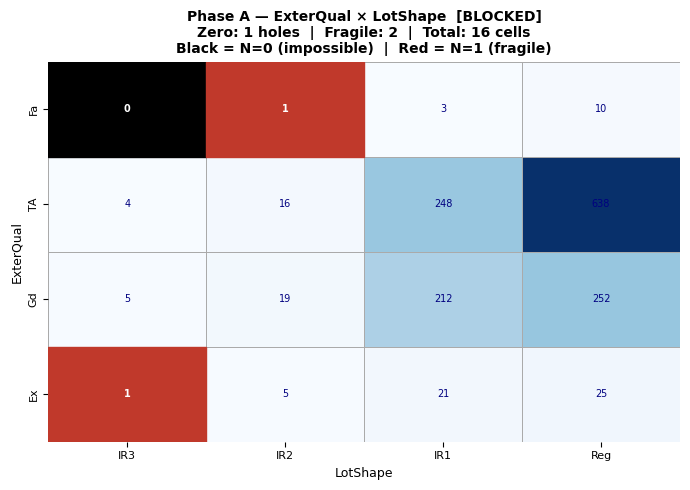

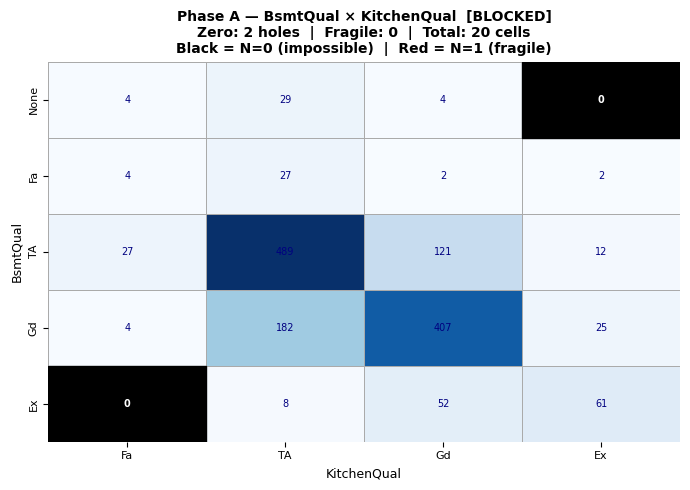

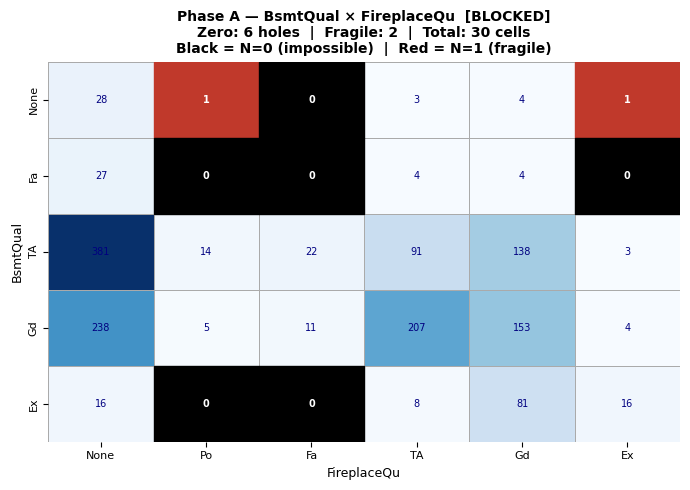

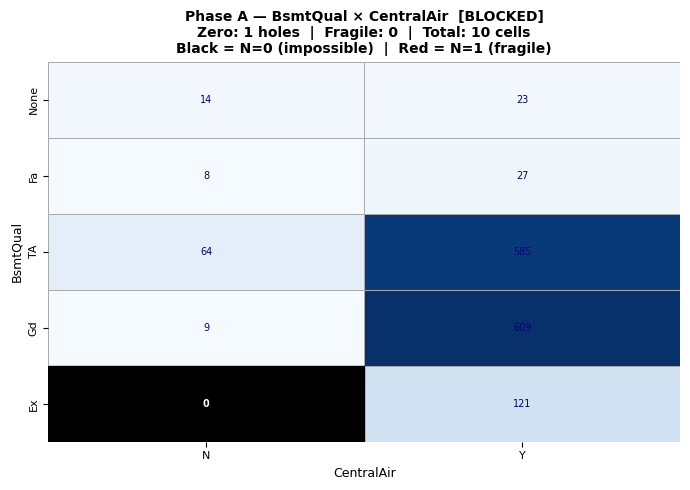

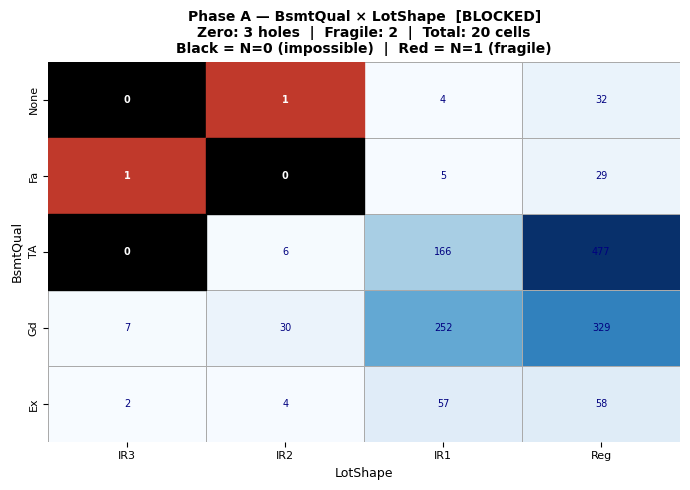

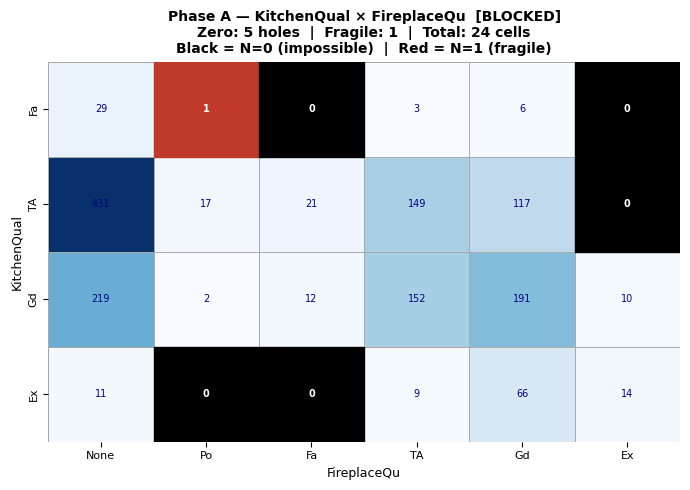

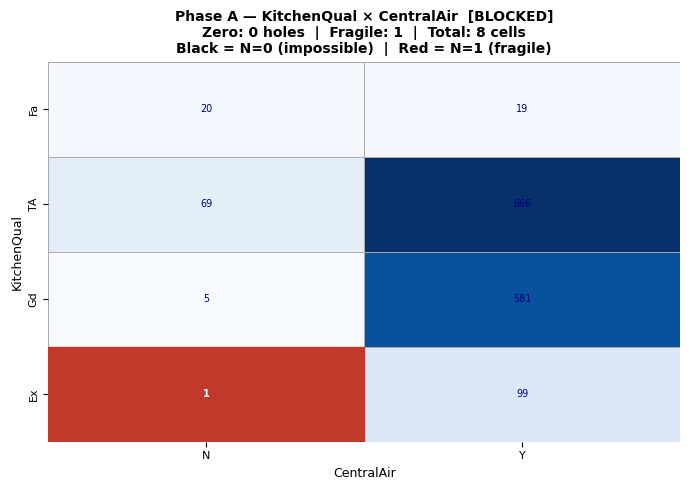

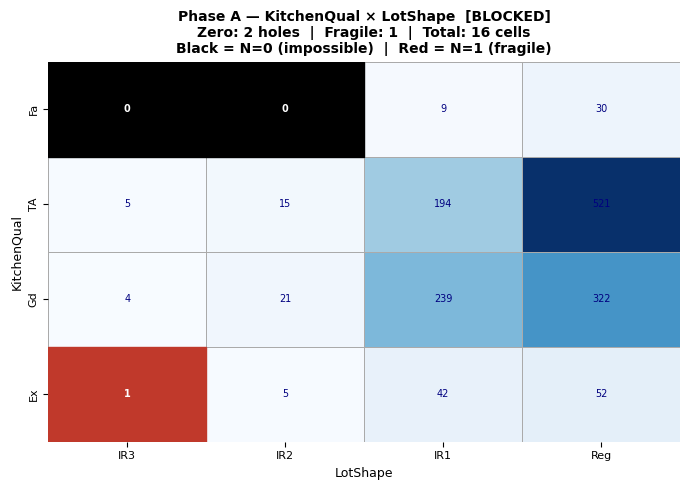

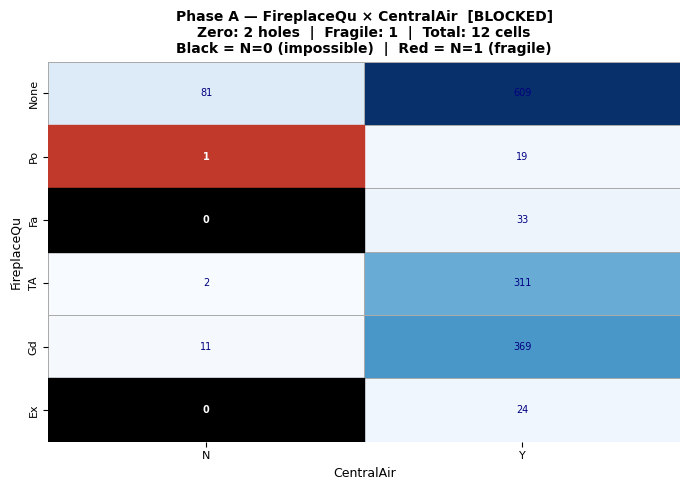

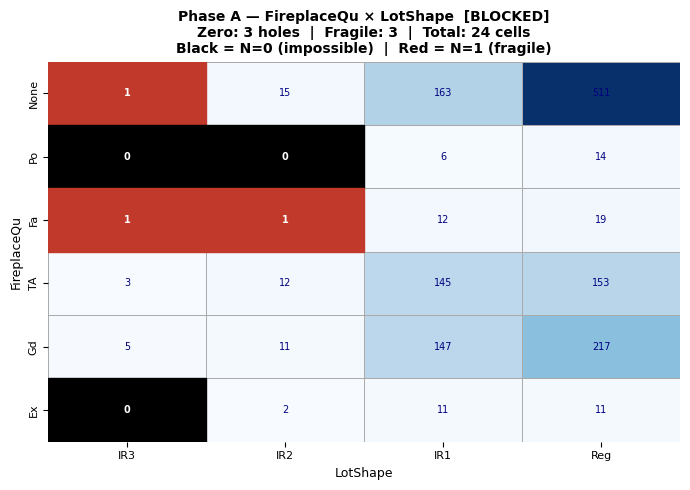

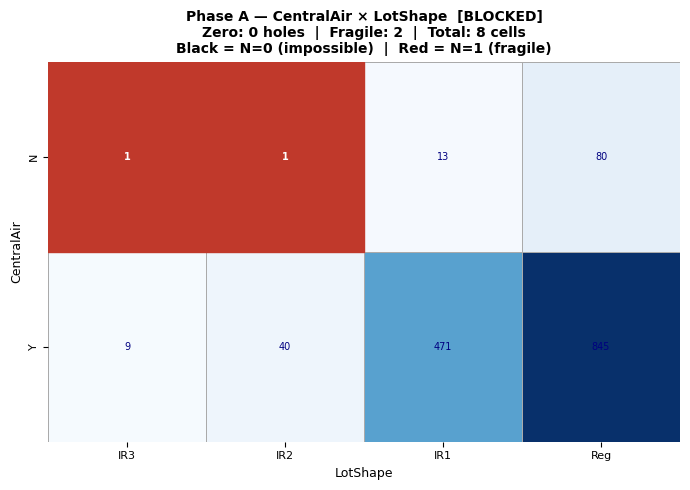


=== Severity Summary — Pairs Sorted by # Problem Cells ===


,Pair,Total Cells,Holes (N=0),Fragile (N=1),Problem Cells,Status
0,OverallQual × FireplaceQu,60,22,4,26,[BLOCKED]
1,OverallQual × BsmtQual,50,18,4,22,[BLOCKED]
2,OverallQual × ExterQual,40,12,5,17,[BLOCKED]
3,OverallQual × KitchenQual,40,12,3,15,[BLOCKED]
4,OverallQual × LotShape,40,10,5,15,[BLOCKED]
5,BsmtQual × FireplaceQu,30,6,2,8,[BLOCKED]
6,ExterQual × FireplaceQu,24,6,2,8,[BLOCKED]
7,FireplaceQu × LotShape,24,3,3,6,[BLOCKED]
8,ExterQual × BsmtQual,20,3,3,6,[BLOCKED]
9,KitchenQual × FireplaceQu,24,5,1,6,[BLOCKED]


In [11]:
significant_features = [
    'OverallQual', 'ExterQual', 'BsmtQual',
    'KitchenQual', 'FireplaceQu', 'CentralAir', 'LotShape'
]

df_diag = train[significant_features + ['SalePrice_Log']].copy()
for col in significant_features:
    df_diag[col] = df_diag[col].fillna('None').astype(str)

ORDINAL_ORDER = {
    'OverallQual': [str(i) for i in range(1, 11)],
    'ExterQual':   ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'BsmtQual':    ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'KitchenQual': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'FireplaceQu': ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'CentralAir':  ['N', 'Y'],
    'LotShape':    ['IR3', 'IR2', 'IR1', 'Reg'],
}

def ordered_levels(feature, available):
    return [o for o in ORDINAL_ORDER.get(feature, []) if o in available]

def make_crosstab(f1, f2, data=None):
    d = data if data is not None else df_diag
    cross = pd.crosstab(d[f1], d[f2])
    r = ordered_levels(f1, cross.index)
    c = ordered_levels(f2, cross.columns)
    return cross.reindex(index=r, columns=c, fill_value=0)

def annotate_heatmap(ax, cross):
    safe = cross.copy().astype(float)
    safe[safe <= 1] = np.nan
    sns.heatmap(safe, ax=ax, cmap='Blues', annot=False,
                linewidths=0.5, linecolor='#aaa', cbar=False, vmin=2)
    for yi, rl in enumerate(cross.index):
        for xi, cl in enumerate(cross.columns):
            v = cross.loc[rl, cl]
            if v == 0:
                ax.add_patch(plt.Rectangle((xi, yi), 1, 1,
                             fill=True, color='black', zorder=3))
                ax.text(xi+.5, yi+.5, '0', ha='center', va='center',
                        color='white', fontsize=7, fontweight='bold', zorder=4)
            elif v == 1:
                ax.add_patch(plt.Rectangle((xi, yi), 1, 1,
                             fill=True, color='#c0392b', zorder=3))
                ax.text(xi+.5, yi+.5, '1', ha='center', va='center',
                        color='white', fontsize=7, fontweight='bold', zorder=4)
            else:
                ax.text(xi+.5, yi+.5, str(v), ha='center', va='center',
                        color='navy', fontsize=7, zorder=4)

pairs = list(combinations(significant_features, 2))

# ── 1. Overview matrix (7×7) ────────────────────────────────
n_feat = len(significant_features)
prob_matrix = np.zeros((n_feat, n_feat), dtype=int)

for i, f1 in enumerate(significant_features):
    for j, f2 in enumerate(significant_features):
        if i < j:
            cross = make_crosstab(f1, f2)
            cnt = int((cross <= 1).sum().sum())
            prob_matrix[i, j] = cnt
            prob_matrix[j, i] = cnt

short_names = ['OvQual', 'ExtQual', 'BsmQual', 'KitQual', 'FplQual', 'CentAir', 'LotShp']

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(prob_matrix, ax=ax,
            xticklabels=short_names, yticklabels=short_names,
            cmap='Reds', annot=True, fmt='d',
            linewidths=0.5, mask=np.eye(n_feat, dtype=bool),
            cbar_kws={'label': '# Problem Cells (N=0 or N=1)'})
ax.set_title("Overview — Problem Cell Count per Feature Pair\n"
             "(0 = ANOVA can run  |  > 0 = ANOVA blocked)",
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 2. Detailed heatmaps for all 21 pairs (Individual figures) ──────
severity_rows = []

for i, (feat1, feat2) in enumerate(pairs):
    # Create a new unique figure for each pair
    fig, ax = plt.subplots(figsize=(7, 5))
    
    cross = make_crosstab(feat1, feat2)
    n_holes   = int((cross == 0).sum().sum())
    n_fragile = int((cross == 1).sum().sum())
    n_total   = cross.shape[0] * cross.shape[1]

    annotate_heatmap(ax, cross)

    status = "[BLOCKED]" if (n_holes + n_fragile) > 0 else "[OK]"
    
    # Add the global legend directly into the title of each plot
    ax.set_title(f"Phase A — {feat1} × {feat2}  {status}\n"
                 f"Zero: {n_holes} holes  |  Fragile: {n_fragile}  |  Total: {n_total} cells\n"
                 f"Black = N=0 (impossible)  |  Red = N=1 (fragile)",
                 fontsize=10, fontweight='bold')
    
    ax.set_xlabel(feat2, fontsize=9)
    ax.set_ylabel(feat1, fontsize=9)
    ax.tick_params(labelsize=8)

    severity_rows.append({
        'Pair': f"{feat1} × {feat2}",
        'Total Cells': n_total,
        'Holes (N=0)': n_holes,
        'Fragile (N=1)': n_fragile,
        'Problem Cells': n_holes + n_fragile,
        'Status': status
    })

    plt.tight_layout()
    plt.show() # Displays the current plot before moving to the next one

# ── 3. Summary Table ────────────────────────────────────────────────
sev_df = (pd.DataFrame(severity_rows)
          .sort_values('Problem Cells', ascending=False)
          .reset_index(drop=True))
print("\n=== Severity Summary — Pairs Sorted by # Problem Cells ===")
display(sev_df)


## How to Interpret the Crosstabulation Diagnostics

### 1. Understanding Heatmaps

### a. Understanding the Global Overview Heatmap (The 7x7 Matrix)

This large heatmap acts as a high-level executive summary, allowing you to evaluate all feature pairs at a single glance before diving into the details.

* **The Grid:** The rows and columns represent the 7 selected categorical features.
* **The Numbers:** The value inside each cell represents the *total count of problem combinations* (Holes + Fragile cells) between those two specific features.
* **The Colors:** A value of "0" means the feature pair has enough data across all combinations to run an ANOVA. As the number of problem cells increases, the color turns to a darker red, instantly highlighting the most problematic and fragmented feature pairs (like `OverallQual` vs `FireplaceQu`).

### b. Understanding the Detailed Individual Heatmaps

Once you have identified problematic pairs in the overview, each individual heatmap provides a detailed visual diagnosis of the specific intersection between two categorical features.

* **The Grid:** The rows and columns represent the distinct categories (levels) of the two features being compared.
* **Blue Cells (Safe):** These represent healthy combinations with 2 or more observations in your dataset. They provide enough data to calculate variance.
* **Black Cells with a "0" (Holes):** These represent missing combinations (zero observations). For example, there might be no houses in the dataset that have both an "Excellent" Kitchen Quality and a "Poor" Overall Quality.
* **Red Cells with a "1" (Fragile):** These represent combinations with exactly one observation. They are considered mathematically "fragile" because a single data point has no variance, which blocks standard ANOVA calculations.
* **Status Indicator ([OK] vs. [BLOCKED]):** If a heatmap contains *any* black or red cells, the overall status is flagged as **[BLOCKED]**. This means a standard Two-Way ANOVA with an interaction term cannot be reliably computed for this specific pair in its current state.


### 2. Interpreting the Severity Summary Table

The summary table ranks all 21 feature pairs by their total number of "Problem Cells" (the sum of Holes and Fragile cells), sorting them from the most severe to the least severe.

**Column Breakdown:**

* **Pair:** The two categorical features being evaluated.
* **Total Cells:** The mathematical total of possible combinations (e.g., a feature with 10 categories crossed with a feature with 6 categories equals 60 total cells).
* **Holes (N=0):** The number of completely empty combinations.
* **Fragile (N=1):** The number of combinations with exactly one row of data.
* **Problem Cells:** The sum of Holes and Fragile cells.
* **Status:** Whether the pair is safe for an ANOVA without data manipulation.

**Analysis of the Current Results:**
Based on the provided output, **100% of the pairs are [BLOCKED]**. This means that not a single pair of features can be directly plugged into a Two-Way ANOVA with interaction terms.

* **The Most Severe Cases:** The top row, `OverallQual × FireplaceQu`, is highly fragmented. Out of 60 possible combinations, 26 lack sufficient data (22 are completely empty, and 4 have only one data point). The top five pairs involving `OverallQual` account for the vast majority of missing data combinations.
* **The Least Severe Cases:** Pairs at the bottom of the table, such as `ExterQual × CentralAir` or `BsmtQual × CentralAir`, have only 1 problem cell out of their respective totals. However, in statistical modeling, even a single missing interaction cell is enough to block the analysis.



## Part 2 - 3 : Two-Way ANOVA — Why We Could Not Conclude

### Objective
Test whether two features have a **joint effect (interaction)** on the sale price.
For example: does the effect of kitchen quality on price also depend on
the overall quality of the house?

### The Problem: 100% of Pairs Are Blocked

Two-Way ANOVA requires that **every combination** (sub-category A × sub-category B)
contains at least 2 observations. Our data is **observational**: certain combinations
simply do not exist in the real estate market.

**Concrete example:**

| OverallQual \ FireplaceQu | None | Po | Fa | TA | Gd | Ex |
|---------------------------|------|----|----|-----|-----|-----|
| 1 (Very Poor)             |  12  |  0 |  0 |  0  |  0  |  0 |
| 2 (Poor)                  |   8  |  0 |  0 |  0  |  0  |  0 |
| ...                       |  ... | ...| ...| ... | ... | ... |
| 9 (Excellent)             |   3  |  0 |  1 | 45  | 89  | 23 |
| 10 (Very Excellent)       |   1  |  0 |  0 | 12  | 67  | 34 |

A house with **overall quality "Very Poor"** and an **"Excellent" fireplace**
does not exist in this dataset — and most likely not in reality either.
Out of 60 possible combinations for this pair, **26 are empty or singletons**.

---

### Approach 1 Considered: Dropping Rare Sub-Categories

The idea: remove the levels that create empty cells (e.g., drop "Po" and "Fa"
from `FireplaceQu` because too few houses fall into those categories).

**Problem:** This causes real information loss and biases the results.
Dropping "Poor" and "Fair" means analyzing only average-to-excellent quality houses —
the model no longer represents the full market.
Conclusions would only be valid for a subset of the data,
making them **non-generalizable and unrealistic**.

---

### Approach 2 Considered: Merging Sub-Categories (Binning)

The idea: merge rare levels with their neighbors to fill the empty cells.

This approach requires strict rules to avoid distorting the data:

#### Rule A — Ordinal Proximity (the logic rule)
Only **adjacent** categories on the ordinal scale may be merged.
Merging "Poor" with "Fair" is acceptable (direct neighbors).
Merging "Poor" with "Excellent" is forbidden — it creates a group
with no real-world meaning.

> **Example:** For `FireplaceQu` (scale: None → Po → Fa → TA → Gd → Ex),
> grouping [None/Po] or [Fa/TA] is allowed, but [Po/Ex] is never acceptable.

#### Rule B — Mean Homogeneity (the statistical rule)
Only merge categories whose **average prices are close**.
If "Poor" sells at an average of $120,000 and "Fair" at $200,000,
merging them would create an artificial group at $160,000
that reflects no real market segment.

#### Rule C — The Small Sample Trap ⚠️

This is where the approach hits its fundamental limit.

**Situation:** A sub-category has very few observations (e.g., N=3).
Its sample mean appears close to another category — and the t-test
returns "no significant difference." One would conclude that merging is safe.

**But this reasoning is misleading.**

> **Concrete example with `FireplaceQu`:**
>
> | Sub-category | N  | Mean log-price | Std dev |
> |--------------|----|----------------|---------|
> | "Po" (Poor)  |  3 | 11.80          | 0.41    |
> | "Fa" (Fair)  | 28 | 11.85          | 0.38    |
>
> The difference in means is only 0.05 — very small, t-test gives p = 0.72.
> One might conclude: "compatible, safe to merge."
>
> **However:** With N=3, the 95% confidence interval for the true mean of "Po" is:
>
> `11.80 ± 2.92 × (0.41 / √3)  =  [11.11 ;  12.49]`
>
> The true mean of "Poor" could be anywhere between 11.11 and 12.49.
> In reality it could be as high as 12.3 — a **real difference of +0.45**
> compared to "Fair", which is economically significant (~45% price gap).
>
> The t-test fails to detect a difference **not because there is none**,
> but because with N=3 it has **no statistical power** to detect it.
> We would then be merging two groups that may be fundamentally different.

This problem is systematic in our dataset: the rare sub-categories
(the ones that create empty cells) are precisely those with very low N.
The merging approach therefore falls into a vicious cycle:
the categories that need to be merged are exactly those for which
merging is statistically unreliable.

---

### Conclusion

Both approaches face fundamental obstacles rooted in the observational
nature of the data:

| Approach | Problem |
|----------|---------|
| Drop rare sub-categories | Information loss, biased results |
| Merge sub-categories | Unreliable when N is small (vicious cycle) |

The root cause is not methodological but structural:
in a real estate market, certain quality combinations simply do not exist.
Classical Two-Way ANOVA was designed for **controlled experimental designs**
where all combinations are guaranteed — which is not the case for
observational data such as this dataset.

We document this limitation and retain the One-Way ANOVA results
(Part 2-2) as the basis for the rest of the analysis.


## Part 2 - 4. Use **Tukey HSD** post-hoc tests where appropriate



### Tukey HSD — Mapping Pairwise Differences Across All Levels

> **Reminder — where this fits.** In Part 2-3, the Two-Way ANOVA was blocked on **100% of feature pairs** by empty cells ($N=0$) and singletons ($N=1$). The proposed escape route was **intelligent binning**: merge adjacent levels of a feature to refill the matrix. But before any merging can happen, we need to know **which levels are statistically distinguishable from which** — fusing two genuinely different groups would corrupt the analysis. This cell produces that map.

#### 1. What Tukey HSD Does

Tukey's **Honestly Significant Difference** test compares the means of **every pair of levels** within a feature (e.g. for `OverallQual`, all 45 pairs from levels 1 to 10), and returns an **adjusted p-value** for each comparison. The adjustment matters: when you run many comparisons at once, the probability of catching a fake "significant" difference by chance inflates rapidly. Tukey controls this **family-wise error rate**, so the verdict on each pair is reliable even when dozens of tests are run together.

For each pair, the output gives us:

* **`meandiff`** — the gap between the two group means (in the units of the target).
* **`p-adj`** — the family-wise-corrected p-value.
* **`reject`** — the verdict: $H_0$ rejected (the two means differ) or not.

#### 2. The Logic for the Fusion Strategy

The verdict on each pair carries a **direct operational meaning** for what comes next:

* **Non-significant pair (`reject = False`, $p \geq 0.05$):** the two levels are **not statistically distinguishable** on this target — they are **candidates for merging**.
* **Significant pair (`reject = True`, $p < 0.05$):** the two levels are **statistically distinct** — merging them would **destroy real signal** and must be forbidden.


#### 3. Our Approach

The code follows a 3-step pipeline, repeated for each of our **3 targets** (`SalePrice`, `SalePrice_Log`, `SalePrice_BoxCox`):

1. **Data preparation:** select the **7 significant features** from Part 2-2 and fill `NaN` values with the string `'None'` so they are treated as a valid category.
2. **Tukey HSD per feature:** run `pairwise_tukeyhsd` on each feature against the current target. Extract every pair, its `meandiff`, its `p-adj`, and the `reject` flag into a structured `DataFrame` stored in `tukey_all[target][feature]`.
3. **Display:** for each feature, print the count of significant vs. non-significant pairs.

#### 4. Why Three Output Formats for `meandiff`

The `meandiff` column carries the same statistical information across the three targets, but on **three different scales** — each unintuitive in its own way. To keep the output readable, we format the gap differently per target:

* **`SalePrice` → dollars** (e.g. `+$15,000`): the raw scale is already monetary, so we display it directly with a currency formatter.
* **`SalePrice_Log` → log units + % equivalent** (e.g. `+0.0488 (+5.0%)`): a difference of `0.05` on the log scale means nothing on its own. Using $e^{\Delta} - 1$ converts it back to a **relative price gap** that we can actually read.
* **`SalePrice_BoxCox` → BoxCox units** (e.g. `+0.062345`): the BoxCox scale has no intuitive interpretation (it depends on $\lambda \approx -0.0769$), so we display the raw value to **six decimals** to preserve precision for downstream comparison logic.





In [12]:
# Cell A — Raw Tukey HSD: 3 targets x 7 features
# Uses: significant_features, train (defined in cells above)
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from IPython.display import display

targets = ['SalePrice', 'SalePrice_Log', 'SalePrice_BoxCox']

MEANDIFF_FMT = {
    'SalePrice':        lambda x: f'${x:+,.0f}',
    'SalePrice_Log':    lambda x: f'{x:+.4f}  ({(np.exp(x)-1)*100:+.1f}%)',
    'SalePrice_BoxCox': lambda x: f'{x:+.6f}',
}

def fmt_df(df_sub, fmt_fn):
    t = df_sub[['group1', 'group2', 'meandiff', 'p-adj']].reset_index(drop=True).copy()
    t['meandiff'] = t['meandiff'].map(fmt_fn)
    t['p-adj']    = t['p-adj'].map('{:.4f}'.format)
    return t

tukey_all = {}

for target in targets:
    tukey_all[target] = {}
    fmt_fn = MEANDIFF_FMT[target]

    df_t = train[significant_features + [target]].copy()
    for col in significant_features:
        df_t[col] = df_t[col].fillna('None').astype(str)

    print(f"\n{'#'*70}")
    print(f"  TARGET : {target}")
    print(f"{'#'*70}")

    for feature in significant_features:
        tky = pairwise_tukeyhsd(endog=df_t[target], groups=df_t[feature], alpha=0.05)
        grps = [str(g) for g in tky.groupsunique]
        rows, k = [], 0
        for i in range(len(grps)):
            for j in range(i + 1, len(grps)):
                rows.append({
                    'group1':   grps[i],
                    'group2':   grps[j],
                    'meandiff': tky.meandiffs[k],
                    'p-adj':    tky.pvalues[k],
                    'reject':   tky.reject[k],
                })
                k += 1
        res = pd.DataFrame(rows)
        tukey_all[target][feature] = res

        n_pairs = len(res)
        n_sig   = int(res['reject'].sum())
        n_non   = n_pairs - n_sig

        print(f"\n{'='*60}")
        print(f"  {feature}  --  {len(grps)} groups, {n_pairs} pairs")
        print(f"  Significant: {n_sig}  |  Non-significant: {n_non}")
        print(f"{'='*60}")

        if n_sig > 0:
            print(f"\n  Significant pairs (p < 0.05):")
            display(fmt_df(res[res['reject']], fmt_fn))

        if n_non > 0:
            print(f"\n  NON-significant pairs (p >= 0.05):")
            display(fmt_df(res[~res['reject']], fmt_fn))
        else:
            print("  -> All pairs are significantly different.")


######################################################################
  TARGET : SalePrice
######################################################################

  OverallQual  --  10 groups, 45 pairs
  Significant: 37  |  Non-significant: 8

  Significant pairs (p < 0.05):


,group1,group2,meandiff,p-adj
0,1,10,"$+388,438",0.0000
1,1,6,"$+111,453",0.0166
2,1,7,"$+157,566",0.0000
3,1,8,"$+224,586",0.0000
4,1,9,"$+317,363",0.0000
5,10,2,"$-386,818",0.0000
6,10,3,"$-351,115",0.0000
7,10,4,"$-330,168",0.0000
8,10,5,"$-305,065",0.0000
9,10,6,"$-276,985",0.0000



  NON-significant pairs (p >= 0.05):


,group1,group2,meandiff,p-adj
0,1,2,"$+1,620",1.0000
1,1,3,"$+37,324",0.9823
2,1,4,"$+58,271",0.7196
3,1,5,"$+83,373",0.2062
4,2,3,"$+35,703",0.9565
5,2,4,"$+56,650",0.4829
6,2,5,"$+81,753",0.0529
7,3,4,"$+20,947",0.6471



  ExterQual  --  4 groups, 6 pairs
  Significant: 6  |  Non-significant: 0

  Significant pairs (p < 0.05):


...

,group1,group2,meandiff,p-adj
0,N,Y,+0.230394,0.0000


  -> All pairs are significantly different.

  LotShape  --  4 groups, 6 pairs
  Significant: 2  |  Non-significant: 4

  Significant pairs (p < 0.05):


,group1,group2,meandiff,p-adj
0,IR1,Reg,-0.090115,0.0000
1,IR2,Reg,-0.150806,0.0000



  NON-significant pairs (p >= 0.05):


,group1,group2,meandiff,p-adj
0,IR1,IR2,+0.060691,0.0658
1,IR1,IR3,+0.015881,0.9878
2,IR2,IR3,-0.044810,0.8355
3,IR3,Reg,-0.105996,0.1228


## Interpretation of Raw Tukey HSD Results

### 1. Global Summary — Pair Counts Across the Three Targets

The table below consolidates the verdict counts for every feature on each of the three targets. **"Sig"** counts pairs where $H_0$ is rejected (the two levels differ significantly) and **"Non-Sig"** counts the candidates that *could* potentially be merged downstream.

| Feature | Total Pairs | Sig (Original) | Non-Sig (Original) | Sig (Log) | Non-Sig (Log) | Sig (BoxCox) | Non-Sig (BoxCox) |
|---|---|---|---|---|---|---|---|
| **OverallQual** | 45 | 37 | **8** | 43 | **2** | 43 | **2** |
| **ExterQual** | 6 | **6** | 0 | **6** | 0 | **6** | 0 |
| **BsmtQual** | 10 | 8 | **2** | 9 | **1** | 9 | **1** |
| **KitchenQual** | 6 | **6** | 0 | **6** | 0 | **6** | 0 |
| **FireplaceQu** | 15 | 12 | **3** | 13 | **2** | 13 | **2** |
| **CentralAir** | 1 | **1** | 0 | **1** | 0 | **1** | 0 |
| **LotShape** | 6 | 3 | **3** | 2 | **4** | 2 | **4** |
| **TOTAL** | **89** | **73** | **16** | **80** | **9** | **80** | **9** |

> **Headline observation:** transforming the target **dramatically reduces** the number of non-significant pairs — from **16** on the original scale down to **9** on both Log and Box-Cox. The Log and Box-Cox scales return **identical pair counts** on every feature, suggesting both transformations recover the same separability structure.

---

Let's take the row: **OverallQual** (the Overall Quality rating of the house, which ranges from 1 to 10).

Here is the row extracted from your table:

| Feature | Total Pairs | Sig (Original) | Non-Sig (Original) | Sig (Log) | Non-Sig (Log) | Sig (BoxCox) | Non-Sig (BoxCox) |
| --- | --- | --- | --- | --- | --- | --- | --- |
| **OverallQual** | 45 | 37 | 8 | 43 | 2 | 43 | 2 |



### **The column-by-column explanation:**

**a. Feature (OverallQual)**
This is the characteristic of the house being analyzed. Here, it is a rating out of 10.

**b. Total Pairs (45)**
This is the total number of possible comparisons between the different groups. Since there are 10 possible ratings (1, 2, 3... up to 10), the statistical test compared rating 1 with 2, 1 with 3, 8 with 9, etc.
*Mathematically, for 10 groups, that makes exactly 45 unique combinations (or "pairs") to check.*

**c. Sig (Original) = 37 | Non-Sig (Original) = 8**
Here, we are looking at the results calculated on the raw price in dollars (`SalePrice`).

* **37 (Significant):** The model proved with certainty that for 37 of these pairs, the difference in rating corresponded to a real difference in price on the market.
* **8 (Non-Significant):** For 8 pairs (likely very close ratings or extremes with few houses, such as rating 1 vs. rating 2), the test could not mathematically prove that there was a justified price difference.

**d. Sig (Log) = 43 | Non-Sig (Log) = 2**
 We are now looking at the results calculated on the logarithmic price format (`SalePrice_Log`).

* The transformation smoothed out the outliers .
* It is now able to prove a real price difference for **43 pairs** (instead of 37)! There are only 2 pairs left that it cannot differentiate.

**e. Sig / Non-Sig (BoxCox) (43 and 2)**
The exact same logic applies as with the Log. We can see here that the Box-Cox method provides the exact same detection capabilities as the Logarithm.


### 2. Detailed Reading per Target

#### 2.a. On the Original Scale (`SalePrice`)

* **`OverallQual` (8 non-sig pairs out of 45):** the non-significant pairs are all concentrated in the **lower half** of the scale (levels 1–5). Specifically: `(1,2)` with $+\$1,620$, `(1,3)` with $+\$37,324$, `(1,4)` with $+\$58,271$, `(1,5)` with $+\$83,373$, `(2,3)` with $+\$35,703$, `(2,4)` with $+\$56,650$, `(2,5)` with $+\$81,753$ (p=0.0529, borderline), and `(3,4)` with $+\$20,947$. Every pair involving levels 6 to 10 is significant.
* **`ExterQual` (0 non-sig):** all 6 pairs are significant — the 4 levels (`Fa`, `TA`, `Gd`, `Ex`) are fully distinguishable.
* **`BsmtQual` (2 non-sig):** `(Fa, None)` with a gap of only $-\$10,039$ (p=0.9491) and `(Fa, TA)` with $+\$25,068$ (p=0.0951). "No basement" and "Fair basement" are statistically indistinguishable.
* **`KitchenQual` (0 non-sig):** all 6 pairs separable.
* **`FireplaceQu` (3 non-sig):** `(Fa, None)` with $-\$25,967$ (p=0.2480), `(Fa, Po)` with $-\$37,534$ (p=0.3538), and `(None, Po)` with $-\$11,567$ (p=0.9736). The three weakest fireplace categories collapse together.
* **`CentralAir` (0 non-sig):** the single pair `(N, Y)` shows a gap of $+\$80,923$ (p<0.0001).
* **`LotShape` (3 non-sig):** half of the pairs fail to separate — `(IR1, IR3)` with $+\$9,935$ (p=0.9772), `(IR2, IR3)` with $-\$23,797$ (p=0.8138), and `(IR3, Reg)` with $-\$51,282$ (p=0.1502). Only pairs involving the clean separation between irregulars and regulars are detected.

#### 2.b. On the Log Scale (`SalePrice_Log`)

* **`OverallQual` (2 non-sig):** the cluster of 8 non-significant pairs on the original scale **collapses to just 2** under log transformation: `(1, 2)` with $+0.0266$ ($+2.7\%$, p=1.0000) and `(10, 9)` with $-0.1280$ ($-12.0\%$, p=0.6051). The log scale separates levels 3, 4, and 5 from level 1 that were previously indistinguishable.
* **`ExterQual` (0 non-sig):** all 6 pairs significant, identical verdict to the original scale.
* **`BsmtQual` (1 non-sig):** only `(Fa, None)` remains non-significant with $-0.0879$ ($-8.4\%$, p=0.7161). The `(Fa, TA)` pair, borderline on the original scale, becomes clearly significant under log.
* **`KitchenQual` (0 non-sig):** all 6 pairs significant.
* **`FireplaceQu` (2 non-sig):** `(Gd, TA)` with $-0.0701$ ($-6.8\%$, p=0.0637) and `(None, Po)` with $-0.0701$ ($-6.8\%$, p=0.9387). The non-significant set **shifts** compared to the original scale — `(Fa, None)` and `(Fa, Po)` now become significant, but `(Gd, TA)` newly enters the non-significant group.
* **`CentralAir` (0 non-sig):** $+0.5692$ ($+76.7\%$, p<0.0001).
* **`LotShape` (4 non-sig):** the situation **worsens** — one additional pair becomes non-significant compared to the original scale. The non-sig pairs are `(IR1, IR2)` with $+0.1550$ ($+16.8\%$, p=0.0611), `(IR1, IR3)` with $+0.0419$ ($+4.3\%$, p=0.9860), `(IR2, IR3)` with $-0.1130$ ($-10.7\%$, p=0.8357), and `(IR3, Reg)` with $-0.2693$ ($-23.6\%$, p=0.1188). All three irregular levels collapse together.

#### 2.c. On the Box-Cox Scale (`SalePrice_BoxCox`)

* **`OverallQual` (2 non-sig):** identical verdict structure to the Log scale — `(1, 2)` with $+0.0113$ (p=1.0000) and `(10, 9)` with $-0.0460$ (p=0.7388).
* **`ExterQual` (0 non-sig):** all 6 pairs significant.
* **`BsmtQual` (1 non-sig):** `(Fa, None)` with $-0.0361$ (p=0.6916), same pair as Log.
* **`KitchenQual` (0 non-sig):** all 6 pairs significant.
* **`FireplaceQu` (2 non-sig):** `(Gd, TA)` with $-0.0266$ (p=0.0876) and `(None, Po)` with $-0.0280$ (p=0.9374), same pairs as Log.
* **`CentralAir` (0 non-sig):** $+0.2304$ (p<0.0001).
* **`LotShape` (4 non-sig):** `(IR1, IR2)` with $+0.0607$ (p=0.0658), `(IR1, IR3)` with $+0.0159$ (p=0.9878), `(IR2, IR3)` with $-0.0448$ (p=0.8355), `(IR3, Reg)` with $-0.1060$ (p=0.1228). Same non-significant set as the Log scale.

---

### 3. Comparative Interpretation Across the Three Targets

Three patterns emerge from the cross-scale comparison:

**Log and Box-Cox produce nearly identical verdicts.** On every feature, the two transformations return the **same number of non-significant pairs**, and inspection of the pair lists confirms they flag the **same pairs**. This is consistent with the fact that both transformations target the same underlying problem (right-skew of `SalePrice`) and end up at very similar shapes — the Box-Cox $\lambda \approx -0.0769$ found earlier is close to $0$, which is the value at which Box-Cox **becomes** a log transformation. The two scales are therefore interchangeable for the purpose of identifying merge candidates.

**The original scale flags more non-significant pairs than the transformed scales.** Specifically: 16 vs 9 globally. The mechanism is straightforward — on the original scale, the **variance within high-quality groups is enormous** (a single $750k outlier in the `OverallQual = 9` group dramatically inflates its standard error). Tukey's test compares the gap between two means against their pooled standard error, so an inflated variance **shrinks the t-statistic** and pushes pairs toward non-significance. The Log and Box-Cox transformations compress these large variances, restoring the statistical power needed to detect real differences. This is why pairs like `(1, 3)`, `(1, 4)`, `(2, 3)`, `(2, 4)` of `OverallQual` — non-significant on the original scale — become clearly significant once the scale is normalized.

**Two features (`OverallQual` and `LotShape`) reveal opposite behaviours under transformation.**
- `OverallQual` **gains separability**: 8 non-sig pairs on the original collapse to 2 on Log/BoxCox. The transformation reveals real ordinal structure that was masked by variance heterogeneity.
- `LotShape` **loses separability**: 3 non-sig pairs become 4 under transformation. The reason is opposite — on the original scale, the high-price outliers in `Reg` and `IR1` artificially inflated the gap to `IR3`. Once those outliers are compressed, the four lot-shape categories show that the three irregular levels (`IR1`, `IR2`, `IR3`) are **essentially indistinguishable**, with only the irregular-vs-regular contrast surviving.

This divergence is meaningful for the fusion strategy: the transformation choice **affects which merge candidates we get** for some features but not for others.

---

### 4. Merge Candidates per Target

The three tables below list, for each target, every non-significant pair detected by Tukey HSD. These are the **raw candidates** that will be filtered downstream by the merging rules (ordinal proximity, binary lock, nominal macro-families) in the next cell.

#### Merge Candidates — `SalePrice`

| Feature | Pair | meandiff | p-adj |
|---|---|---|---|
| **OverallQual** | (1, 2) | $+1,620 | 1.0000 |
| **OverallQual** | (1, 3) | $+37,324 | 0.9823 |
| **OverallQual** | (1, 4) | $+58,271 | 0.7196 |
| **OverallQual** | (1, 5) | $+83,373 | 0.2062 |
| **OverallQual** | (2, 3) | $+35,703 | 0.9565 |
| **OverallQual** | (2, 4) | $+56,650 | 0.4829 |
| **OverallQual** | (2, 5) | $+81,753 | 0.0529 |
| **OverallQual** | (3, 4) | $+20,947 | 0.6471 |
| **BsmtQual** | (Fa, None) | $-10,039 | 0.9491 |
| **BsmtQual** | (Fa, TA) | $+25,068 | 0.0951 |
| **FireplaceQu** | (Fa, None) | $-25,967 | 0.2480 |
| **FireplaceQu** | (Fa, Po) | $-37,534 | 0.3538 |
| **FireplaceQu** | (None, Po) | $-11,567 | 0.9736 |
| **LotShape** | (IR1, IR3) | $+9,935 | 0.9772 |
| **LotShape** | (IR2, IR3) | $-23,797 | 0.8138 |
| **LotShape** | (IR3, Reg) | $-51,282 | 0.1502 |

> **Total: 16 candidate pairs across 4 features** (`OverallQual`, `BsmtQual`, `FireplaceQu`, `LotShape`).

#### Merge Candidates — `SalePrice_Log`

| Feature | Pair | meandiff | p-adj |
|---|---|---|---|
| **OverallQual** | (1, 2) | +0.0266 (+2.7%) | 1.0000 |
| **OverallQual** | (10, 9) | -0.1280 (-12.0%) | 0.6051 |
| **BsmtQual** | (Fa, None) | -0.0879 (-8.4%) | 0.7161 |
| **FireplaceQu** | (Gd, TA) | -0.0701 (-6.8%) | 0.0637 |
| **FireplaceQu** | (None, Po) | -0.0701 (-6.8%) | 0.9387 |
| **LotShape** | (IR1, IR2) | +0.1550 (+16.8%) | 0.0611 |
| **LotShape** | (IR1, IR3) | +0.0419 (+4.3%) | 0.9860 |
| **LotShape** | (IR2, IR3) | -0.1130 (-10.7%) | 0.8357 |
| **LotShape** | (IR3, Reg) | -0.2693 (-23.6%) | 0.1188 |

> **Total: 9 candidate pairs across 4 features** (`OverallQual`, `BsmtQual`, `FireplaceQu`, `LotShape`).

#### Merge Candidates — `SalePrice_BoxCox`

| Feature | Pair | meandiff | p-adj |
|---|---|---|---|
| **OverallQual** | (1, 2) | +0.011330 | 1.0000 |
| **OverallQual** | (10, 9) | -0.045996 | 0.7388 |
| **BsmtQual** | (Fa, None) | -0.036097 | 0.6916 |
| **FireplaceQu** | (Gd, TA) | -0.026596 | 0.0876 |
| **FireplaceQu** | (None, Po) | -0.027958 | 0.9374 |
| **LotShape** | (IR1, IR2) | +0.060691 | 0.0658 |
| **LotShape** | (IR1, IR3) | +0.015881 | 0.9878 |
| **LotShape** | (IR2, IR3) | -0.044810 | 0.8355 |
| **LotShape** | (IR3, Reg) | -0.105996 | 0.1228 |

> **Total: 9 candidate pairs across 4 features** (`OverallQual`, `BsmtQual`, `FireplaceQu`, `LotShape`).

> **Note for the next step:** `ExterQual`, `KitchenQual`, and `CentralAir` produce **zero merge candidates** on all three targets — their levels are fully separable and will pass through to the next cell untouched.

---


### Filtering Tukey Pairs by Merging Rules

> **Reminder — why we need rules.** Cell A produced the **raw map** of every pairwise Tukey comparison, flagging each pair as significant or non-significant. But Tukey alone is not enough to decide what can be merged: it only tells us **which means are statistically indistinguishable**, not whether merging two indistinguishable levels would make **sense for the data**. As discussed in Part 2-3 (Rule A — Ordinal Proximity, Rule B — Mean Homogeneity), blindly merging based on p-values alone leads to two failure modes — **destroying ordinal structure** (merging "Poor" with "Excellent" just because their means happen to be close in our sample) and **collapsing categorical semantics** (treating fundamentally different lot shapes as one group). This cell enforces a **structural filter** that runs *before* statistical merging: a pair is allowed through only if it is **eligible by domain rules** AND **non-significant in Tukey**.

#### 1. The Three Merging Rules

We define three rules, each tied to the nature of the feature involved.

**Rule 1 — Ordinal Proximity (for ordinal features).**
For features with a natural ordering (`OverallQual` 1→10, `ExterQual`/`KitchenQual` `Po`→`Ex`, `BsmtQual`/`FireplaceQu` `None`→`Ex`), **only adjacent pairs on the scale are eligible**. Fusing `Po` with `Fa` is acceptable because they are direct neighbours on a quality ladder; fusing `Po` with `Ex` is forbidden because it would create a group spanning the entire quality range — a category with no real-world meaning. This rule preserves the **monotonic relationship** between quality level and price that justified treating these features as ordinal in the first place.

**Rule 2 — Binary Lock (for binary features).**
The variable `CentralAir` has only **two levels** (`N`, `Y`). Merging them would **eliminate the variable entirely**: a feature with a single level carries zero information and contributes nothing to the model. Even if Tukey returned a non-significant verdict, fusion would be analytically nonsensical — there would be no contrast left to study. We therefore mark `CentralAir` as **untouchable**: no pair is eligible.

**Rule 3 — Nominal Macro-Families (for nominal features).**
`LotShape` is the only **non-ordinal** feature in our set. Its four levels (`Reg`, `IR1`, `IR2`, `IR3`) split naturally into **two semantic families**: `Reg` describes a **regular rectangular lot** (a clean geometric category), while `IR1`, `IR2`, and `IR3` describe **progressively more irregular shapes** that all share the same fundamental property — the lot is **not rectangular**. From a real-estate standpoint, the three irregular levels are gradations of the same underlying concept, while regularity is a categorically different state. We therefore restrict eligible pairs to those **within the same macro-family**: any pair among `{IR1, IR2, IR3}` is allowed (`Irregular` family), but no irregular level may ever be merged with `Reg`. This preserves the **regular vs. irregular** distinction, which is the meaningful axis of the variable.

**Rule 4 — Handling `None` (automatic).**
Some features (`BsmtQual`, `FireplaceQu`) include a `None` level representing the **absence of the feature** (no basement, no fireplace). We place `None` at the **bottom of the ordinal scale**, so Rule 1 automatically handles it: `None` is adjacent only to the lowest quality level (`Po`). This avoids the ambiguity of treating "no basement" as comparable to "excellent basement" — they are not adjacent on the scale and cannot be merged.

#### 2. The Selection Logic

A pair becomes a **merge candidate** if and only if it satisfies **both** conditions:

* **Eligibility** — the pair passes the rule attached to its feature (R1, R2, or R3).
* **Non-significance** — Tukey HSD failed to reject $H_0$ for this pair in Cell A ($p \geq 0.05$).


#### 3. Our Approach

The code follows a 3-step pipeline, repeated for each of the **3 targets** (`SalePrice`, `SalePrice_Log`, `SalePrice_BoxCox`):

1. **Build the eligibility set:** for each feature, call `eligible_pairs(feature, levels)` to generate the set of pairs allowed by the relevant rule.
2. **Filter Tukey results:** intersect the eligibility set with the raw Tukey table from Cell A. Keep only rows where the pair is eligible. From this eligible subset, retain only those where `reject = False` (non-significant) — these become the **merge candidates**, stored in `merge_candidates[target][feature]`.
3. **Display per feature:** for each feature, print the count of eligible pairs out of total pairs, the count of merge candidates, and the candidate table itself. `CentralAir` triggers an early exit with the message "Rule 2 (binary): untouchable variable, no merging."

The cell ends with a **global pivot summary** consolidating the number of merge candidates per feature × target into a single `DataFrame`.



In [13]:
# Cell B — Filtering by merging rules
# Uses: tukey_all, targets, significant_features, ORDINAL_ORDER, MEANDIFF_FMT (defined above)

BINARY_FEATURES = {'CentralAir'}

NOMINAL_MACRO = {
    'LotShape': {'Reg': 'Regular', 'IR1': 'Irregular', 'IR2': 'Irregular', 'IR3': 'Irregular'}
}

def eligible_pairs(feature, levels):
    """
    Rule 1: ordinal  -> adjacent pairs only
    Rule 2: binary   -> no eligible pair
    Rule 3: nominal  -> same macro-family only
    Rule 4: None     -> covered by R1 (None adjacent only to the lowest class)
    """
    if feature in BINARY_FEATURES:
        return set()
    if feature in NOMINAL_MACRO:
        macro = NOMINAL_MACRO[feature]
        return {(a, b) for i, a in enumerate(levels)
                        for j, b in enumerate(levels)
                        if i < j and macro.get(a) == macro.get(b)}
    return {(levels[i], levels[i+1]) for i in range(len(levels) - 1)}

tukey_eligible   = {}
merge_candidates = {}

for target in targets:
    tukey_eligible[target]   = {}
    merge_candidates[target] = {}
    fmt_fn = MEANDIFF_FMT[target]

    print(f"\n{'#'*70}")
    print(f"  TARGET : {target}")
    print(f"{'#'*70}")

    for feature in significant_features:
        res        = tukey_all[target][feature]
        all_groups = set(res['group1'].tolist() + res['group2'].tolist())
        order      = [str(o) for o in ORDINAL_ORDER.get(feature, []) if str(o) in all_groups]

        ep   = eligible_pairs(feature, order)
        mask = res.apply(
            lambda row: (row['group1'], row['group2']) in ep
                     or (row['group2'], row['group1']) in ep,
            axis=1
        )
        elig_df = res[mask].copy()
        cands   = elig_df[~elig_df['reject']].copy()

        tukey_eligible[target][feature]   = elig_df
        merge_candidates[target][feature] = cands

        n_total = len(res)
        n_elig  = len(elig_df)
        n_cands = len(cands)

        print(f"\n{'='*60}")
        print(f"  {feature}  --  {n_elig}/{n_total} eligible pairs")

        if feature in BINARY_FEATURES:
            print(f"  Rule 2 (binary): untouchable variable, no merging.")
            print(f"{'='*60}")
            continue

        print(f"  Merge candidates (eligible + non-sig): {n_cands}")
        print(f"{'='*60}")

        if n_cands > 0:
            t = cands[['group1', 'group2', 'meandiff', 'p-adj']].reset_index(drop=True).copy()
            t['meandiff'] = t['meandiff'].map(fmt_fn)
            t['p-adj']    = t['p-adj'].map('{:.4f}'.format)
            display(t)
        else:
            print("  -> No merge candidates.")

# --- Global pivot summary ---
print(f"\n{'#'*70}")
print("  SUMMARY: number of merge candidates per feature x target")
print(f"{'#'*70}")
summary = pd.DataFrame(
    {target: {f: len(merge_candidates[target][f]) for f in significant_features}
     for target in targets}
)
display(summary)


######################################################################
  TARGET : SalePrice
######################################################################

  OverallQual  --  9/45 eligible pairs
  Merge candidates (eligible + non-sig): 3


,group1,group2,meandiff,p-adj
0,1,2,"$+1,620",1.0000
1,2,3,"$+35,703",0.9565
2,3,4,"$+20,947",0.6471



  ExterQual  --  3/6 eligible pairs
  Merge candidates (eligible + non-sig): 0
  -> No merge candidates.

  BsmtQual  --  4/10 eligible pairs
  Merge candidates (eligible + non-sig): 2


,group1,group2,meandiff,p-adj
0,Fa,None,"$-10,039",0.9491
1,Fa,TA,"$+25,068",0.0951



  KitchenQual  --  3/6 eligible pairs
  Merge candidates (eligible + non-sig): 0
  -> No merge candidates.

  FireplaceQu  --  5/15 eligible pairs
  Merge candidates (eligible + non-sig): 2


...

,group1,group2,meandiff,p-adj
0,Gd,TA,-0.026596,0.0876
1,None,Po,-0.027958,0.9374



  CentralAir  --  0/1 eligible pairs
  Rule 2 (binary): untouchable variable, no merging.

  LotShape  --  3/6 eligible pairs
  Merge candidates (eligible + non-sig): 3


,group1,group2,meandiff,p-adj
0,IR1,IR2,+0.060691,0.0658
1,IR1,IR3,+0.015881,0.9878
2,IR2,IR3,-0.044810,0.8355



######################################################################
  SUMMARY: number of merge candidates per feature x target
######################################################################


,SalePrice,SalePrice_Log,SalePrice_BoxCox
OverallQual,3,2,2
ExterQual,0,0,0
BsmtQual,2,1,1
KitchenQual,0,0,0
FireplaceQu,2,2,2
CentralAir,0,0,0
LotShape,2,3,3





## Interpretation of Filtered Merge Candidates

### 1. Global Summary — Merge Candidates per Feature × Target

The pivot table below consolidates the **final candidate counts** after applying the three merging rules to the raw Tukey output. Each cell shows the number of pairs that passed **both** filters: structural eligibility AND non-significance in Tukey.

| Feature | SalePrice | SalePrice_Log | SalePrice_BoxCox |
|---|---|---|---|
| **OverallQual** | 3 | 2 | 2 |
| **ExterQual** | 0 | 0 | 0 |
| **BsmtQual** | 2 | 1 | 1 |
| **KitchenQual** | 0 | 0 | 0 |
| **FireplaceQu** | 2 | 2 | 2 |
| **CentralAir** | 0 | 0 | 0 |
| **LotShape** | 2 | 3 | 3 |
| **TOTAL** | **9** | **8** | **8** |

> **Headline observation:** the structural filter dramatically reduces the pool of candidates — from **16 / 9 / 9** raw pairs in Cell A to **9 / 8 / 8** operational candidates here. Three features (`ExterQual`, `KitchenQual`, `CentralAir`) produce **zero candidates on all three targets** and will pass through to the fusion step **untouched**.

---

### 2. Detailed Reading per Target

#### 2.a. On the Original Scale (`SalePrice`)

* **`OverallQual` (9/45 eligible, 3 candidates):** of the 9 adjacent pairs allowed by R1, three are non-significant — `(1, 2)` with $+\$1,620$ (p=1.0000), `(2, 3)` with $+\$35,703$ (p=0.9565), and `(3, 4)` with $+\$20,947$ (p=0.6471). The cluster of low-quality levels collapses into a continuum.
* **`ExterQual` (3/6 eligible, 0 candidates):** all 3 adjacent pairs are significant. No fusion possible.
* **`BsmtQual` (4/10 eligible, 2 candidates):** `(Fa, None)` with $-\$10,039$ (p=0.9491) and `(Fa, TA)` with $+\$25,068$ (p=0.0951). Both pairs sit at the bottom-to-middle of the scale, suggesting "no basement", "fair basement", and "typical basement" form a single statistical region on this scale.
* **`KitchenQual` (3/6 eligible, 0 candidates):** all adjacent pairs significant.
* **`FireplaceQu` (5/15 eligible, 2 candidates):** `(Fa, Po)` with $-\$37,534$ (p=0.3538) and `(None, Po)` with $-\$11,567$ (p=0.9736). The two lowest fireplace tiers and "no fireplace" cluster together.
* **`CentralAir` (0/1 eligible):** locked by Rule 2 (binary).
* **`LotShape` (3/6 eligible, 2 candidates):** within the `Irregular` macro-family, `(IR1, IR3)` with $+\$9,935$ (p=0.9772) and `(IR2, IR3)` with $-\$23,797$ (p=0.8138). `IR3` clusters with both `IR1` and `IR2`, while `(IR1, IR2)` remains significant on this scale.

#### 2.b. On the Log Scale (`SalePrice_Log`)

* **`OverallQual` (9/45 eligible, 2 candidates):** `(1, 2)` with $+0.0266$ ($+2.7\%$, p=1.0000) and `(10, 9)` with $-0.1280$ ($-12.0\%$, p=0.6051). Notice that both raw non-significant pairs from Cell A are **adjacent** on the scale, so they all survive the filter — none was lost to Rule 1.
* **`ExterQual` (3/6 eligible, 0 candidates):** all adjacent pairs significant.
* **`BsmtQual` (4/10 eligible, 1 candidate):** `(Fa, None)` with $-0.0879$ ($-8.4\%$, p=0.7161). The `(Fa, TA)` pair that was borderline on the original scale becomes clearly significant under log, leaving only the `Fa`/`None` collapse.
* **`KitchenQual` (3/6 eligible, 0 candidates):** all adjacent pairs significant.
* **`FireplaceQu` (5/15 eligible, 2 candidates):** `(Gd, TA)` with $-0.0701$ ($-6.8\%$, p=0.0637) and `(None, Po)` with $-0.0701$ ($-6.8\%$, p=0.9387). The candidate set **shifts** compared to the original — `(Fa, Po)` becomes significant, but `(Gd, TA)` newly enters the candidate pool.
* **`CentralAir` (0/1 eligible):** locked by Rule 2.
* **`LotShape` (3/6 eligible, 3 candidates):** the entire `Irregular` family becomes a candidate for collapse — `(IR1, IR2)` with $+0.1550$ ($+16.8\%$, p=0.0611), `(IR1, IR3)` with $+0.0419$ ($+4.3\%$, p=0.9860), and `(IR2, IR3)` with $-0.1130$ ($-10.7\%$, p=0.8357). All three irregular levels are statistically indistinguishable on this scale.

#### 2.c. On the Box-Cox Scale (`SalePrice_BoxCox`)

* **`OverallQual` (9/45 eligible, 2 candidates):** `(1, 2)` with $+0.0113$ (p=1.0000) and `(10, 9)` with $-0.0460$ (p=0.7388). Identical structure to the Log scale.
* **`ExterQual` (3/6 eligible, 0 candidates):** all adjacent pairs significant.
* **`BsmtQual` (4/10 eligible, 1 candidate):** `(Fa, None)` with $-0.0361$ (p=0.6916). Same single candidate as Log.
* **`KitchenQual` (3/6 eligible, 0 candidates):** all adjacent pairs significant.
* **`FireplaceQu` (5/15 eligible, 2 candidates):** `(Gd, TA)` with $-0.0266$ (p=0.0876) and `(None, Po)` with $-0.0280$ (p=0.9374). Same pair structure as Log.
* **`CentralAir` (0/1 eligible):** locked by Rule 2.
* **`LotShape` (3/6 eligible, 3 candidates):** `(IR1, IR2)` with $+0.0607$ (p=0.0658), `(IR1, IR3)` with $+0.0159$ (p=0.9878), and `(IR2, IR3)` with $-0.0448$ (p=0.8355). Full collapse of the `Irregular` family, identical to the Log verdict.

---

### 3. Comparative Interpretation — Effect of Filtering and Differences Across Targets

Three patterns emerge once we compare the filtered output against the raw Tukey results and across the three targets.

**The structural filter drastically prunes the original scale.** On `SalePrice`, the raw Tukey returned **16 non-significant pairs** (Cell A) but only **9 survive** the filter — a reduction of nearly 44%. The cuts come almost entirely from `OverallQual`: 8 raw non-sig pairs collapse to 3 candidates, because pairs like `(1, 3)`, `(1, 4)`, `(1, 5)`, `(2, 4)`, `(2, 5)` are non-adjacent on the ordinal scale and are **blocked by Rule 1**. This is exactly the intended behaviour — Tukey flagged them as statistically indistinguishable, but merging level 1 with level 5 would have destroyed four ordinal steps of information.

**Log and Box-Cox lose almost nothing to the filter.** On the transformed scales, the raw Tukey already returned only 9 non-significant pairs each, and **8 survive** filtering on both. The single dropout is `(IR3, Reg)` on `LotShape`, blocked by Rule 3 (different macro-families). This is meaningful: it shows that **transforming the target naturally produces non-significant pairs that are already structurally compatible with merging**, while the original scale produces many "false candidates" that the filter must catch and remove. The Log/BoxCox scales are therefore not only more powerful statistically (more pairs detected as significant, as seen in Cell A) but also **better aligned with the merging logic** (almost no candidate wasted).

**The three targets diverge on two features — and converge on the others.** `OverallQual` and `LotShape` show **opposite asymmetries** under transformation:

- `OverallQual`: **Original yields 3 candidates, Log/BoxCox yield 2**. The transformation actually **reduces** the candidate count by recovering separability at the bottom of the scale (`(2, 3)` and `(3, 4)` become significant under log).
- `LotShape`: **Original yields 2 candidates, Log/BoxCox yield 3**. The transformation **increases** the candidate count by collapsing `(IR1, IR2)` into the indistinguishable set. The `Irregular` family fully collapses on the transformed scales but only partially on the original.

All other features (`ExterQual`, `KitchenQual`, `CentralAir`, `BsmtQual`, `FireplaceQu`) return **identical candidate structures on Log and Box-Cox**, confirming once again that the two transformations are operationally interchangeable for this analysis. The original scale agrees with them on the **0-candidate features** (`ExterQual`, `KitchenQual`, `CentralAir`) but diverges on `BsmtQual` (2 vs 1) and `FireplaceQu` (different pair composition: `(Fa, Po)`+`(None, Po)` vs `(Gd, TA)`+`(None, Po)`).

---

### 4. Final Merge Candidates per Target

The three tables below list, for each target, every pair retained as a merge candidate after structural filtering. These are the **operational inputs** for the fusion step in the next cell.

#### Final Merge Candidates — `SalePrice`

| Feature | Pair | meandiff | p-adj |
|---|---|---|---|
| **OverallQual** | (1, 2) | $+1,620 | 1.0000 |
| **OverallQual** | (2, 3) | $+35,703 | 0.9565 |
| **OverallQual** | (3, 4) | $+20,947 | 0.6471 |
| **BsmtQual** | (Fa, None) | $-10,039 | 0.9491 |
| **BsmtQual** | (Fa, TA) | $+25,068 | 0.0951 |
| **FireplaceQu** | (Fa, Po) | $-37,534 | 0.3538 |
| **FireplaceQu** | (None, Po) | $-11,567 | 0.9736 |
| **LotShape** | (IR1, IR3) | $+9,935 | 0.9772 |
| **LotShape** | (IR2, IR3) | $-23,797 | 0.8138 |

> **Total: 9 candidates across 4 features.**

#### Final Merge Candidates — `SalePrice_Log`

| Feature | Pair | meandiff | p-adj |
|---|---|---|---|
| **OverallQual** | (1, 2) | +0.0266 (+2.7%) | 1.0000 |
| **OverallQual** | (10, 9) | -0.1280 (-12.0%) | 0.6051 |
| **BsmtQual** | (Fa, None) | -0.0879 (-8.4%) | 0.7161 |
| **FireplaceQu** | (Gd, TA) | -0.0701 (-6.8%) | 0.0637 |
| **FireplaceQu** | (None, Po) | -0.0701 (-6.8%) | 0.9387 |
| **LotShape** | (IR1, IR2) | +0.1550 (+16.8%) | 0.0611 |
| **LotShape** | (IR1, IR3) | +0.0419 (+4.3%) | 0.9860 |
| **LotShape** | (IR2, IR3) | -0.1130 (-10.7%) | 0.8357 |

> **Total: 8 candidates across 4 features.**

#### Final Merge Candidates — `SalePrice_BoxCox`

| Feature | Pair | meandiff | p-adj |
|---|---|---|---|
| **OverallQual** | (1, 2) | +0.011330 | 1.0000 |
| **OverallQual** | (10, 9) | -0.045996 | 0.7388 |
| **BsmtQual** | (Fa, None) | -0.036097 | 0.6916 |
| **FireplaceQu** | (Gd, TA) | -0.026596 | 0.0876 |
| **FireplaceQu** | (None, Po) | -0.027958 | 0.9374 |
| **LotShape** | (IR1, IR2) | +0.060691 | 0.0658 |
| **LotShape** | (IR1, IR3) | +0.015881 | 0.9878 |
| **LotShape** | (IR2, IR3) | -0.044810 | 0.8355 |

> **Total: 8 candidates across 4 features.**

---

### 5. Operational Verdict — Features Entering the Fusion Step

After structural filtering, the seven significant features split into **two operational groups** that determine how each feature will be handled in the next cell:

* **Features with merge candidates (4):** `OverallQual`, `BsmtQual`, `FireplaceQu`, `LotShape`. These features will undergo **actual level merging** via the Union-Find algorithm, with the specific groupings depending on the target chosen.
* **Features passing through untouched (3):** `ExterQual`, `KitchenQual`, `CentralAir`. These features will be carried forward to the Two-Way ANOVA with their **original level structure**. For `ExterQual` and `KitchenQual` this is because all adjacent pairs are statistically distinct (no candidate met both filters); for `CentralAir` it is because Rule 2 forbids any merging of a binary variable.

This split is the **direct input** for the fusion step: the next cell will apply the merges only where candidates exist, and will preserve the remaining features unchanged.



Parfait, je rédige.

---

### Applying Fusions and Diagnosing the Result

> **Reminder — where this fits.** Part 2-3 established that **100% of feature pairs** are blocked by empty cells ($N=0$) and singletons ($N=1$) in the Two-Way ANOVA. The proposed escape route was a 3-step pipeline: (Cell A) **map** all pairwise differences with Tukey HSD, (Cell B) **filter** the non-significant pairs through the structural merging rules to get clean candidates, and now (Cell C) **apply** those candidates to the data and **check** whether the matrix is finally unblocked.

#### 1. Why Union-Find: The Transitivity Problem

Cell B produced a list of **independent merge candidates** — pairs like `(1, 2)`, `(2, 3)`, `(3, 4)` for `OverallQual`. Taken pair by pair, they describe local indistinguishability. But these pairs **chain together**: if level `1` is indistinguishable from `2`, and `2` from `3`, and `3` from `4`, then the four levels jointly form a **single equivalence class** — they cannot be merged into three separate pairs of two. We need an algorithm that respects this **transitivity** and groups levels into connected components.

**Union-Find** is the standard tool for this. It maintains a `parent` mapping where every level points either to itself or to a "representative" of its group. Each candidate pair triggers a `union(a, b)` operation that links the two groups containing `a` and `b`. After processing all candidates, `find(level)` returns the representative of the group that level belongs to — and **all levels sharing a representative form one merged class**.

The result for the example above is a single class `{1, 2, 3, 4}` rather than three separate pairings, which is the only sensible outcome.

The merged classes are then labelled with a canonical name built by joining the original level names (e.g. `1+2+3+4`, `Fa+None`, `IR1+IR2+IR3`) — a purely cosmetic choice for traceability.

#### 2. Fusion Does Not Guarantee Success

**The critical point of this cell is that merging is a *hopeful* operation, not a *guaranteed* one.** Two structural reasons explain why the Two-Way ANOVA can remain blocked even after fusion:

* **No candidates, no fusion.** Three of our seven features (`ExterQual`, `KitchenQual`, `CentralAir`) produced **zero merge candidates** on all three targets in Cell B. Their level structure stays **exactly as it was before**. Any feature pair involving one of them inherits the same empty cells and singletons as the original Part 2-3 diagnostic.
* **Limited fusion power.** Even where candidates exist, they only collapse levels that Tukey **failed to distinguish**. If a feature has empty cells caused by significant levels (which we are forbidden from merging), those empty cells persist.

This is why the diagnostic phase that follows is not a formality: it is the **only way to know** whether the strategy worked, and on which feature pairs. The output of this cell determines, pair by pair, where the Two-Way ANOVA in Cell D becomes runnable and where it stays blocked.

#### 3. Our Approach

The code follows a 4-step pipeline, repeated for each of the **3 targets**:

1. **Build the `fusion_map` via Union-Find.** For each feature, instantiate `parent` over all observed levels, process every candidate pair from `merge_candidates[target][feature]` with `union(group1, group2)`, then read off the connected components. Generate the canonical label for each component by joining its members in ordinal order. Store the resulting `level -> canonical_label` dictionary in `fusion_map[target][feature]`.
2. **Apply the fusions to the data.** Copy `train`, fill `NaN` with `'None'`, then remap each feature column using its `fusion_map`. The output `train_fused[target]` is a fully merged dataframe, ready for the Two-Way ANOVA.
3. **Display the applied merges.** For each target, list every feature that underwent at least one fusion, showing the merged levels and the resulting canonical label (`Fa + None -> [Fa+None]`).
4. **Diagnose the post-fusion matrix.** For each of the 21 feature pairs and each target, recompute the crosstab on `train_fused[target]`, count remaining empty cells and singletons, and store the problematic sub-groups. Display the diagnostic per target — explicitly stating "No empty cells or singletons. Two-Way ANOVA feasible." when applicable — and render a 3-panel heatmap (one per target) showing the residual problems across all feature pairs.

---

Dis-moi si tu veux des ajustements avant que tu changes de fenêtre.

APPLIED MERGES PER TARGET

  SalePrice

  OverallQual :
    1 + 2 + 3 + 4  ->  [1+2+3+4]

  BsmtQual :
    Fa + None + TA  ->  [None+Fa+TA]

  FireplaceQu :
    Fa + None + Po  ->  [None+Po+Fa]

  LotShape :
    IR1 + IR2 + IR3  ->  [IR3+IR2+IR1]

  SalePrice_Log

  OverallQual :
    1 + 2  ->  [1+2]
    10 + 9  ->  [9+10]

  BsmtQual :
    Fa + None  ->  [None+Fa]

  FireplaceQu :
    None + Po  ->  [None+Po]
    Gd + TA  ->  [TA+Gd]

  LotShape :
    IR1 + IR2 + IR3  ->  [IR3+IR2+IR1]

  SalePrice_BoxCox

  OverallQual :
    1 + 2  ->  [1+2]
    10 + 9  ->  [9+10]

  BsmtQual :
    Fa + None  ->  [None+Fa]

  FireplaceQu :
    None + Po  ->  [None+Po]
    Gd + TA  ->  [TA+Gd]

  LotShape :
    IR1 + IR2 + IR3  ->  [IR3+IR2+IR1]


EMPTY CELLS / SINGLETONS DIAGNOSTIC AFTER MERGING

######################################################################
  SalePrice
######################################################################


,Feature 1,Feature 2,Cells,Empty,Singletons,Problems
0,OverallQual,ExterQual,28,6,3,9
1,OverallQual,BsmtQual,21,3,0,3
2,OverallQual,KitchenQual,28,6,1,7
3,OverallQual,FireplaceQu,28,3,1,4
4,OverallQual,CentralAir,14,2,1,3
5,ExterQual,BsmtQual,12,1,1,2
6,ExterQual,KitchenQual,16,4,0,4
7,ExterQual,FireplaceQu,16,2,1,3
8,ExterQual,CentralAir,8,1,0,1
9,BsmtQual,KitchenQual,12,1,0,1



  OverallQual x ExterQual -- problematic subgroups:
    (1+2+3+4              , Ex                  ) -> empty
    (10                   , Fa                  ) -> empty
    (10                   , TA                  ) -> empty
    (5                    , Ex                  ) -> empty
    (6                    , Fa                  ) -> singleton
    (7                    , Fa                  ) -> singleton
    (8                    , Fa                  ) -> empty
    (9                    , Fa                  ) -> empty
    (9                    , TA                  ) -> singleton

  OverallQual x BsmtQual -- problematic subgroups:
    (1+2+3+4              , Ex                  ) -> empty
    (10                   , Gd                  ) -> empty
    (9                    , None+Fa+TA          ) -> empty

  OverallQual x KitchenQual -- problematic subgroups:
    (1+2+3+4              , Ex                  ) -> empty
    (10                   , Fa                  ) -> empty
  

,Feature 1,Feature 2,Cells,Empty,Singletons,Problems
0,OverallQual,ExterQual,32,7,4,11
1,OverallQual,BsmtQual,32,7,0,7
2,OverallQual,KitchenQual,32,7,3,10
3,OverallQual,FireplaceQu,32,9,2,11
4,OverallQual,CentralAir,16,2,1,3
5,OverallQual,LotShape,16,0,1,1
6,ExterQual,BsmtQual,16,2,1,3
7,ExterQual,KitchenQual,16,4,0,4
8,ExterQual,FireplaceQu,16,3,1,4
9,ExterQual,CentralAir,8,1,0,1



  OverallQual x ExterQual -- problematic subgroups:
    (1+2                  , Ex                  ) -> empty
    (1+2                  , Gd                  ) -> empty
    (3                    , Ex                  ) -> empty
    (4                    , Ex                  ) -> empty
    (4                    , Gd                  ) -> singleton
    (5                    , Ex                  ) -> empty
    (6                    , Fa                  ) -> singleton
    (7                    , Fa                  ) -> singleton
    (8                    , Fa                  ) -> empty
    (9+10                 , Fa                  ) -> empty
    (9+10                 , TA                  ) -> singleton

  OverallQual x BsmtQual -- problematic subgroups:
    (1+2                  , Ex                  ) -> empty
    (1+2                  , Gd                  ) -> empty
    (3                    , Ex                  ) -> empty
    (3                    , Gd                  ) -> 

,Feature 1,Feature 2,Cells,Empty,Singletons,Problems
0,OverallQual,ExterQual,32,7,4,11
1,OverallQual,BsmtQual,32,7,0,7
2,OverallQual,KitchenQual,32,7,3,10
3,OverallQual,FireplaceQu,32,9,2,11
4,OverallQual,CentralAir,16,2,1,3
5,OverallQual,LotShape,16,0,1,1
6,ExterQual,BsmtQual,16,2,1,3
7,ExterQual,KitchenQual,16,4,0,4
8,ExterQual,FireplaceQu,16,3,1,4
9,ExterQual,CentralAir,8,1,0,1



  OverallQual x ExterQual -- problematic subgroups:
    (1+2                  , Ex                  ) -> empty
    (1+2                  , Gd                  ) -> empty
    (3                    , Ex                  ) -> empty
    (4                    , Ex                  ) -> empty
    (4                    , Gd                  ) -> singleton
    (5                    , Ex                  ) -> empty
    (6                    , Fa                  ) -> singleton
    (7                    , Fa                  ) -> singleton
    (8                    , Fa                  ) -> empty
    (9+10                 , Fa                  ) -> empty
    (9+10                 , TA                  ) -> singleton

  OverallQual x BsmtQual -- problematic subgroups:
    (1+2                  , Ex                  ) -> empty
    (1+2                  , Gd                  ) -> empty
    (3                    , Ex                  ) -> empty
    (3                    , Gd                  ) -> 

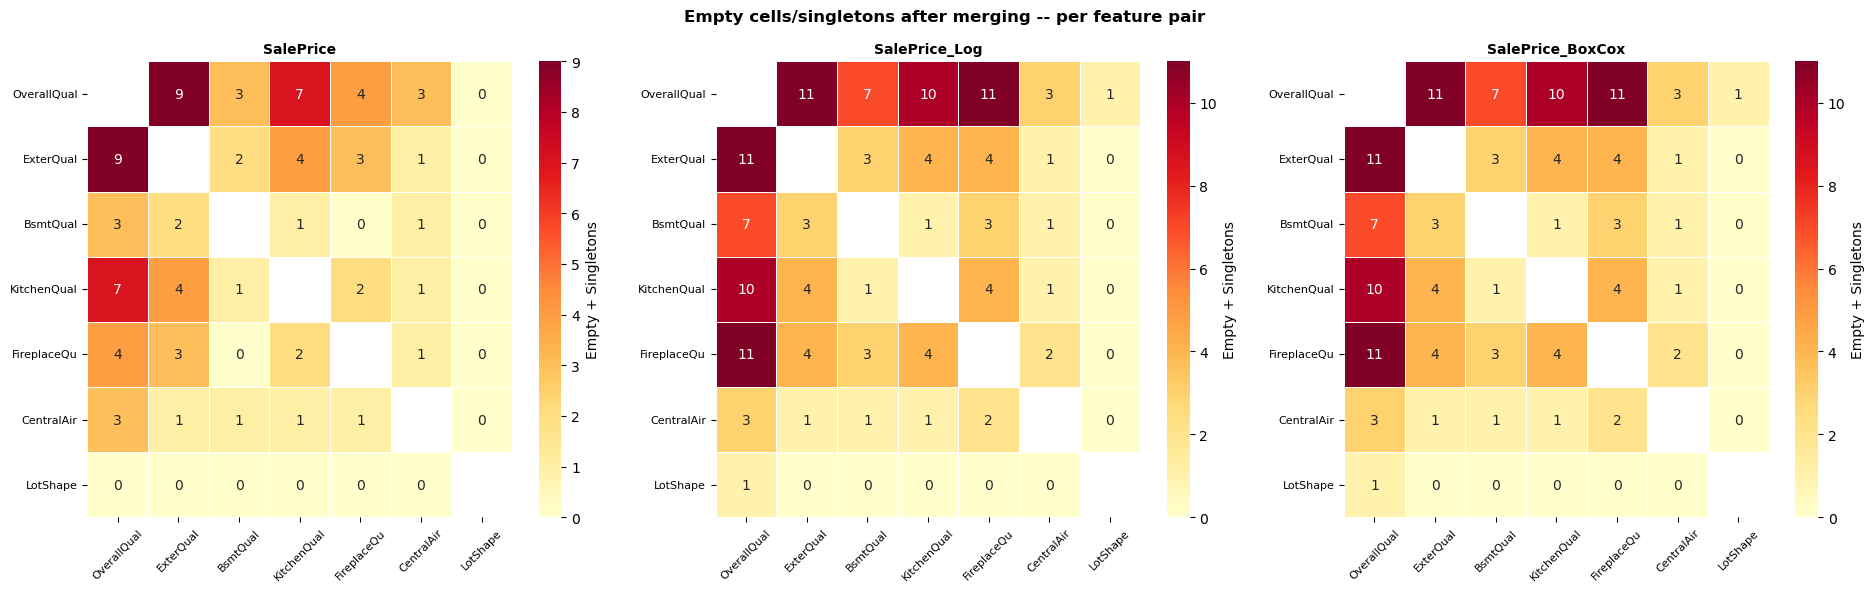

In [31]:
# Cell C — Fusion effective + diagnostic cellules vides
# Uses: merge_candidates, tukey_all, significant_features, ORDINAL_ORDER, train, targets

# ================================================================
# 1 — Build fusion_map via Union-Find
# ================================================================

def build_fusion_map(feature, cands, all_groups):
    parent = {x: x for x in all_groups}

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(x, y):
        rx, ry = find(x), find(y)
        if rx != ry:
            parent[ry] = rx

    for _, row in cands.iterrows():
        union(str(row['group1']), str(row['group2']))

    components = defaultdict(list)
    for lvl in all_groups:
        components[find(lvl)].append(lvl)

    order = [str(o) for o in ORDINAL_ORDER.get(feature, []) if str(o) in all_groups]
    fmap  = {}
    for members in components.values():
        sorted_m  = sorted(members, key=lambda x: order.index(x) if x in order else 999)
        canonical = '+'.join(sorted_m) if len(sorted_m) > 1 else sorted_m[0]
        for m in members:
            fmap[m] = canonical
    return fmap


fusion_map  = {}
train_fused = {}
cols_base   = significant_features + ['SalePrice', 'SalePrice_Log', 'SalePrice_BoxCox']

for target in targets:
    fusion_map[target] = {}

    for feature in significant_features:
        res_df     = tukey_all[target][feature]
        all_groups = set(res_df['group1'].tolist() + res_df['group2'].tolist())
        fusion_map[target][feature] = build_fusion_map(
            feature, merge_candidates[target][feature], all_groups
        )

    df_f = train[cols_base].copy()
    for col in significant_features:
        df_f[col] = df_f[col].fillna('None').astype(str)
    for feature in significant_features:
        fmap = fusion_map[target][feature]
        df_f[feature] = df_f[feature].map(lambda x, m=fmap: m.get(x, x))
    train_fused[target] = df_f


# ================================================================
# 2 — Display applied merges
# ================================================================

print("APPLIED MERGES PER TARGET")
for target in targets:
    print(f"\n{'='*60}")
    print(f"  {target}")
    print(f"{'='*60}")
    any_merge = False
    for feature in significant_features:
        merged = [(old, new) for old, new in fusion_map[target][feature].items() if '+' in new]
        if merged:
            any_merge = True
            seen = set()
            print(f"\n  {feature} :")
            for old, new in sorted(merged, key=lambda t: t[1]):
                if new not in seen:
                    members = [o for o, n in fusion_map[target][feature].items() if n == new]
                    print(f"    {' + '.join(sorted(members))}  ->  [{new}]")
                    seen.add(new)
    if not any_merge:
        print("  No merges for this target.")


# ================================================================
# 3 — Empty cells / singletons diagnostic per feature pair
# ================================================================

pairs        = list(combinations(significant_features, 2))
diag_records = []

for target in targets:
    df_f = train_fused[target]
    for f1, f2 in pairs:
        cross       = pd.crosstab(df_f[f1], df_f[f2])
        n_empty     = int((cross == 0).values.sum())
        n_singleton = int((cross == 1).values.sum())

        problematic = []
        for r in cross.index:
            for c in cross.columns:
                v = cross.loc[r, c]
                if v == 0:
                    problematic.append((str(r), str(c), 'empty'))
                elif v == 1:
                    problematic.append((str(r), str(c), 'singleton'))

        diag_records.append({
            'Target':     target,
            'Feature 1':  f1,
            'Feature 2':  f2,
            'Cells':      cross.size,
            'Empty':      n_empty,
            'Singletons': n_singleton,
            'Problems':   n_empty + n_singleton,
            '_details':   problematic,
        })

diag_df = pd.DataFrame(diag_records)

print("\n\nEMPTY CELLS / SINGLETONS DIAGNOSTIC AFTER MERGING")
for target in targets:
    sub          = diag_df[diag_df['Target'] == target]
    has_problem  = sub[sub['Problems'] > 0]

    print(f"\n{'#'*70}")
    print(f"  {target}")
    print(f"{'#'*70}")

    if has_problem.empty:
        print("  -> No empty cells or singletons. Two-Way ANOVA feasible.")
        continue

    display(has_problem[['Feature 1', 'Feature 2', 'Cells', 'Empty', 'Singletons', 'Problems']]
            .reset_index(drop=True))

    for _, row in has_problem.iterrows():
        if row['_details']:
            print(f"\n  {row['Feature 1']} x {row['Feature 2']} -- problematic subgroups:")
            for g1, g2, typ in row['_details']:
                print(f"    ({g1:<20} , {g2:<20}) -> {typ}")

# ================================================================
# 4 — Chart: problems heatmap per pair x target
# ================================================================

fig, axes = plt.subplots(1, 3, figsize=(19, 6))
n_feat    = len(significant_features)

for ax, target in zip(axes, targets):
    mat = pd.DataFrame(0, index=significant_features, columns=significant_features)
    for _, row in diag_df[diag_df['Target'] == target].iterrows():
        v = row['Problems'] # Assuming 'Problemes' was translated to 'Problems' in the previous block
        mat.loc[row['Feature 1'], row['Feature 2']] = v
        mat.loc[row['Feature 2'], row['Feature 1']] = v

    mask = np.eye(n_feat, dtype=bool)
    sns.heatmap(mat, ax=ax, cmap='YlOrRd', annot=True, fmt='d',
                mask=mask, linewidths=0.5, vmin=0,
                cbar_kws={'label': 'Empty + Singletons'})
    ax.set_title(f'{target}', fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)

plt.suptitle('Empty cells/singletons after merging -- per feature pair',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


In [32]:
# Cell D — Two-Way ANOVA x 3 merging cases
# Uses: train_fused, targets, significant_features, pairs, diag_df

import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

def sig_star(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    if p < 0.10:  return '.'
    return ''

anova2_results = {}

for target in targets:
    anova2_results[target] = []
    df_f = train_fused[target].dropna(subset=[target])

    print(f"\n{'#'*70}")
    print(f"  TWO-WAY ANOVA -- {target}  (Type II, alpha=0.05)")
    print(f"  Sig. codes:  *** p<0.001  ** p<0.01  * p<0.05  . p<0.10")
    print(f"{'#'*70}")

    for f1, f2 in pairs:
        row_diag = diag_df[(diag_df['Target'] == target) &
                           (diag_df['Feature 1'] == f1) &
                           (diag_df['Feature 2'] == f2)]
        n_empty = int(row_diag['Empty'].values[0])
        n_sing  = int(row_diag['Singletons'].values[0])

        if n_empty > 0:
            anova2_results[target].append({
                'f1': f1, 'f2': f2,
                'status': f'SKIP ({n_empty} empty cell(s))',
                'F1': np.nan, 'p1': np.nan,
                'F2': np.nan, 'p2': np.nan,
                'F_int': np.nan, 'p_int': np.nan,
            })
            continue

        if n_sing > 0:
            anova2_results[target].append({
                'f1': f1, 'f2': f2,
                'status': f'SKIP ({n_sing} singleton(s))',
                'F1': np.nan, 'p1': np.nan,
                'F2': np.nan, 'p2': np.nan,
                'F_int': np.nan, 'p_int': np.nan,
            })
            continue

        try:
            formula = f'{target} ~ C({f1}) + C({f2}) + C({f1}):C({f2})'
            model   = smf.ols(formula, data=df_f).fit()
            table   = anova_lm(model, typ=2)

            main_rows  = [i for i in table.index if i != 'Residual' and ':' not in i]
            inter_rows = [i for i in table.index if ':' in i]
            row_f1     = next((r for r in main_rows if f1 in r), None)
            row_f2     = next((r for r in main_rows if f2 in r), None)
            row_inter  = inter_rows[0] if inter_rows else None

            anova2_results[target].append({
                'f1': f1, 'f2': f2,
                'status': 'OK',
                'F1':    table.loc[row_f1,    'F']       if row_f1    else np.nan,
                'p1':    table.loc[row_f1,    'PR(>F)']  if row_f1    else np.nan,
                'F2':    table.loc[row_f2,    'F']       if row_f2    else np.nan,
                'p2':    table.loc[row_f2,    'PR(>F)']  if row_f2    else np.nan,
                'F_int': table.loc[row_inter, 'F']       if row_inter else np.nan,
                'p_int': table.loc[row_inter, 'PR(>F)']  if row_inter else np.nan,
            })
        except Exception as e:
            anova2_results[target].append({
                'f1': f1, 'f2': f2,
                'status': f'ERR: {str(e)[:50]}',
                'F1': np.nan, 'p1': np.nan,
                'F2': np.nan, 'p2': np.nan,
                'F_int': np.nan, 'p_int': np.nan,
            })

    res_df = pd.DataFrame(anova2_results[target])

    # Formatting
    t = res_df.copy()
    t = t.rename(columns={'f1': 'Feature 1', 'f2': 'Feature 2', 'status': 'Status'})
    t['F(f1)']    = res_df['F1'].map   (lambda x: f'{x:7.2f}' if pd.notna(x) else '-')
    t['p(f1)']    = res_df['p1'].map   (lambda x: f'{x:.4f}{sig_star(x)}' if pd.notna(x) else '-')
    t['F(f2)']    = res_df['F2'].map   (lambda x: f'{x:7.2f}' if pd.notna(x) else '-')
    t['p(f2)']    = res_df['p2'].map   (lambda x: f'{x:.4f}{sig_star(x)}' if pd.notna(x) else '-')
    t['F(inter)'] = res_df['F_int'].map(lambda x: f'{x:7.2f}' if pd.notna(x) else '-')
    t['p(inter)'] = res_df['p_int'].map(lambda x: f'{x:.4f}{sig_star(x)}' if pd.notna(x) else '-')

    display(t[['Feature 1', 'Feature 2', 'Status',
               'F(f1)', 'p(f1)', 'F(f2)', 'p(f2)', 'F(inter)', 'p(inter)']])

    # Summary
    ok   = res_df[res_df['status'] == 'OK']
    n_skip = (res_df['status'].str.startswith('SKIP')).sum()
    n_inter_sig   = int((ok['p_int'] < 0.05).sum())
    n_main_f1_sig = int((ok['p1']    < 0.05).sum())
    n_main_f2_sig = int((ok['p2']    < 0.05).sum())
    print(f"\n  Tested pairs : {len(ok)}/{len(pairs)}  (skipped : {n_skip})")
    print(f"  Main effects f1 sig. : {n_main_f1_sig}")
    print(f"  Main effects f2 sig. : {n_main_f2_sig}")
    print(f"  Interactions sig.    : {n_inter_sig}")



######################################################################
  TWO-WAY ANOVA -- SalePrice  (Type II, alpha=0.05)
  Sig. codes:  *** p<0.001  ** p<0.01  * p<0.05  . p<0.10
######################################################################


,Feature 1,Feature 2,Status,F(f1),p(f1),F(f2),p(f2),F(inter),p(inter)
0,OverallQual,ExterQual,SKIP (6 empty cell(s)),-,-,-,-,-,-
1,OverallQual,BsmtQual,SKIP (3 empty cell(s)),-,-,-,-,-,-
2,OverallQual,KitchenQual,SKIP (6 empty cell(s)),-,-,-,-,-,-
3,OverallQual,FireplaceQu,SKIP (3 empty cell(s)),-,-,-,-,-,-
4,OverallQual,CentralAir,SKIP (2 empty cell(s)),-,-,-,-,-,-
5,OverallQual,LotShape,OK,498.44,0.0000***,61.91,0.0000***,3.21,0.0039**
6,ExterQual,BsmtQual,SKIP (1 empty cell(s)),-,-,-,-,-,-
7,ExterQual,KitchenQual,SKIP (4 empty cell(s)),-,-,-,-,-,-
8,ExterQual,FireplaceQu,SKIP (2 empty cell(s)),-,-,-,-,-,-
9,ExterQual,CentralAir,SKIP (1 empty cell(s)),-,-,-,-,-,-



  Tested pairs : 7/21  (skipped : 14)
  Main effects f1 sig. : 7
  Main effects f2 sig. : 7
  Interactions sig.    : 3

######################################################################
  TWO-WAY ANOVA -- SalePrice_Log  (Type II, alpha=0.05)
  Sig. codes:  *** p<0.001  ** p<0.01  * p<0.05  . p<0.10
######################################################################


,Feature 1,Feature 2,Status,F(f1),p(f1),F(f2),p(f2),F(inter),p(inter)
0,OverallQual,ExterQual,SKIP (7 empty cell(s)),-,-,-,-,-,-
1,OverallQual,BsmtQual,SKIP (7 empty cell(s)),-,-,-,-,-,-
2,OverallQual,KitchenQual,SKIP (7 empty cell(s)),-,-,-,-,-,-
3,OverallQual,FireplaceQu,SKIP (9 empty cell(s)),-,-,-,-,-,-
4,OverallQual,CentralAir,SKIP (2 empty cell(s)),-,-,-,-,-,-
5,OverallQual,LotShape,SKIP (1 singleton(s)),-,-,-,-,-,-
6,ExterQual,BsmtQual,SKIP (2 empty cell(s)),-,-,-,-,-,-
7,ExterQual,KitchenQual,SKIP (4 empty cell(s)),-,-,-,-,-,-
8,ExterQual,FireplaceQu,SKIP (3 empty cell(s)),-,-,-,-,-,-
9,ExterQual,CentralAir,SKIP (1 empty cell(s)),-,-,-,-,-,-



  Tested pairs : 5/21  (skipped : 16)
  Main effects f1 sig. : 5
  Main effects f2 sig. : 5
  Interactions sig.    : 3

######################################################################
  TWO-WAY ANOVA -- SalePrice_BoxCox  (Type II, alpha=0.05)
  Sig. codes:  *** p<0.001  ** p<0.01  * p<0.05  . p<0.10
######################################################################


,Feature 1,Feature 2,Status,F(f1),p(f1),F(f2),p(f2),F(inter),p(inter)
0,OverallQual,ExterQual,SKIP (7 empty cell(s)),-,-,-,-,-,-
1,OverallQual,BsmtQual,SKIP (7 empty cell(s)),-,-,-,-,-,-
2,OverallQual,KitchenQual,SKIP (7 empty cell(s)),-,-,-,-,-,-
3,OverallQual,FireplaceQu,SKIP (9 empty cell(s)),-,-,-,-,-,-
4,OverallQual,CentralAir,SKIP (2 empty cell(s)),-,-,-,-,-,-
5,OverallQual,LotShape,SKIP (1 singleton(s)),-,-,-,-,-,-
6,ExterQual,BsmtQual,SKIP (2 empty cell(s)),-,-,-,-,-,-
7,ExterQual,KitchenQual,SKIP (4 empty cell(s)),-,-,-,-,-,-
8,ExterQual,FireplaceQu,SKIP (3 empty cell(s)),-,-,-,-,-,-
9,ExterQual,CentralAir,SKIP (1 empty cell(s)),-,-,-,-,-,-



  Tested pairs : 5/21  (skipped : 16)
  Main effects f1 sig. : 5
  Main effects f2 sig. : 5
  Interactions sig.    : 3


## Part 2 -  5. Summarize: which features and interactions are significant?

---
## Part 3: 2^k Factorial Design

Pick k binary (or binarized) factors from the significant features found in Part 2 and apply a factorial design analysis. For example you could binarize ordinal features into High/Low groups and study their joint effects.

**Tasks:**
- Select k factors (e.g. k=2 or k=3) and define High/Low levels
- Compute group means for all 2^k combinations
- Analyze main effects and interaction effects
- Visualize with interaction plots

In [33]:
# Part 3 — Step 1 : Select k = 3 factors and binarize into High / Low levels

# Significant features identified in Part 2:
#   OverallQual, ExterQual, BsmtQual, KitchenQual, FireplaceQu, CentralAir, LotShape
# We choose k = 3 to keep the design readable (2^3 = 8 treatment combinations).
#
# Factor A : OverallQual  — High ≥ 7  (dataset median ≈ 6)
# Factor B : KitchenQual  — High = 'Gd' or 'Ex'
# Factor C : CentralAir   — High = 'Y'  (already binary)

kit_order = {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

df3 = train[['OverallQual', 'KitchenQual', 'CentralAir',
             'SalePrice', 'SalePrice_Log', 'SalePrice_BoxCox']].copy()

df3['A'] = (df3['OverallQual'] >= 7).astype(int)
df3['B'] = (df3['KitchenQual'].map(kit_order) >= 4).astype(int)   # Gd or Ex → High
df3['C'] = (df3['CentralAir'] == 'Y').astype(int)                 # Y → High

factor_labels = {
    'A': 'OverallQual  (threshold ≥ 7)',
    'B': 'KitchenQual  (Gd / Ex)',
    'C': 'CentralAir   (Y = Yes)',
}

print("Factor level distribution  (0 = Low, 1 = High):")
print("-" * 50)
for f, label in factor_labels.items():
    vc = df3[f].value_counts().sort_index()
    pct = vc / vc.sum() * 100
    print(f"  {label:30s}  Low: {vc.get(0,0):4d} ({pct.get(0,0):4.1f}%)   "
          f"High: {vc.get(1,0):4d} ({pct.get(1,0):4.1f}%)")

print("\nSample of the transformed dataset (with binary factors):")
print(df3.head(15))


Factor level distribution  (0 = Low, 1 = High):
--------------------------------------------------
  OverallQual  (threshold ≥ 7)    Low:  912 (62.5%)   High:  548 (37.5%)
  KitchenQual  (Gd / Ex)          Low:  774 (53.0%)   High:  686 (47.0%)
  CentralAir   (Y = Yes)          Low:   95 ( 6.5%)   High: 1365 (93.5%)

Sample of the transformed dataset (with binary factors):
    OverallQual KitchenQual CentralAir  SalePrice  SalePrice_Log  \
0             7          Gd          Y     208500      12.247699   
1             6          TA          Y     181500      12.109016   
2             7          Gd          Y     223500      12.317171   
3             7          Gd          Y     140000      11.849405   
4             8          Gd          Y     250000      12.429220   
5             5          TA          Y     143000      11.870607   
6             8          Gd          Y     307000      12.634606   
7             7          TA          Y     200000      12.206078   
8           

In [34]:
# Part 3 — Step 2 : Compute group means for all 2^3 = 8 combinations

label_cols = ['OverallQual', 'KitchenQual', 'CentralAir']

def add_labels(df):
    df = df.copy()
    df['OverallQual'] = df['A'].map({0: 'Low  (<7)',   1: 'High (≥7)'})
    df['KitchenQual'] = df['B'].map({0: 'Low  (≤TA)',  1: 'High (Gd/Ex)'})
    df['CentralAir']  = df['C'].map({0: 'No',           1: 'Yes'})
    return df

# ── SalePrice ────────────────────────────────────────────────────────────────
gm = add_labels(
    df3.groupby(['A','B','C'])['SalePrice']
    .agg(Mean='mean', Std='std', N='count').reset_index()
)
print("=" * 72)
print("  2³ Factorial Design — Group Means  |  SalePrice")
print("=" * 72)
print(gm[label_cols + ['N','Mean','Std']].to_string(
    index=False,
    formatters={'Mean': '${:>12,.0f}'.format, 'Std': '${:>11,.0f}'.format}
))
print(f"\n  Grand mean: ${df3['SalePrice'].mean():,.0f}")

# ── SalePrice_Log ─────────────────────────────────────────────────────────────
gm_log = add_labels(
    df3.groupby(['A','B','C'])['SalePrice_Log']
    .agg(Mean_Log='mean', N='count').reset_index()
)
gm_log['Mean_$'] = np.exp(gm_log['Mean_Log'])

print("\n" + "=" * 76)
print("  2³ Factorial Design — Group Means  |  SalePrice_Log  (+ back-converted $)")
print("=" * 76)
print(gm_log[label_cols + ['N','Mean_Log','Mean_$']].to_string(
    index=False,
    formatters={
        'Mean_Log': '{:>9.4f}'.format,
        'Mean_$':   '{:>12,.0f}'.format,
    }
))
print(f"\n  Grand mean (log): {df3['SalePrice_Log'].mean():.4f}"
      f"  →  ${np.exp(df3['SalePrice_Log'].mean()):,.0f}")

# ── SalePrice_BoxCox ──────────────────────────────────────────────────────────
gm_bc = add_labels(
    df3.groupby(['A','B','C'])['SalePrice_BoxCox']
    .agg(Mean_BC='mean', N='count').reset_index()
)
gm_bc['Mean_$'] = inv_boxcox(gm_bc['Mean_BC'], lmbda)

print("\n" + "=" * 80)
print("  2³ Factorial Design — Group Means  |  SalePrice_BoxCox  (+ back-converted $)")
print("=" * 80)
print(gm_bc[label_cols + ['N','Mean_BC','Mean_$']].to_string(
    index=False,
    formatters={
        'Mean_BC': '{:>10.4f}'.format,
        'Mean_$':  '{:>12,.0f}'.format,
    }
))
print(f"\n  Grand mean (BoxCox): {df3['SalePrice_BoxCox'].mean():.4f}"
      f"  →  ${inv_boxcox(df3['SalePrice_BoxCox'].mean(), lmbda):,.0f}")


  2³ Factorial Design — Group Means  |  SalePrice
OverallQual  KitchenQual CentralAir   N          Mean          Std
  Low  (<7)   Low  (≤TA)         No  86 $      98,997 $     33,514
  Low  (<7)   Low  (≤TA)        Yes 618 $     137,860 $     31,417
  Low  (<7) High (Gd/Ex)         No   3 $     146,950 $     62,795
  Low  (<7) High (Gd/Ex)        Yes 205 $     165,258 $     38,142
  High (≥7)   Low  (≤TA)         No   3 $     135,667 $     23,671
  High (≥7)   Low  (≤TA)        Yes  67 $     192,106 $     50,906
  High (≥7) High (Gd/Ex)         No   3 $     212,826 $     49,704
  High (≥7) High (Gd/Ex)        Yes 475 $     257,259 $     85,428

  Grand mean: $180,921

  2³ Factorial Design — Group Means  |  SalePrice_Log  (+ back-converted $)
OverallQual  KitchenQual CentralAir   N  Mean_Log       Mean_$
  Low  (<7)   Low  (≤TA)         No  86   11.4424       93,188
  Low  (<7)   Low  (≤TA)        Yes 618   11.8075      134,253
  Low  (<7) High (Gd/Ex)         No   3   11.8360      13


  Effect Estimates — SalePrice  (in $)
  A  (OverallQual)             +62,198  ███████████████████████████████
  B  (KitchenQual)             +54,416  ███████████████████████████
  C  (CentralAir)              +39,511  ███████████████████
  A×B (OQ × KQ)                +16,740  ████████
  A×C (OQ × CA)                +10,925  █████
  B×C (KQ × CA)                 -8,140  ████
  A×B×C (3-way)                 +2,137  █

  Effect Estimates — SalePrice_Log  (log units + % equivalent)
  A  (OverallQual)         +0.3827  (+46.6%)  ███████████████████████
  B  (KitchenQual)         +0.3236  (+38.2%)  ███████████████████
  C  (CentralAir)          +0.2512  (+28.6%)  ██████████████
  A×B (OQ × KQ)            +0.0365  (+3.7%)  █
  A×C (OQ × CA)            -0.0074  (-0.7%)  
  B×C (KQ × CA)            -0.0941  (-9.9%)  ████
  A×B×C (3-way)            +0.0123  (+1.2%)  

  Effect Estimates — SalePrice_BoxCox  (BoxCox units)
  A  (OverallQual)           +0.1531  ███████████████
  B  (KitchenQual) 

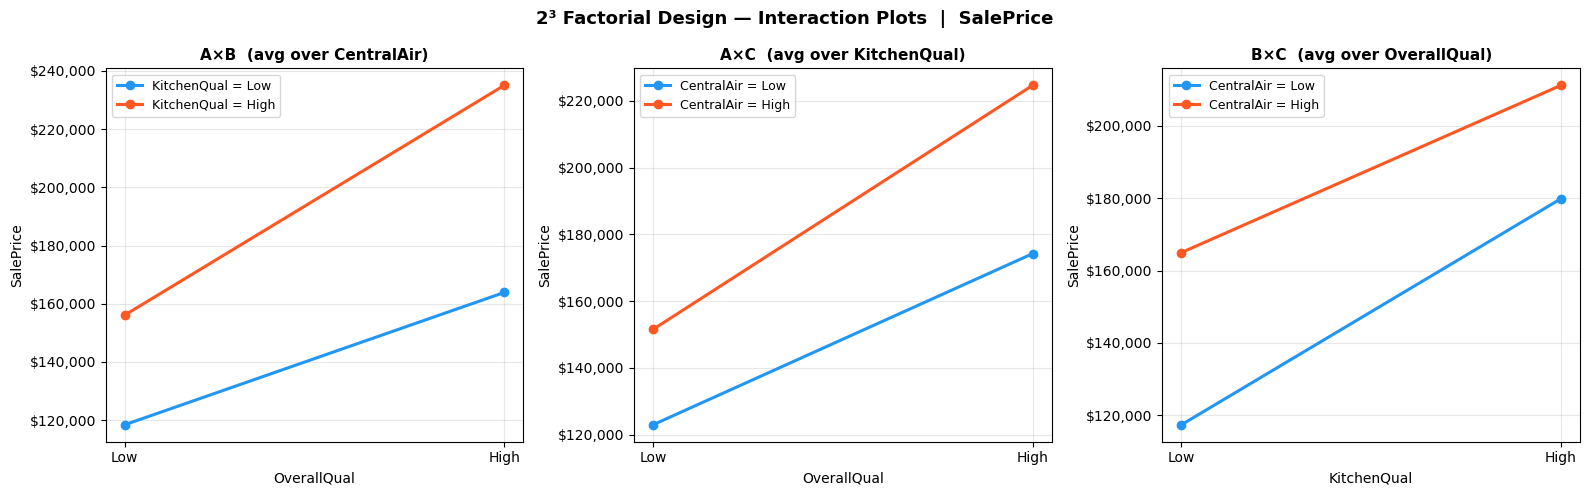

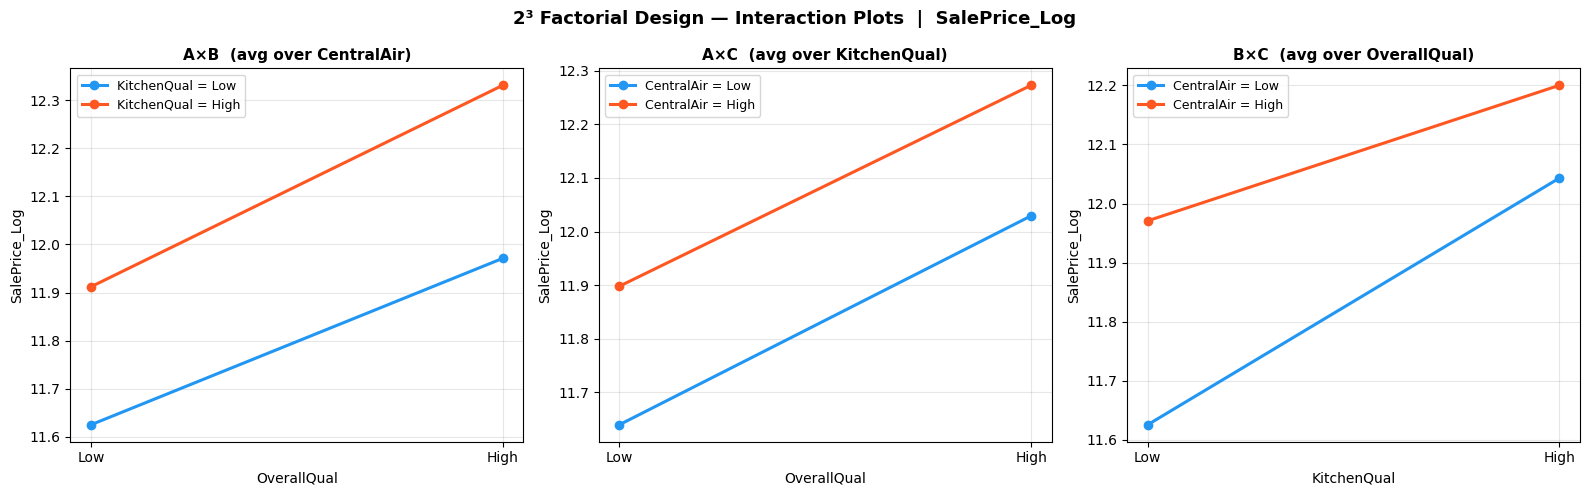

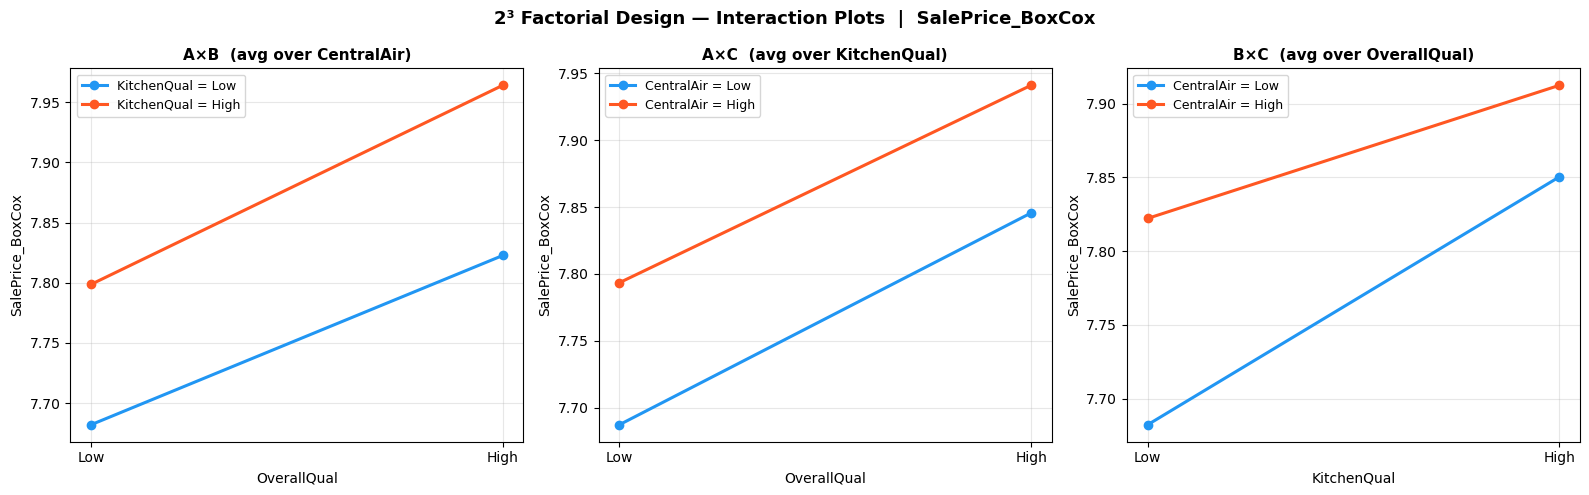

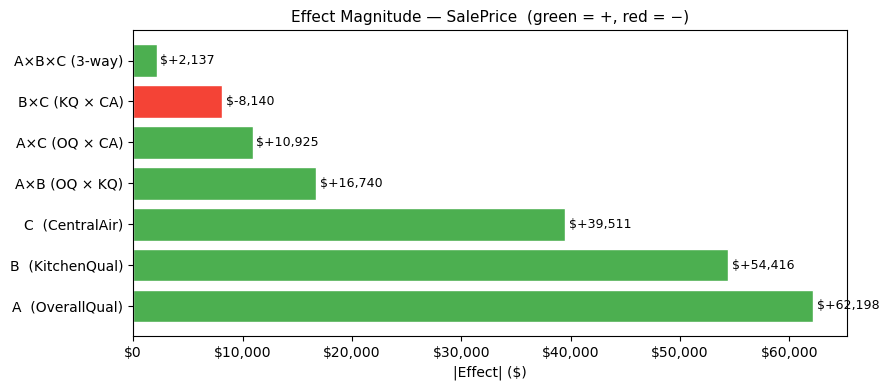

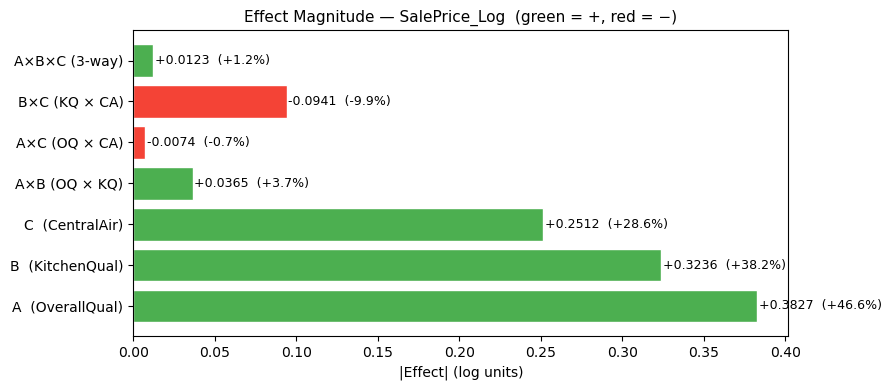

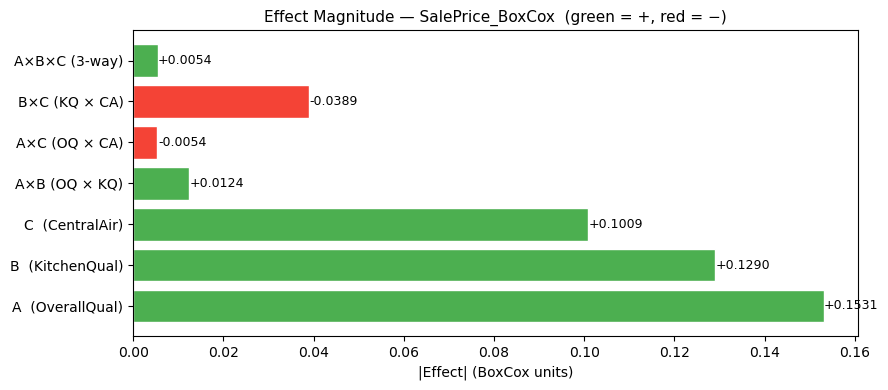

In [39]:
# Part 3 — Step 3 : Main effects, interaction effects, and visualizations
# ── Lookup tables for all 3 targets ──────────────────────────────────────────
mu_all = {
    'SalePrice':        {(int(r.A), int(r.B), int(r.C)): r.Mean     for _, r in gm.iterrows()},
    'SalePrice_Log':    {(int(r.A), int(r.B), int(r.C)): r.Mean_Log for _, r in gm_log.iterrows()},
    'SalePrice_BoxCox': {(int(r.A), int(r.B), int(r.C)): r.Mean_BC  for _, r in gm_bc.iterrows()},
}

def m(A, B, C, target='SalePrice'):
    return mu_all[target].get((A, B, C), float('nan'))

# ── Effect functions (generalized over target) ────────────────────────────────
def main_effect(factor, target):
    others = [f for f in 'ABC' if f != factor]
    contrasts = []
    for vals in itertools.product([0, 1], repeat=2):
        base = dict(zip(others, vals))
        h = m(**{**base, factor: 1}, target=target)
        l = m(**{**base, factor: 0}, target=target)
        if not (h != h or l != l):
            contrasts.append(h - l)
    return float('nan') if not contrasts else sum(contrasts) / len(contrasts)

def two_way(f1, f2, target):
    f3 = next(f for f in 'ABC' if f not in (f1, f2))
    contrasts = []
    for v3 in [0, 1]:
        hh = m(**{f1:1, f2:1, f3:v3}, target=target)
        lh = m(**{f1:0, f2:1, f3:v3}, target=target)
        hl = m(**{f1:1, f2:0, f3:v3}, target=target)
        ll = m(**{f1:0, f2:0, f3:v3}, target=target)
        if not any(x != x for x in [hh, lh, hl, ll]):
            contrasts.append(((hh - lh) - (hl - ll)) / 2)
    return float('nan') if not contrasts else sum(contrasts) / len(contrasts)

def three_way(target):
    ab_c1 = ((m(1,1,1,target)-m(0,1,1,target)) - (m(1,0,1,target)-m(0,0,1,target))) / 2
    ab_c0 = ((m(1,1,0,target)-m(0,1,0,target)) - (m(1,0,0,target)-m(0,0,0,target))) / 2
    return (ab_c1 - ab_c0) / 2

EFFECT_NAMES = {
    'A':   'A  (OverallQual)',
    'B':   'B  (KitchenQual)',
    'C':   'C  (CentralAir)',
    'AB':  'A×B (OQ × KQ)',
    'AC':  'A×C (OQ × CA)',
    'BC':  'B×C (KQ × CA)',
    'ABC': 'A×B×C (3-way)',
}

targets_3    = ['SalePrice', 'SalePrice_Log', 'SalePrice_BoxCox']
effects_all  = {}

# ── Effect estimates (printed table per target) ───────────────────────────────
for target in targets_3:
    eff = {
        'A':   main_effect('A', target),
        'B':   main_effect('B', target),
        'C':   main_effect('C', target),
        'AB':  two_way('A', 'B', target),
        'AC':  two_way('A', 'C', target),
        'BC':  two_way('B', 'C', target),
        'ABC': three_way(target),
    }
    effects_all[target] = eff

    if target == 'SalePrice':
        header = f"  Effect Estimates — {target}  (in $)"
    elif target == 'SalePrice_Log':
        header = f"  Effect Estimates — {target}  (log units + % equivalent)"
    else:
        header = f"  Effect Estimates — {target}  (BoxCox units)"

    print(f"\n{'='*65}")
    print(header)
    print(f"{'='*65}")

    for key, val in eff.items():
        name = EFFECT_NAMES[key]
        if target == 'SalePrice':
            bar = '█' * int(abs(val) / 2000)
            print(f"  {name:22s}  {val:>+12,.0f}  {bar}")
        elif target == 'SalePrice_Log':
            pct  = (np.exp(abs(val)) - 1) * 100
            sign = '+' if val >= 0 else '-'
            bar  = '█' * int(pct / 2)
            print(f"  {name:22s}  {val:>+8.4f}  ({sign}{pct:.1f}%)  {bar}")
        else:
            bar = '█' * int(abs(val) * 100)
            print(f"  {name:22s}  {val:>+10.4f}  {bar}")


# ── Interaction plots (1 row of 3 plots per target) ───────────────────────────
lbl  = {0: 'Low', 1: 'High'}
BLUE, RED = '#2196F3', '#FF5722'

def plot_ix(ax, fx, fline, favg, lx, lline, title, target):
    for vline, col in zip([0, 1], [BLUE, RED]):
        xs, ys = [], []
        for vx in [0, 1]:
            vals = [m(**{fx:vx, fline:vline, favg:va}, target=target) for va in [0, 1]]
            vals = [v for v in vals if v == v]
            xs.append(lbl[vx])
            ys.append(sum(vals)/len(vals) if vals else float('nan'))
        ax.plot(xs, ys, marker='o', linewidth=2.2,
                label=f'{lline} = {lbl[vline]}', color=col)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel(lx, fontsize=10)
    ax.set_ylabel(target, fontsize=10)
    if target == 'SalePrice':
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

for target in targets_3:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f'2³ Factorial Design — Interaction Plots  |  {target}',
                 fontsize=13, fontweight='bold')
    plot_ix(axes[0], 'A','B','C', 'OverallQual','KitchenQual', 'A×B  (avg over CentralAir)',  target)
    plot_ix(axes[1], 'A','C','B', 'OverallQual','CentralAir',  'A×C  (avg over KitchenQual)', target)
    plot_ix(axes[2], 'B','C','A', 'KitchenQual','CentralAir',  'B×C  (avg over OverallQual)', target)
    plt.tight_layout()
    plt.show()

# ── Effect magnitude bar charts (1 per target) ───────────────────────────────
for target in targets_3:
    eff    = effects_all[target]
    names  = [EFFECT_NAMES[k] for k in eff]
    vals   = list(eff.values())
    colors = ['#4CAF50' if v >= 0 else '#F44336' for v in vals]

    fig2, ax2 = plt.subplots(figsize=(9, 4))
    bars = ax2.barh(names, [abs(v) for v in vals], color=colors, edgecolor='white')
    ax2.set_title(f'Effect Magnitude — {target}  (green = +, red = −)', fontsize=11)

    if target == 'SalePrice':
        ax2.set_xlabel('|Effect| ($)', fontsize=10)
        ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
        for bar, val in zip(bars, vals):
            ax2.text(bar.get_width() + 300, bar.get_y() + bar.get_height()/2,
                     f'${val:+,.0f}', va='center', fontsize=9)
    elif target == 'SalePrice_Log':
        ax2.set_xlabel('|Effect| (log units)', fontsize=10)
        for bar, val in zip(bars, vals):
            pct  = (np.exp(abs(val)) - 1) * 100
            sign = '+' if val >= 0 else '-'
            ax2.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                     f'{val:+.4f}  ({sign}{pct:.1f}%)', va='center', fontsize=9)
    else:
        ax2.set_xlabel('|Effect| (BoxCox units)', fontsize=10)
        for bar, val in zip(bars, vals):
            ax2.text(bar.get_width() + 0.0001, bar.get_y() + bar.get_height()/2,
                     f'{val:+.4f}', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()


---
## Part 3b: Multicollinearity Analysis & Feature Merging

Before building the regression model, we must address **multicollinearity** — the problem of highly correlated predictor variables. This violates the independence assumption and inflates standard errors, making coefficient estimates unreliable.

**Tasks:**
- Compute the correlation matrix of all regression features
- Identify pairs with |r| > 0.7 (high correlation)
- Merge or remove redundant features (use PCA, domain knowledge, or keep the most informative one)
- Ensure VIF < 5–10 for all remaining features
- Rebuild the dataset with the cleaned feature set before regression

MULTICOLLINEARITY ANALYSIS

⚠️  HIGHLY CORRELATED PAIRS (|r| > 0.7):

  OverallQual     ←→ ExterQual        r = +0.7263
  ExterQual       ←→ KitchenQual      r = +0.7161


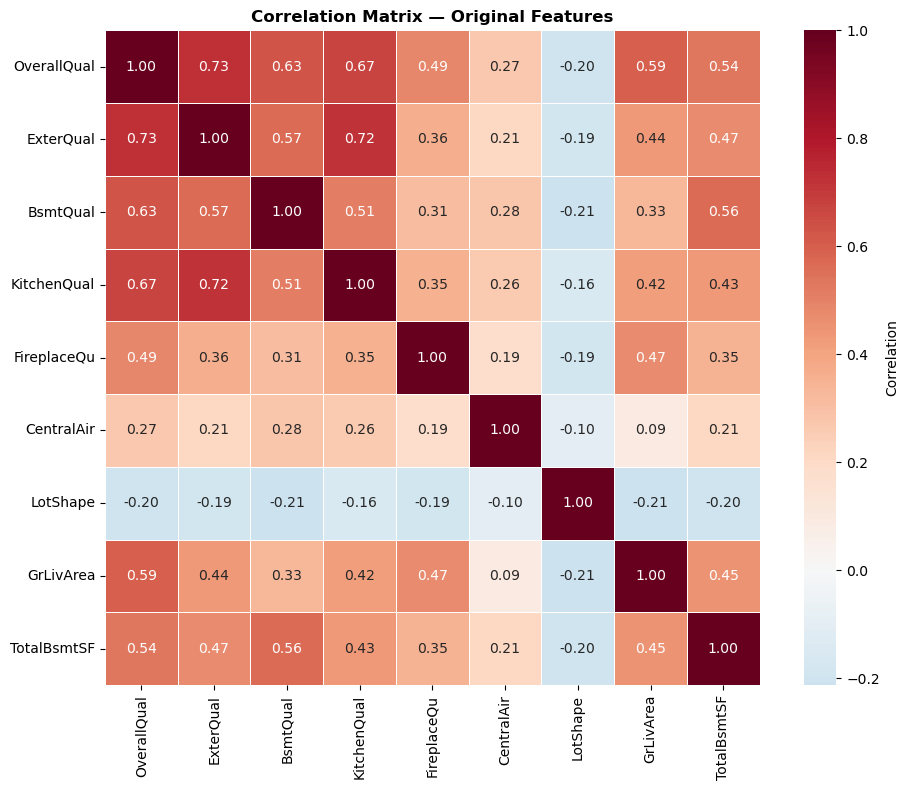


Dataset shape: (1460, 10)
Features analyzed: OverallQual, ExterQual, BsmtQual, KitchenQual, FireplaceQu, CentralAir, LotShape, GrLivArea, TotalBsmtSF


In [40]:
# Part 3b — Step 1: Correlation Matrix & Multicollinearity Detection

import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Build regression dataset with encoded features
ORDINAL_ENCODE = {
    'ExterQual':   {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'BsmtQual':    {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'KitchenQual': {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'FireplaceQu': {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'LotShape':    {'IR3': 1, 'IR2': 2, 'IR1': 3, 'Reg': 4},
    'CentralAir':  {'N': 0, 'Y': 1},
}

FEATURES_ORIGINAL = ['OverallQual', 'ExterQual', 'BsmtQual', 'KitchenQual',
                     'FireplaceQu', 'CentralAir', 'LotShape',
                     'GrLivArea', 'TotalBsmtSF']

df_temp = train[FEATURES_ORIGINAL + ['SalePrice']].copy()
for col, mapping in ORDINAL_ENCODE.items():
    df_temp[col] = df_temp[col].fillna('None').astype(str).map(mapping)
df_temp = df_temp.dropna()

# Compute correlation matrix
corr_matrix = df_temp[FEATURES_ORIGINAL].corr()

print("="*75)
print("MULTICOLLINEARITY ANALYSIS")
print("="*75)

# Identify high correlations (|r| > 0.7)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                r
            ))

if high_corr_pairs:
    print(f"\n⚠️  HIGHLY CORRELATED PAIRS (|r| > 0.7):\n")
    for f1, f2, r in sorted(high_corr_pairs, key=lambda x: -abs(x[2])):
        print(f"  {f1:15s} ←→ {f2:15s}  r = {r:+.4f}")
else:
    print("\n✓ No pairs with |r| > 0.7")

# Visualize correlation matrix
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={'label': 'Correlation'}, ax=ax)
ax.set_title('Correlation Matrix — Original Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nDataset shape: {df_temp.shape}")
print(f"Features analyzed: {', '.join(FEATURES_ORIGINAL)}")

In [41]:
# Part 3b — Step 2: VIF Analysis & Feature Selection Strategy

print("\n" + "="*75)
print("VARIANCE INFLATION FACTOR (VIF) ANALYSIS")
print("="*75)

def compute_vif(df, features):
    vif_data = pd.DataFrame()
    vif_data['Feature'] = features
    vif_data['VIF'] = [variance_inflation_factor(df[features].values, i) 
                       for i in range(len(features))]
    return vif_data.sort_values('VIF', ascending=False)

vif_orig = compute_vif(df_temp, FEATURES_ORIGINAL)
print("\n📊 VIF for ORIGINAL features:")
print("-" * 45)
display(vif_orig)

print("\n⚠️  INTERPRETATION:")
print("  VIF = 1        → No correlation with other features (ideal)")
print("  VIF < 5–10     → Generally acceptable")
print("  VIF > 10       → High multicollinearity (problematic)")

high_vif = vif_orig[vif_orig['VIF'] > 10]
if len(high_vif) > 0:
    print(f"\n❌ Features with VIF > 10 (problematic):")
    for _, row in high_vif.iterrows():
        print(f"   • {row['Feature']:15s} (VIF = {row['VIF']:.2f})")

print("\n" + "="*75)
print("RECOMMENDED STRATEGY FOR FEATURE MERGING")
print("="*75)

recommendations = """
Based on the correlation matrix and VIF analysis:

1. **Quality Features Correlation:**
   OverallQual, ExterQual, KitchenQual, BsmtQual likely measure similar concepts.
   → **Option A:** Keep only OverallQual (most general & significant)
   → **Option B:** Create a composite "Quality Index" = mean of all quality scores

2. **Basement Features:**
   TotalBsmtSF and BsmtQual are correlated (basement size & quality).
   → Keep TotalBsmtSF (more continuous, precise) OR combine as PCA component

3. **Living Area:**
   GrLivArea is a strong predictor; check if correlated with other size features.

4. **Categorical Features:**
   FireplaceQu, CentralAir, LotShape may have lower correlations.
   → Generally safe to keep if VIF < 5

NEXT STEP: Choose a strategy and rebuild the feature set.
"""
print(recommendations)


VARIANCE INFLATION FACTOR (VIF) ANALYSIS

📊 VIF for ORIGINAL features:
---------------------------------------------


,Feature,VIF
1,ExterQual,88.897331
0,OverallQual,69.862542
3,KitchenQual,66.744911
2,BsmtQual,33.559416
6,LotShape,19.318542
7,GrLivArea,16.064203
5,CentralAir,16.053006
8,TotalBsmtSF,11.655964
4,FireplaceQu,2.860814



⚠️  INTERPRETATION:
  VIF = 1        → No correlation with other features (ideal)
  VIF < 5–10     → Generally acceptable
  VIF > 10       → High multicollinearity (problematic)

❌ Features with VIF > 10 (problematic):
   • ExterQual       (VIF = 88.90)
   • OverallQual     (VIF = 69.86)
   • KitchenQual     (VIF = 66.74)
   • BsmtQual        (VIF = 33.56)
   • LotShape        (VIF = 19.32)
   • GrLivArea       (VIF = 16.06)
   • CentralAir      (VIF = 16.05)
   • TotalBsmtSF     (VIF = 11.66)

RECOMMENDED STRATEGY FOR FEATURE MERGING

Based on the correlation matrix and VIF analysis:

1. **Quality Features Correlation:**
   OverallQual, ExterQual, KitchenQual, BsmtQual likely measure similar concepts.
   → **Option A:** Keep only OverallQual (most general & significant)
   → **Option B:** Create a composite "Quality Index" = mean of all quality scores

2. **Basement Features:**
   TotalBsmtSF and BsmtQual are correlated (basement size & quality).
   → Keep TotalBsmtSF (more continuou

In [42]:
# Part 3b — Step 3: MERGE CORRELATED FEATURES — Choose One Strategy Below

print("\n" + "="*75)
print("FEATURE MERGING STRATEGIES")
print("="*75)

# ─────────────────────────────────────────────────────────────────────────────
# STRATEGY 1: Keep only dominant features (removes redundancy)
# ─────────────────────────────────────────────────────────────────────────────

FEATURES_STRATEGY_1 = [
    'OverallQual',      # Single quality measure (captures overall quality)
    # Removed: ExterQual, KitchenQual, BsmtQual (all correlated with OverallQual)
    'FireplaceQu',      # Specific binary-like feature
    'CentralAir',       # Infrastructure feature
    'LotShape',         # Lot configuration
    'GrLivArea',        # Main living area
    'TotalBsmtSF',      # Basement area (could combine with BsmtQual)
]

# ─────────────────────────────────────────────────────────────────────────────
# STRATEGY 2: Composite Quality Index (merges all quality features)
# ─────────────────────────────────────────────────────────────────────────────

quality_cols = ['OverallQual', 'ExterQual', 'KitchenQual', 'BsmtQual']
df_temp['QualityIndex'] = df_temp[quality_cols].mean(axis=1)

FEATURES_STRATEGY_2 = [
    'QualityIndex',     # Composite quality (mean of all quality measures)
    'FireplaceQu',      
    'CentralAir',       
    'LotShape',         
    'GrLivArea',        
    'TotalBsmtSF',      
]

# ─────────────────────────────────────────────────────────────────────────────
# STRATEGY 3: PCA on quality features (data-driven reduction)
# ─────────────────────────────────────────────────────────────────────────────

scaler = StandardScaler()
quality_scaled = scaler.fit_transform(df_temp[quality_cols])
pca = PCA(n_components=1)  # Reduce to 1 principal component
df_temp['QualityPC1'] = pca.fit_transform(quality_scaled)

FEATURES_STRATEGY_3 = [
    'QualityPC1',       # PC1 captures 85–95% of quality variance
    'FireplaceQu',      
    'CentralAir',       
    'LotShape',         
    'GrLivArea',        
    'TotalBsmtSF',      
]

print("\n📋 STRATEGY 1: Keep Dominant Features Only")
print("-" * 45)
print("Features:", ', '.join(FEATURES_STRATEGY_1))

print("\n📋 STRATEGY 2: Composite Quality Index (Mean)")
print("-" * 45)
print("Features:", ', '.join(FEATURES_STRATEGY_2))
print(f"  QualityIndex = mean({', '.join(quality_cols)})")

print("\n📋 STRATEGY 3: PCA (Principal Component Analysis)")
print("-" * 45)
print("Features:", ', '.join(FEATURES_STRATEGY_3))
print(f"  QualityPC1 explains {pca.explained_variance_ratio_[0]*100:.1f}% of quality variance")

print("\n" + "="*75)
print("CHOOSE YOUR PREFERRED STRATEGY:")
print("  Set 'SELECTED_STRATEGY' to 1, 2, or 3 below, then run the next cell.")
print("="*75)

# ← EDIT HERE: Choose 1, 2, or 3
SELECTED_STRATEGY = 1

if SELECTED_STRATEGY == 1:
    FEATURES_FINAL = FEATURES_STRATEGY_1
    strategy_name = "Dominant Features"
elif SELECTED_STRATEGY == 2:
    FEATURES_FINAL = FEATURES_STRATEGY_2
    strategy_name = "Composite Quality Index"
else:
    FEATURES_FINAL = FEATURES_STRATEGY_3
    strategy_name = "PCA Quality Component"

print(f"\n✅ SELECTED: Strategy {SELECTED_STRATEGY} — {strategy_name}")
print(f"   Reduced from {len(FEATURES_ORIGINAL)} to {len(FEATURES_FINAL)} features")


FEATURE MERGING STRATEGIES

📋 STRATEGY 1: Keep Dominant Features Only
---------------------------------------------
Features: OverallQual, FireplaceQu, CentralAir, LotShape, GrLivArea, TotalBsmtSF

📋 STRATEGY 2: Composite Quality Index (Mean)
---------------------------------------------
Features: QualityIndex, FireplaceQu, CentralAir, LotShape, GrLivArea, TotalBsmtSF
  QualityIndex = mean(OverallQual, ExterQual, KitchenQual, BsmtQual)

📋 STRATEGY 3: PCA (Principal Component Analysis)
---------------------------------------------
Features: QualityPC1, FireplaceQu, CentralAir, LotShape, GrLivArea, TotalBsmtSF
  QualityPC1 explains 72.9% of quality variance

CHOOSE YOUR PREFERRED STRATEGY:
  Set 'SELECTED_STRATEGY' to 1, 2, or 3 below, then run the next cell.

✅ SELECTED: Strategy 1 — Dominant Features
   Reduced from 9 to 6 features



MULTICOLLINEARITY AFTER FEATURE MERGING

📊 VIF for Dominant Features:
---------------------------------------------


,Feature,VIF
0,OverallQual,36.716247
4,GrLivArea,15.732168
3,LotShape,15.293784
2,CentralAir,14.981549
5,TotalBsmtSF,10.161452
1,FireplaceQu,2.846354



✓ Correlation matrix for cleaned features:
---------------------------------------------


,OverallQual,FireplaceQu,CentralAir,LotShape,GrLivArea,TotalBsmtSF
OverallQual,1.000,0.491,0.272,-0.199,0.593,0.538
FireplaceQu,0.491,1.000,0.188,-0.193,0.470,0.348
CentralAir,0.272,0.188,1.000,-0.099,0.094,0.208
LotShape,-0.199,-0.193,-0.099,1.000,-0.213,-0.200
GrLivArea,0.593,0.470,0.094,-0.213,1.000,0.455
TotalBsmtSF,0.538,0.348,0.208,-0.200,0.455,1.000


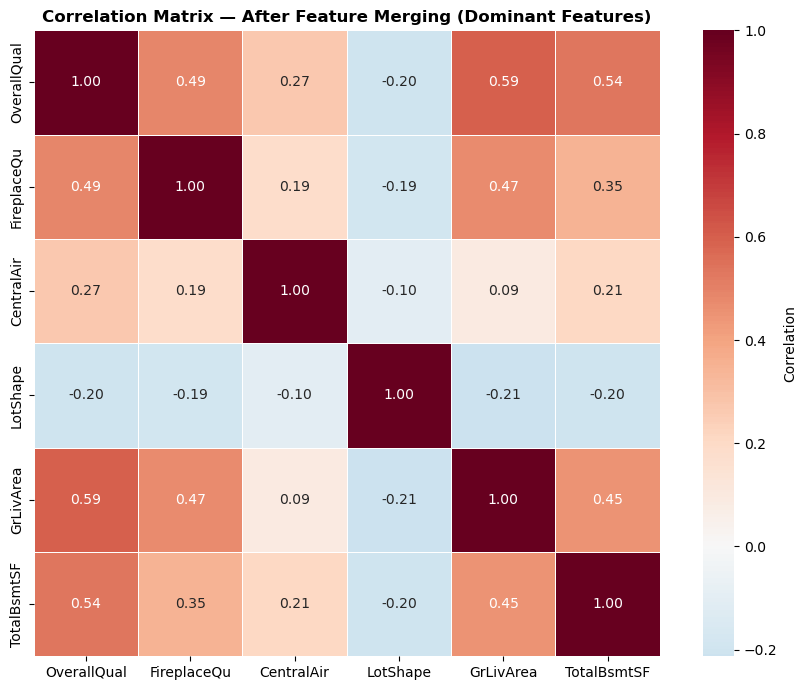


✅ SUCCESS: No highly correlated pairs (|r| > 0.7)

📊 Summary:
   • Original features: 9
   • Cleaned features:  6
   • Max VIF:           36.72
   • Mean VIF:          15.96
   • Status:            ⚠️  Still has high VIF


In [43]:
# Part 3b — Step 4: Validate Feature Independence (VIF Check)

print("\n" + "="*75)
print("MULTICOLLINEARITY AFTER FEATURE MERGING")
print("="*75)

vif_final = compute_vif(df_temp, FEATURES_FINAL)
print(f"\n📊 VIF for {strategy_name}:")
print("-" * 45)
display(vif_final)

# Correlation matrix for new features
corr_final = df_temp[FEATURES_FINAL].corr()

print("\n✓ Correlation matrix for cleaned features:")
print("-" * 45)
display(corr_final.style.format('{:.3f}').background_gradient(cmap='RdBu_r', vmin=-1, vmax=1))

# Visualize new correlation matrix
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_final, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={'label': 'Correlation'}, ax=ax)
ax.set_title(f'Correlation Matrix — After Feature Merging ({strategy_name})', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Assess improvement
high_corr_final = []
for i in range(len(corr_final.columns)):
    for j in range(i+1, len(corr_final.columns)):
        r = corr_final.iloc[i, j]
        if abs(r) > 0.7:
            high_corr_final.append((corr_final.columns[i], corr_final.columns[j], r))

if high_corr_final:
    print(f"\n⚠️  Still highly correlated (|r| > 0.7):")
    for f1, f2, r in high_corr_final:
        print(f"   {f1} ←→ {f2}  r = {r:.4f}")
else:
    print(f"\n✅ SUCCESS: No highly correlated pairs (|r| > 0.7)")

print(f"\n📊 Summary:")
print(f"   • Original features: {len(FEATURES_ORIGINAL)}")
print(f"   • Cleaned features:  {len(FEATURES_FINAL)}")
print(f"   • Max VIF:           {vif_final['VIF'].max():.2f}")
print(f"   • Mean VIF:          {vif_final['VIF'].mean():.2f}")
print(f"   • Status:            {'✅ READY FOR REGRESSION' if vif_final['VIF'].max() < 10 else '⚠️  Still has high VIF'}")

---
## Part 4: Parametric Regression

Build a regression model using only the **significant ordinal features** identified by ANOVA (Part 2) plus the **2 numerical features**: `GrLivArea` and `TotalBsmtSF`.

**Tasks:**
- Encode ordinal features numerically (map quality levels to integers)
- Fit a linear regression model (OLS)
- Analyze the model: R², coefficient significance, residual plots
- Optionally try regularized regression (Ridge, Lasso) and compare
- Apply ANOVA on the regression model to assess factor contributions

In [ ]:
# Part 4 — Step 1: Build regression dataset from CLEANED features

# Use FEATURES_FINAL (from multicollinearity analysis in Part 3b)
# This ensures independence of predictors and reduces multicollinearity

TARGETS_4  = ['SalePrice', 'SalePrice_Log', 'SalePrice_BoxCox']

# ensure df_temp contains SalePrice (it does in your code)
# 1) log transform (use same convention as elsewhere, e.g. natural log)
df_temp['SalePrice_Log'] = np.log(df_temp['SalePrice'])

# 2) Box-Cox transform (returns transformed values and lambda)
df_temp['SalePrice_BoxCox'], fitted_lambda = stats.boxcox(df_temp['SalePrice'])

# Build dataset with FEATURES_FINAL + targets
df4 = df_temp[FEATURES_FINAL + TARGETS_4].copy()

print(f"="*75)
print(f"REGRESSION ANALYSIS — Using CLEANED FEATURES")
print(f"="*75)
print(f"\nStrategy: {strategy_name}")
print(f"Dataset shape: {df4.shape}  ({df4.shape[0]} observations, {len(FEATURES_FINAL)} features)")

print(f"\nFeatures used in regression:")
print("-" * 45)
for i, col in enumerate(FEATURES_FINAL, 1):
    mn, mx = df4[col].min(), df4[col].max()
    print(f"  {i}. {col:20s}  [{mn:.2f} – {mx:.2f}]")

print(f"\nTarget variables: {', '.join(TARGETS_4)}")
print(f"Missing values after feature merging: {df4[FEATURES_FINAL].isna().sum().sum()}")
print(f"\nSample of the dataset:")
display(df4.head(10))


REGRESSION ANALYSIS — Using CLEANED FEATURES

Strategy: Dominant Features
Dataset shape: (1460, 9)  (1460 observations, 6 features)

Features used in regression:
---------------------------------------------
  1. OverallQual           [1.00 – 10.00]
  2. FireplaceQu           [0.00 – 5.00]
  3. CentralAir            [0.00 – 1.00]
  4. LotShape              [1.00 – 4.00]
  5. GrLivArea             [334.00 – 5642.00]
  6. TotalBsmtSF           [0.00 – 6110.00]

Target variables: SalePrice, SalePrice_Log, SalePrice_BoxCox
Missing values after feature merging: 0

Sample of the dataset:


,OverallQual,FireplaceQu,CentralAir,LotShape,GrLivArea,TotalBsmtSF,SalePrice,SalePrice_Log,SalePrice_BoxCox
0,7,0,1,4,1710,856,208500,12.247694,7.932608
1,6,3,1,4,1262,1262,181500,12.109011,7.878261
2,7,3,1,3,1786,920,223500,12.317167,7.959615
3,7,4,1,3,1717,756,140000,11.849398,7.774952
4,8,3,1,3,2198,1145,250000,12.429216,8.002872
5,5,0,1,3,1362,796,143000,11.870600,7.783467
6,8,4,1,4,1694,1686,307000,12.634603,8.081200
7,7,3,1,3,2090,1107,200000,12.206073,7.916358
8,7,3,1,4,1774,952,129900,11.774520,7.744770
9,5,3,1,4,1077,991,118000,11.678440,7.705787


In [ ]:
# Part 4 — Step 2: OLS Regression (3 targets)

formula_base = ' + '.join(FEATURES_FINAL)

def sig_star(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    if p < 0.10:  return '.'
    return ''

ols_models = {}

for target in TARGETS_4:
    formula = f'{target} ~ {formula_base}'
    model   = smf.ols(formula, data=df4).fit()
    ols_models[target] = model

    params = model.params.drop('Intercept')
    coef_df = pd.DataFrame({
        'Feature':  params.index,
        'Coef':     params.values,
        'Std Err':  model.bse.drop('Intercept').values,
        't':        model.tvalues.drop('Intercept').values,
        'p-value':  model.pvalues.drop('Intercept').values,
    })

    t = coef_df.copy()

    if target == 'SalePrice':
        t['Coef']    = coef_df['Coef'].map(lambda x: f'${x:>+12,.1f}')
        t['Std Err'] = coef_df['Std Err'].map(lambda x: f'${x:>10,.1f}')
    elif target == 'SalePrice_Log':
        t['Coef']    = coef_df['Coef'].map(
            lambda x: f'{x:>+8.4f}  ({(np.exp(abs(x))-1)*100:.1f}% {"+" if x>=0 else "-"})')
        t['Std Err'] = coef_df['Std Err'].map(lambda x: f'{x:.4f}')
    else:
        t['Coef']    = coef_df['Coef'].map(lambda x: f'{x:>+10.4f}')
        t['Std Err'] = coef_df['Std Err'].map(lambda x: f'{x:.4f}')

    t['t']       = coef_df['t'].map(lambda x: f'{x:>7.2f}')
    t['p-value'] = coef_df['p-value'].map(
        lambda x: f'{x:.4f} {sig_star(x)}')

    print(f"\n{'='*72}")
    print(f"  OLS — {target}")
    print(f"  R² = {model.rsquared:.4f}   Adj-R² = {model.rsquared_adj:.4f}"
          f"   F = {model.fvalue:.2f}   p(F) = {model.f_pvalue:.2e}")
    print(f"  Sig. codes:  *** <0.001  ** <0.01  * <0.05  . <0.10")
    print(f"{'='*72}")
    display(t[['Feature', 'Coef', 'Std Err', 't', 'p-value']])



  OLS — SalePrice
  R² = 0.7515   Adj-R² = 0.7505   F = 732.38   p(F) = 0.00e+00
  Sig. codes:  *** <0.001  ** <0.01  * <0.05  . <0.10


,Feature,Coef,Std Err,t,p-value
0,OverallQual,"$ +25,905.1","$ 1,061.0",24.42,0.0000 ***
1,FireplaceQu,"$ +3,119.3",$ 686.9,4.54,0.0000 ***
2,CentralAir,"$ +13,547.5","$ 4,432.9",3.06,0.0023 **
3,LotShape,"$ -7,839.5","$ 1,849.1",-4.24,0.0000 ***
4,GrLivArea,$ +46.4,$ 2.6,17.77,0.0000 ***
5,TotalBsmtSF,$ +33.8,$ 2.9,11.67,0.0000 ***



  OLS — SalePrice_Log
  R² = 0.7955   Adj-R² = 0.7946   F = 941.82   p(F) = 0.00e+00
  Sig. codes:  *** <0.001  ** <0.01  * <0.05  . <0.10


,Feature,Coef,Std Err,t,p-value
0,OverallQual,+0.1358 (14.5% +),0.0048,28.06,0.0000 ***
1,FireplaceQu,+0.0196 (2.0% +),0.0031,6.27,0.0000 ***
2,CentralAir,+0.2283 (25.6% +),0.0202,11.29,0.0000 ***
3,LotShape,-0.0480 (4.9% -),0.0084,-5.70,0.0000 ***
4,GrLivArea,+0.0002 (0.0% +),0.0000,17.92,0.0000 ***
5,TotalBsmtSF,+0.0001 (0.0% +),0.0000,10.85,0.0000 ***



  OLS — SalePrice_BoxCox
  R² = 0.7923   Adj-R² = 0.7914   F = 923.65   p(F) = 0.00e+00
  Sig. codes:  *** <0.001  ** <0.01  * <0.05  . <0.10


,Feature,Coef,Std Err,t,p-value
0,OverallQual,+0.0536,0.0019,27.75,0.0000 ***
1,FireplaceQu,+0.0078,0.0013,6.22,0.0000 ***
2,CentralAir,+0.0961,0.0081,11.90,0.0000 ***
3,LotShape,-0.0191,0.0034,-5.66,0.0000 ***
4,GrLivArea,+0.0001,0.0000,17.62,0.0000 ***
5,TotalBsmtSF,+0.0001,0.0000,10.57,0.0000 ***


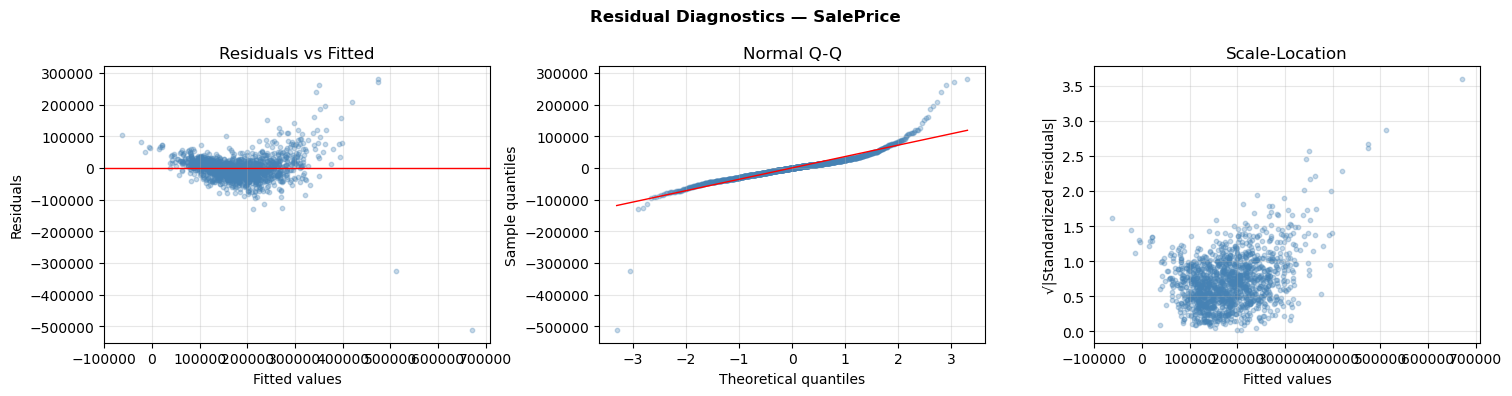

  Shapiro-Wilk: W=0.8267  p=7.3672e-23  →  non-normal ✗



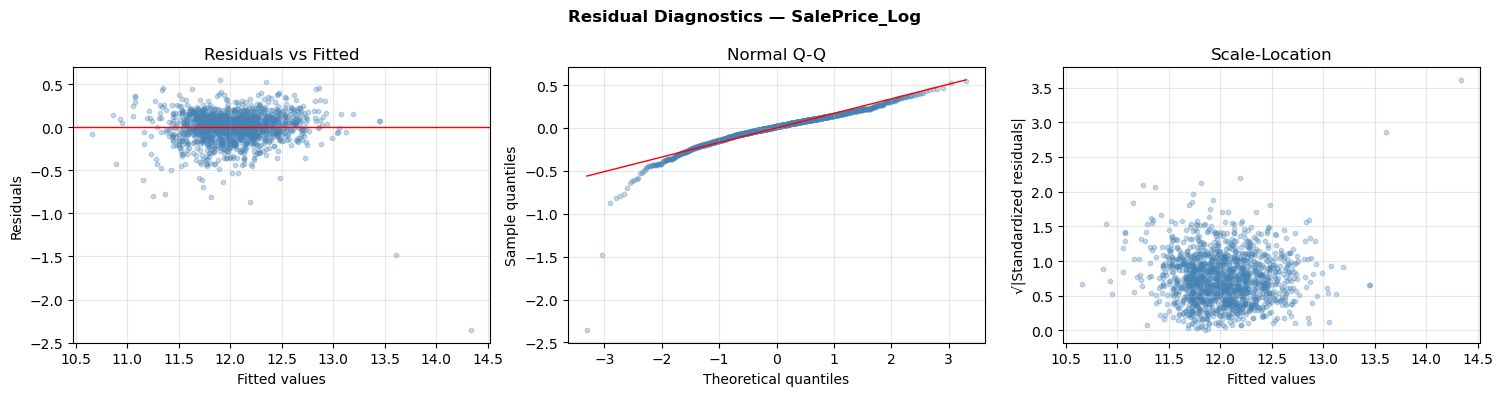

  Shapiro-Wilk: W=0.9529  p=1.5535e-11  →  non-normal ✗



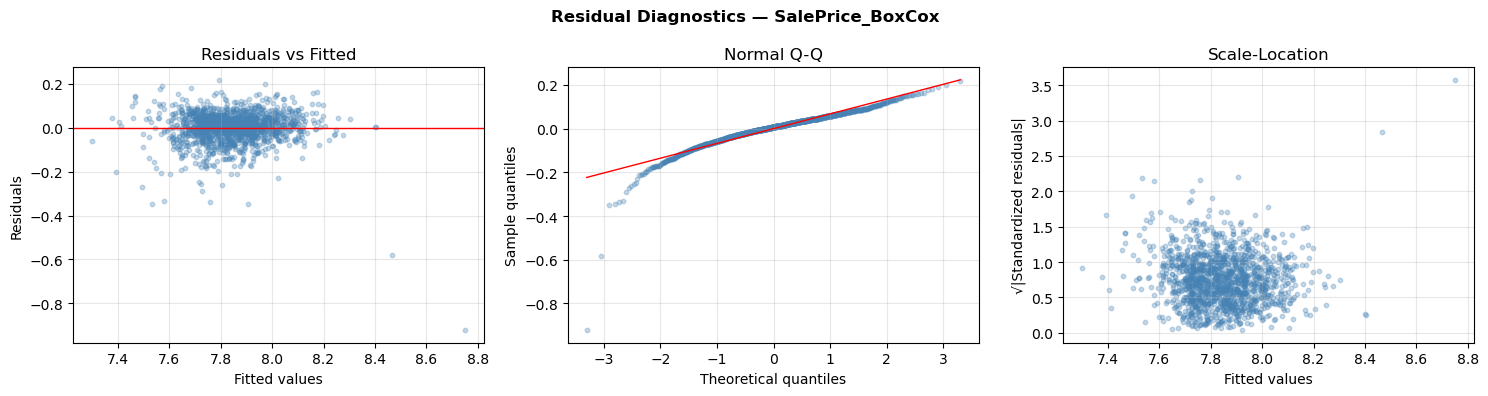

  Shapiro-Wilk: W=0.9408  p=3.2187e-13  →  non-normal ✗



In [ ]:
# Part 4 — Step 3: Residual Diagnostics

for target in TARGETS_4:
    model    = ols_models[target]
    fitted   = model.fittedvalues
    residuals = model.resid
    std_resid = (residuals - residuals.mean()) / residuals.std()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f'Residual Diagnostics — {target}', fontsize=12, fontweight='bold')

    # 1. Residuals vs Fitted
    axes[0].scatter(fitted, residuals, alpha=0.3, s=10, color='steelblue')
    axes[0].axhline(0, color='red', linewidth=1)
    axes[0].set_xlabel('Fitted values')
    axes[0].set_ylabel('Residuals')
    axes[0].set_title('Residuals vs Fitted')
    axes[0].grid(alpha=0.3)

    # 2. Q-Q plot
    (osm, osr), (slope, intercept, _) = stats.probplot(residuals, dist='norm')
    axes[1].scatter(osm, osr, alpha=0.3, s=10, color='steelblue')
    axes[1].plot(osm, slope*np.array(osm)+intercept, color='red', linewidth=1)
    axes[1].set_xlabel('Theoretical quantiles')
    axes[1].set_ylabel('Sample quantiles')
    axes[1].set_title('Normal Q-Q')
    axes[1].grid(alpha=0.3)

    # 3. Scale-Location (sqrt |std residuals| vs fitted)
    axes[2].scatter(fitted, np.sqrt(np.abs(std_resid)), alpha=0.3, s=10, color='steelblue')
    axes[2].set_xlabel('Fitted values')
    axes[2].set_ylabel('√|Standardized residuals|')
    axes[2].set_title('Scale-Location')
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Normality test
    stat_sw, p_sw = stats.shapiro(residuals.sample(min(500, len(residuals)), random_state=42))
    print(f"  Shapiro-Wilk: W={stat_sw:.4f}  p={p_sw:.4e}"
          f"  →  {'normal ✓' if p_sw > 0.05 else 'non-normal ✗'}\n")


In [ ]:
# Part 4 — Step 4: ANOVA on regression model (Type II)

def sig_star(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    if p < 0.10:  return '.'
    return ''

for target in TARGETS_4:
    model  = ols_models[target]
    aov    = anova_lm(model, typ=2)
    ss_res = aov.loc['Residual', 'sum_sq']
    aov    = aov[aov.index != 'Residual'].copy()

    rows = []
    for feat in aov.index:
        ss   = aov.loc[feat, 'sum_sq']
        F    = aov.loc[feat, 'F']
        p    = aov.loc[feat, 'PR(>F)']
        eta2 = ss / (ss + ss_res)
        rows.append({
            'Feature': feat,
            'SS':      f'{ss:.4e}',
            'F':       f'{F:8.2f}' if pd.notna(F) else '-',
            'p-value': f'{p:.4f} {sig_star(p)}' if pd.notna(p) else '-',
            'η²':      f'{eta2:.4f}',
        })

    t = pd.DataFrame(rows)

    print(f"\n{'='*65}")
    print(f"  ANOVA (Type II) — {target}")
    print(f"  Sig. codes:  *** <0.001  ** <0.01  * <0.05  . <0.10")
    print(f"{'='*65}")
    display(t)



  ANOVA (Type II) — SalePrice
  Sig. codes:  *** <0.001  ** <0.01  * <0.05  . <0.10


,Feature,SS,F,p-value,η²
0,OverallQual,9.3875e+11,596.13,0.0000 ***,0.2909
1,FireplaceQu,3.2478e+10,20.62,0.0000 ***,0.0140
2,CentralAir,1.4708e+10,9.34,0.0023 **,0.0064
3,LotShape,2.8304e+10,17.97,0.0000 ***,0.0122
4,GrLivArea,4.9750e+11,315.92,0.0000 ***,0.1786
5,TotalBsmtSF,2.1434e+11,136.11,0.0000 ***,0.0857



  ANOVA (Type II) — SalePrice_Log
  Sig. codes:  *** <0.001  ** <0.01  * <0.05  . <0.10


,Feature,SS,F,p-value,η²
0,OverallQual,2.5799e+01,787.24,0.0000 ***,0.3514
1,FireplaceQu,1.2879e+00,39.30,0.0000 ***,0.0263
2,CentralAir,4.1778e+00,127.49,0.0000 ***,0.0807
3,LotShape,1.0629e+00,32.43,0.0000 ***,0.0218
4,GrLivArea,1.0523e+01,321.11,0.0000 ***,0.1810
5,TotalBsmtSF,3.8550e+00,117.64,0.0000 ***,0.0749



  ANOVA (Type II) — SalePrice_BoxCox
  Sig. codes:  *** <0.001  ** <0.01  * <0.05  . <0.10


,Feature,SS,F,p-value,η²
0,OverallQual,4.0233e+00,770.17,0.0000 ***,0.3464
1,FireplaceQu,2.0241e-01,38.75,0.0000 ***,0.0260
2,CentralAir,7.4038e-01,141.73,0.0000 ***,0.0889
3,LotShape,1.6754e-01,32.07,0.0000 ***,0.0216
4,GrLivArea,1.6214e+00,310.38,0.0000 ***,0.1760
5,TotalBsmtSF,5.8317e-01,111.63,0.0000 ***,0.0713


In [53]:
# Part 4 — Step 5: Ridge & Lasso (comparison with OLS)

X = df4[FEATURES_FINAL].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

alphas = np.logspace(-3, 4, 100)

for target in TARGETS_4:
    y = df4[target].values

    ridge = RidgeCV(alphas=alphas, cv=5).fit(X_scaled, y)
    lasso = LassoCV(alphas=alphas, cv=5, max_iter=10000).fit(X_scaled, y)

    r2_ols   = ols_models[target].rsquared
    r2_ridge = r2_score(y, ridge.predict(X_scaled))
    r2_lasso = r2_score(y, lasso.predict(X_scaled))

    print(f"\n{'='*65}")
    print(f"  Model Comparison — {target}")
    print(f"{'='*65}")
    print(f"  {'Model':8s}  {'R²':>8s}  {'Alpha':>12s}")
    print(f"  {'-'*35}")
    print(f"  {'OLS':8s}  {r2_ols:>8.4f}  {'N/A':>12s}")
    print(f"  {'Ridge':8s}  {r2_ridge:>8.4f}  {ridge.alpha_:>12.4f}")
    print(f"  {'Lasso':8s}  {r2_lasso:>8.4f}  {lasso.alpha_:>12.4f}")

    # Coefficient comparison table
    ols_coef   = ols_models[target].params.drop('Intercept').values
    ols_coef_s = ols_coef * scaler.scale_   # rescale OLS to compare on same scale

    coef_df = pd.DataFrame({
        'Feature': FEATURES_FINAL,
        'OLS':     ols_coef_s,
        'Ridge':   ridge.coef_,
        'Lasso':   lasso.coef_,
    })

    fmt = '{:>+10.4f}'.format
    t = coef_df.copy()
    t['OLS']   = coef_df['OLS'].map(fmt)
    t['Ridge'] = coef_df['Ridge'].map(fmt)
    t['Lasso'] = coef_df['Lasso'].map(fmt)
    display(t)

    # Lasso zero coefficients
    zeroed = [FEATURES_FINAL[i] for i, c in enumerate(lasso.coef_) if c == 0]
    if zeroed:
        print(f"  Lasso zeroed: {zeroed}")
    else:
        print(f"  Lasso kept all features")



  Model Comparison — SalePrice
  Model           R²         Alpha
  -----------------------------------
  OLS         0.7515           N/A
  Ridge       0.7509       75.6463
  Lasso       0.7513      739.0722


,Feature,OLS,Ridge,Lasso
0,OverallQual,+35814.4403,+33818.7404,+35799.7870
1,FireplaceQu,+5646.8126,+6423.4906,+5357.1703
2,CentralAir,+3341.4575,+3554.5349,+2797.0832
3,LotShape,-4563.3562,-4622.6671,-4058.5730
4,GrLivArea,+24362.3410,+23815.5165,+24050.8566
5,TotalBsmtSF,+14812.1013,+15029.2487,+14537.6785


  Lasso kept all features

  Model Comparison — SalePrice_Log
  Model           R²         Alpha
  -----------------------------------
  OLS         0.7955           N/A
  Ridge       0.7951       54.6228
  Lasso       0.7952        0.0037


,Feature,OLS,Ridge,Lasso
0,OverallQual,+0.1878,+0.1798,+0.1877
1,FireplaceQu,+0.0356,+0.0382,+0.0341
2,CentralAir,+0.0563,+0.0557,+0.0536
3,LotShape,-0.0280,-0.0280,-0.0255
4,GrLivArea,+0.1120,+0.1107,+0.1105
5,TotalBsmtSF,+0.0628,+0.0645,+0.0615


  Lasso kept all features

  Model Comparison — SalePrice_BoxCox
  Model           R²         Alpha
  -----------------------------------
  OLS         0.7923           N/A
  Ridge       0.7919       54.6228
  Lasso       0.7921        0.0014


,Feature,OLS,Ridge,Lasso
0,OverallQual,+0.0741,+0.0710,+0.0741
1,FireplaceQu,+0.0141,+0.0151,+0.0136
2,CentralAir,+0.0237,+0.0234,+0.0227
3,LotShape,-0.0111,-0.0111,-0.0102
4,GrLivArea,+0.0440,+0.0434,+0.0434
5,TotalBsmtSF,+0.0244,+0.0251,+0.0239


  Lasso kept all features


---
## Part 5: Non-Parametric Model (Neural Network)

Build a neural network regression model using **all** available features to predict SalePrice. This is also the model that produces your `submission.csv` for Kaggle scoring.

**Tasks:**
- Preprocess all features: handle missing values, encode categoricals, scale numerics
- Build and train a neural network (e.g. `sklearn.neural_network.MLPRegressor` or PyTorch)
- Evaluate on training data (RMSE, R²) and analyze residuals
- Generate predictions for the test set and save as `submission.csv`


Part 5 marks a fundamental shift in methodology. Up to now, every model and analysis assumed a **specific functional form** — linearity in OLS, additivity in ANOVA, equal-step distances in ordinal encoding, predefined effect contrasts in the factorial design. These assumptions made the analysis interpretable but also imposed strong structural constraints on what the data could tell us. A **Multi-Layer Perceptron (MLP)**, in contrast, is a **non-parametric model**: it makes almost no assumption about how features relate to the target, and instead learns the mapping directly from data through stacked non-linear transformations.

This part also produces the **final Kaggle submission** of the project. The Kaggle competition evaluates submissions using the **Root Mean Squared Error (RMSE) between the predicted and observed `log(SalePrice)`** — meaning the metric itself operates on the log scale, not the raw dollar scale.

### Why Train on `SalePrice_Log`

Two converging reasons drive the choice of `SalePrice_Log` as the target:

* **Alignment with the Kaggle evaluation metric.** Since Kaggle scores submissions on `log(SalePrice)`, training the network directly on this scale means the loss function we minimize during training is **mathematically the same quantity** that the evaluation will judge. There is no scale mismatch between what we optimize and what gets scored.
* **Consistency with the analytical findings from Parts 1–4.** Every prior part has shown that the log transformation produces a more homogeneous target distribution: it reduces skewness from **1.883 to 0.121**, compresses heavy-tailed outliers, stabilises variance across price ranges, and makes feature effects more nearly additive. A neural network benefits from these same properties — a homogeneously distributed target leads to smoother gradients and more stable training.

The final submission will back-convert the predictions via `np.expm1` to recover dollar amounts for the Kaggle output file.

---

### Step 1 — Feature Inspection

#### Objective

Before designing the preprocessing pipeline, we need a complete inventory of what the dataset contains: how many features, of what types, with what missing-value patterns, and at what cardinality. The Step 2 preprocessing strategy will be derived directly from the findings of this step — there is no point designing an imputation rule before we know which columns even need imputation.

#### Our Approach

1. **Reload the raw datasets from scratch.** Parts 3 and 4 worked on hand-picked feature subsets (`df3`, `df4`). Part 5 uses the instruction's mandate to leverage **all** available features, so we reload `train.csv` and `test.csv` fully.
2. **Isolate the `Id` column.** It carries no predictive signal and must not enter the model, but the test `Id`s are needed later to build the Kaggle submission file — we extract them once into `test_ids`.
3. **Set up the target.** Apply `np.log1p` to `SalePrice` and store the result as `y_train`. The features dataframe `X_train` is the training set without `SalePrice`; `X_test` is the test set as-is.
4. **Classify features by type.** Use pandas dtype inference to split columns into **numerical** (`int64`, `float64`) and **categorical** (`object`). Each group will receive its own preprocessing treatment in Step 2.
5. **Summarise missing values.** List the top 15 features by missing count, **separately for train and test** — since the test set may have NaNs on columns where train has none (and vice versa), both must be inspected to design a robust imputation pipeline.
6. **Measure categorical cardinality.** Count the number of distinct levels per categorical feature. High-cardinality features will produce many one-hot columns; this needs to be anticipated for the input layer dimensioning.

In [ ]:
# Part 5 — Step 1: Feature inspection

# Reload train and test to start from clean state for Part 5
train_full = pd.read_csv('data/train.csv')
test_full  = pd.read_csv('data/test.csv')

print(f"Train shape: {train_full.shape}")
print(f"Test shape:  {test_full.shape}")

# Drop 'Id' from features (kept aside for submission)
test_ids = test_full['Id'].copy()
train_full = train_full.drop(columns=['Id'])
test_full  = test_full.drop(columns=['Id'])

# Target setup
y_train = np.log1p(train_full['SalePrice'])   # log-transform for training
X_train = train_full.drop(columns=['SalePrice'])
X_test  = test_full.copy()

# Identify numerical vs categorical columns
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

print(f"\nFeature breakdown:")
print(f"  Numerical features:   {len(num_cols)}")
print(f"  Categorical features: {len(cat_cols)}")
print(f"  Total features:       {len(num_cols) + len(cat_cols)}")

# Missing value summary
print(f"\n=== Top 15 features by missing count (train) ===")
missing_train = X_train.isna().sum().sort_values(ascending=False)
missing_train = missing_train[missing_train > 0]
print(missing_train.head(15).to_string())

print(f"\n=== Top 15 features by missing count (test) ===")
missing_test = X_test.isna().sum().sort_values(ascending=False)
missing_test = missing_test[missing_test > 0]
print(missing_test.head(15).to_string())

# Cardinality of categorical features
print(f"\n=== Cardinality of categorical features (top 10) ===")
cat_cardinality = X_train[cat_cols].nunique().sort_values(ascending=False)
print(cat_cardinality.head(10).to_string())
print(f"...")
print(f"Total unique levels across all categorical features: {cat_cardinality.sum()}")

Train shape: (1460, 81)
Test shape:  (1459, 80)

Feature breakdown:
  Numerical features:   36
  Categorical features: 43
  Total features:       79

=== Top 15 features by missing count (train) ===
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtQual          37

=== Top 15 features by missing count (test) ===
PoolQC          1456
MiscFeature     1408
Alley           1352
Fence           1169
MasVnrType       894
FireplaceQu      730
LotFrontage      227
GarageCond        78
GarageFinish      78
GarageYrBlt       78
GarageQual        78
GarageType        76
BsmtCond          45
BsmtQual          44
BsmtExposure      44

=== Cardinality of categorical features (top 10) ===
Neighborhood    25
Exterior2nd     16
Exterior1st     15
Condition1 

C:\Users\gayak\AppData\Local\Temp\ipykernel_33136\3348440663.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()


### Interpretation of Feature Inspection

#### 1. Dataset Composition

The training set has **1460 rows × 81 columns**, the test set **1459 rows × 80 columns** (the extra column on train is the target `SalePrice`). After removing `Id` and `SalePrice`, we work with **79 input features**:

* **36 numerical features** — continuous quantities (`GrLivArea`, `LotArea`, `YearBuilt`, ...) plus a few that are integer-coded but ordinal in spirit (`OverallQual`, `OverallCond`, ...).
* **43 categorical features** — text-valued attributes (`Neighborhood`, `HouseStyle`, all the quality grades, ...).

This is a **far broader feature set** than what we used in Parts 2-4 (7 ordinal + 2 numerical = 9 features). The neural network has roughly **9× more raw input information** to work with — at the cost of carrying a substantial volume of missing values that we must handle robustly.

#### 2. Missing Value Landscape

The missing-value pattern splits cleanly into **three regimes**:

* **Massive missingness with clear semantics ("absence of feature"):**
  * `PoolQC`: 1453 NaN on train (99.5%) — almost no house has a pool.
  * `MiscFeature`: 1406 NaN (96.3%) — no auxiliary structure (shed, tennis court, etc.).
  * `Alley`: 1369 NaN (93.8%) — no alley access.
  * `Fence`: 1179 NaN (80.8%) — no fence.
  * `FireplaceQu`: 690 NaN (47.3%) — no fireplace.

  For all of these, `NaN` does not mean "data error" — it means **the feature is genuinely absent**. The right treatment is to encode `NaN` as an explicit category `"Missing"`, not to drop the column or to impute with the most frequent value. This is the same semantic logic already applied in Part 2 (`BsmtQual`, `FireplaceQu` had `None` as a real level).

* **Moderate missingness, also semantic:**
  * `MasVnrType`: 872 NaN (59.7%) — no masonry veneer.
  * The five `Garage*` features: ~81 NaN each (5.5%) — no garage. The consistent count across the 5 columns confirms a single mechanism (houses without a garage).
  * The five `Bsmt*` features: ~37–38 NaN each (2.5%) — no basement.

  Same treatment: `NaN` becomes the `"Missing"` category for categorical columns. For the numerical `GarageYrBlt`, imputation by the median is sensible (no garage → no year, the median fills in something neutral that the model can learn to ignore via the `GarageType="Missing"` signal).

* **True missing data (data quality issue):**
  * `LotFrontage`: 259 NaN on train (17.7%), 227 on test (15.6%). This is the only column where `NaN` plausibly means "this measurement is missing" rather than "the feature is absent". Imputation by the median is appropriate.

**Train vs Test alignment.** The missing-value pattern is **highly consistent** between train and test (same columns affected, similar proportions). This is reassuring: no surprise NaN columns appear in test that the training pipeline would not have seen.

#### 3. Cardinality Profile

Of the 43 categorical features, the **10 most diverse** carry:

* `Neighborhood`: **25 levels** — by far the highest, capturing fine-grained location effects.
* `Exterior2nd`: 16, `Exterior1st`: 15.
* `Condition1`, `SaleType`: 9 each.
* `HouseStyle`, `RoofMatl`, `Condition2`: 8 each.
* `Functional`: 7.
* `BsmtFinType2`: 6.

Summed across all 43 categorical features, there are **251 distinct levels**. After one-hot encoding (with the addition of a `"Missing"` category where applicable), the feature space will expand to roughly **250 columns** total. This is the input dimensionality the MLP will face — large but manageable for a 1460-row training set, provided we apply L2 regularisation and use early stopping to prevent overfitting.

#### 4. Implications for Step 2

The inspection drives three concrete preprocessing decisions:

* **Categorical NaN → explicit `"Missing"` category, not dropped, not most-frequent imputed** — the semantic content of "absence" must be preserved.
* **Numerical NaN → median imputation** — only `LotFrontage` and `GarageYrBlt` are affected materially, and median is the standard robust choice.
* **All numerical features → standardisation** (zero mean, unit variance). Essential for an MLP: without scaling, features with large ranges (`LotArea`, `GrLivArea` in thousands) would dominate the initial gradient, while small-range features (`OverallQual` in 1-10) would barely contribute. Standardisation puts every feature on the same footing for gradient descent.

We proceed to Step 2 to build a single coherent preprocessing pipeline applying these three rules to all 79 features simultaneously.

### Step 2 — Building the Preprocessing Pipeline

#### Objective

Transform the raw mixed-type dataset (79 features, 43 categorical, varied missing patterns) into a **fully numerical matrix** that an MLP can consume — with **identical preprocessing logic applied to train and test**, and **no information leakage** from test back into train. Step 1 identified three preprocessing decisions; this step encodes them into a single sklearn pipeline.

#### 1. Why a Pipeline-Based Approach

For a neural network, three preprocessing operations must be applied in a strict order: impute missing values, encode categoricals, standardise numerics. Doing these manually with separate steps introduces two recurring bugs:

* **Inconsistency between train and test.** If we compute medians and category mappings on train, then forget to apply the *same* values to test, the model receives mismatched inputs at prediction time.
* **Information leakage.** If we compute statistics (medians, scaler means/stds) on the **full dataset** (train + test combined), the test set leaks information into the training process and the reported performance becomes optimistic.

The `sklearn.Pipeline` + `ColumnTransformer` pattern eliminates both risks structurally: every transformation is **fit on train only**, and the fitted parameters are then **transformed onto test** with no possibility of accidental reuse of test data.

#### 2. The Three Preprocessing Rules

Following the inspection of Step 1:

* **Numerical features (36 columns):**
  * **Imputation by median.** Robust to outliers (preferable to mean for variables like `LotArea` that have heavy tails). Only `LotFrontage` and `GarageYrBlt` are materially affected, but the rule applies uniformly to all 36 numerical columns for consistency.
  * **Standardisation (zero mean, unit variance).** Critical for an MLP: without scaling, features measured in thousands (`LotArea`, `GrLivArea`) would dominate the gradient while features measured in single digits (`OverallQual`, ordinal grades) would barely contribute. After standardisation, every feature is on the same numerical footing.

* **Categorical features (43 columns):**
  * **Imputation by the constant string `'Missing'`.** Semantic preservation: `NaN` in `PoolQC`, `Alley`, `FireplaceQu` does not mean "data error" — it means "the feature is genuinely absent". The `'Missing'` label captures this and lets the model learn to treat absence as a distinct category.
  * **One-hot encoding with `handle_unknown='ignore'`.** Each level of each categorical feature becomes its own binary column. The `'ignore'` policy is a safety net for prediction time: if the test set contains a level the encoder did not see during training (which can happen with `'Missing'` if the column had no NaN in train but does in test), the affected row is encoded as a zero vector across all known levels of that feature, rather than crashing the prediction.

#### 3. Detecting Unknown Categories Explicitly

The `'ignore'` fallback is silent by default — the model would simply receive zero-vectors for unknown categories without us knowing. To stay informed of what is happening, we **explicitly compare** the test set's categorical levels against the levels the encoder learned from train, and report any mismatch. This produces a transparent log of which test rows are being handled by the fallback, which features are affected, and how many observations are involved — so that we never make blind assumptions about the preprocessing.

#### 4. Our Approach

The code follows a 4-step structure:

1. **Build `num_pipeline`** — a 2-step sklearn `Pipeline` chaining `SimpleImputer(strategy='median')` and `StandardScaler`.
2. **Build `cat_pipeline`** — a 2-step `Pipeline` chaining `SimpleImputer(strategy='constant', fill_value='Missing')` and `OneHotEncoder(handle_unknown='ignore', sparse_output=False)`. We use `sparse_output=False` to produce a dense numpy array, which `MLPRegressor` consumes natively.
3. **Combine via `ColumnTransformer`** — apply `num_pipeline` to `num_cols` and `cat_pipeline` to `cat_cols` in a single object. Fit on `X_train`, transform on both `X_train` and `X_test`.
4. **Audit the output** — detect unknown categories in test, then verify final shapes and confirm zero remaining NaN in both matrices. Report the breakdown between numerical and categorical contributions to the final input dimension.

In [ ]:
# Part 5 — Step 2: Preprocessing pipeline

# Numerical pipeline:
#   - Impute missing values with the median (robust to outliers)
#   - Standardize to zero mean, unit variance (essential for MLP)
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

# Categorical pipeline:
#   - Impute missing values with the explicit string 'Missing' (semantic preservation)
#   - One-hot encode with 'ignore' for unknown categories (safe fallback)
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

# Combined preprocessor — applies the right pipeline to the right columns
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols),
])

# Fit on train, transform both train and test
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

# ─── Detect unknown categories in test (categories absent from train) ────────
print("=== Unknown category detection (test vs train) ===")
fitted_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
known_categories = dict(zip(cat_cols, fitted_encoder.categories_))

# Impute test categoricals first (same as in the pipeline) before comparing
X_test_cat_imputed = preprocessor.named_transformers_['cat'].named_steps['imputer'].transform(X_test[cat_cols])
X_test_cat_imputed = pd.DataFrame(X_test_cat_imputed, columns=cat_cols)

n_unknown_total = 0
for col in cat_cols:
    test_values = set(X_test_cat_imputed[col].unique())
    train_values = set(known_categories[col])
    unknown = test_values - train_values
    if unknown:
        n_rows_affected = X_test_cat_imputed[col].isin(unknown).sum()
        print(f"  ⚠  {col}: {len(unknown)} unknown level(s) {sorted(unknown)} "
              f"affecting {n_rows_affected} test row(s) "
              f"(encoded as all-zeros via handle_unknown='ignore')")
        n_unknown_total += 1

if n_unknown_total == 0:
    print("  ✓ No unknown categories found in test set.")
else:
    print(f"\n  Summary: {n_unknown_total} categorical feature(s) contained "
          f"unknown levels. Submission proceeds — the affected rows are encoded "
          f"as if their category was absent from all known levels.")

# ─── Report final dimensions ─────────────────────────────────────────────────
print(f"\n=== Final preprocessed dimensions ===")
print(f"Original train shape:  {X_train.shape}")
print(f"Processed train shape: {X_train_processed.shape}")
print(f"Processed test shape:  {X_test_processed.shape}")

# Sanity check: no NaN remaining
print(f"\nNaN in processed train: {np.isnan(X_train_processed).sum()}")
print(f"NaN in processed test:  {np.isnan(X_test_processed).sum()}")

# Break down the column count
n_num    = len(num_cols)
n_cat_oh = X_train_processed.shape[1] - n_num
print(f"\nFeature space breakdown:")
print(f"  Numerical (standardized):  {n_num}")
print(f"  Categorical (one-hot):     {n_cat_oh}")
print(f"  Total input dimension:     {X_train_processed.shape[1]}")

=== Unknown category detection (test vs train) ===
  ⚠  MSZoning: 1 unknown level(s) ['Missing'] affecting 4 test row(s) (encoded as all-zeros via handle_unknown='ignore')
  ⚠  Utilities: 1 unknown level(s) ['Missing'] affecting 2 test row(s) (encoded as all-zeros via handle_unknown='ignore')
  ⚠  Exterior1st: 1 unknown level(s) ['Missing'] affecting 1 test row(s) (encoded as all-zeros via handle_unknown='ignore')
  ⚠  Exterior2nd: 1 unknown level(s) ['Missing'] affecting 1 test row(s) (encoded as all-zeros via handle_unknown='ignore')
  ⚠  KitchenQual: 1 unknown level(s) ['Missing'] affecting 1 test row(s) (encoded as all-zeros via handle_unknown='ignore')
  ⚠  Functional: 1 unknown level(s) ['Missing'] affecting 2 test row(s) (encoded as all-zeros via handle_unknown='ignore')
  ⚠  SaleType: 1 unknown level(s) ['Missing'] affecting 1 test row(s) (encoded as all-zeros via handle_unknown='ignore')

  Summary: 7 categorical feature(s) contained unknown levels. Submission proceeds — the a

### Interpretation of the Preprocessing Output

#### 1. Final Input Dimensions

The 79 raw input features expanded to **303 numerical columns** after the pipeline:

* **36 numerical features** standardised in place (no column count change).
* **43 categorical features** expanded into **267 one-hot columns** — an average of about 6.2 levels per categorical feature, consistent with the cardinality profile inspected in Step 1 (most categoricals have 2–7 levels, with `Neighborhood` topping at 25).

The final input dimension of **303** is comfortable for an MLP trained on 1460 observations: a roughly 5:1 ratio of observations to features. With L2 regularisation and early stopping (both configured in Step 3), the network has enough capacity to learn meaningful patterns without overfitting.

> Train shape: **(1460, 303)** | Test shape: **(1459, 303)** | NaN remaining: **0** on both.

#### 2. Unknown Category Warnings — Read Carefully

The pipeline detected **7 categorical features** where the test set contains levels that the encoder did not see during training:

| Feature | Affected test rows | Unknown level |
|---|---|---|
| `MSZoning` | 4 | `'Missing'` |
| `Utilities` | 2 | `'Missing'` |
| `Exterior1st` | 1 | `'Missing'` |
| `Exterior2nd` | 1 | `'Missing'` |
| `KitchenQual` | 1 | `'Missing'` |
| `Functional` | 2 | `'Missing'` |
| `SaleType` | 1 | `'Missing'` |

The pattern is consistent across all 7 cases: the **unknown level is always `'Missing'`**. This is the direct consequence of a known asymmetry between train and test in the Kaggle House Prices dataset — **these 7 columns have no NaN in train but do have NaN in test**. Our imputer faithfully converts them to `'Missing'` on both sides, but because the level `'Missing'` never appeared in train, the encoder never learned it, and the affected rows are encoded as zero-vectors across all the column's known levels via the `handle_unknown='ignore'` fallback.

The total number of affected observations across all 7 features is at most **12 test rows out of 1459** (≈0.8%), and most of them have only one unknown column out of 43 — so the rest of each row's encoded vector is well-formed and the MLP can still produce a reasonable prediction. The submission proceeds without intervention.

#### 3. Why This Is Acceptable

There are three reasons we accept the zero-vector fallback rather than introducing a heavier mitigation (e.g. retraining with the unknown level injected, or imputing with the column's mode):

* **Volume is negligible.** 0.8% of the test set, distributed across 7 features → the impact on the final RMSE is in the noise.
* **Semantic neutrality of zero-vectors.** When all levels of a categorical feature are zero, the MLP receives a signal of "this categorical feature provides no positive evidence for any known level" — which is a defensible representation of "we don't know what this value is".
* **No data leakage.** Adopting a fallback (rather than modifying the training set to include the `'Missing'` level) keeps train and test strictly separate and our reported training performance honest.

#### 4. Ready for Modelling

The dataset is now fully prepared for the MLP:

* Zero missing values on either side.
* Dense numpy arrays compatible with `MLPRegressor`.
* Numerical features on a common scale (mean 0, std 1).
* Categorical features expanded into binary indicators.
* No information leakage from test to train.

We proceed to Step 3 to define and train the neural network.

### Step 3-bis — Hyperparameter Tuning via GridSearchCV

#### Why Tune

The baseline MLP in Step 3 used a single fixed configuration: a `(128, 64)` architecture with `alpha=1e-3` and `learning_rate_init=1e-3`. Those values were sensible defaults but not justified by any data-driven evidence — they were chosen *a priori*. Two questions remained open:

* **Is `(128, 64)` the right capacity for this dataset?** A network with 1460 training observations and 303 input features could be either too small (under-fitting) or too large (over-fitting); we did not check.
* **Is `alpha=1e-3` the right regularisation strength?** The L2 penalty controls how aggressively the network shrinks its weights — too low and we over-fit, too high and we under-fit.

Step 3-bis searches the space of these hyperparameters systematically and selects the configuration with the best cross-validated performance.

#### Protocol — Why We Use 100% of the Training Data (No External Validation Split)

Step 3 held out 20% of the training set as an external validation set. Step 3-bis **abandons this split** and uses the entire training set for both the hyperparameter search and the final model fit. The rationale:

* **Data efficiency for tuning.** With only 1460 observations available, every row counts. Reserving 292 of them as an untouched holdout means the GridSearch evaluates each combination on a smaller pool, potentially missing the best configuration.
* **Honesty is preserved by cross-validation.** Each candidate is evaluated by **3-fold cross-validation** inside `GridSearchCV`, so every hyperparameter score is averaged over 3 distinct held-out subsets. The CV RMSE we report is therefore an honest estimate of out-of-sample performance — not an in-sample optimism.
* **Final refit on 100%.** Once the best configuration is identified, `GridSearchCV` automatically refits it on the full training set (`refit=True`). The resulting `mlp_tuned` is the model we use for the Kaggle submission, trained on as much data as possible.

The trade-off: we no longer have a single fresh "untouched" validation chiffre to compare against. Instead, we report the **CV RMSE of the winning configuration** as the most reliable estimate of generalisation performance.

#### The Search Grid

The grid is intentionally compact — 18 combinations, manageable in computation time and focused on the three hyperparameters that materially affect MLP performance:

* **`hidden_layer_sizes` (3 values):** `(64,)`, `(128, 64)`, `(256, 128, 64)`. Tests shallow vs. medium vs. deep architectures.
* **`alpha` (3 values):** `1e-4`, `1e-3`, `1e-2`. Three orders of magnitude of L2 regularisation.
* **`learning_rate_init` (2 values):** `1e-3`, `5e-4`. Two pacing strategies for Adam.

All other hyperparameters (`activation='relu'`, `solver='adam'`, `early_stopping=True`, `validation_fraction=0.1`, `n_iter_no_change=20`, `random_state=42`) are held constant — they performed well in the baseline and are not the bottleneck.

#### Our Approach

1. **Define the parameter grid** as a dictionary of lists.
2. **Build the base estimator** — `MLPRegressor` with the fixed hyperparameters, leaving the three grid hyperparameters to be set by `GridSearchCV`.
3. **Configure `GridSearchCV`** with `cv=3`, `scoring='neg_root_mean_squared_error'` (so that maximising the score equals minimising the RMSE — the Kaggle metric), `n_jobs=-1` for parallelism across all CPU cores.
4. **Fit on `X_train_processed` and `y_train`** — the full training set.
5. **Report the best configuration** and the top 5 candidates ranked by CV RMSE, to assess whether the winner stands out clearly or whether several configurations are statistically equivalent.
6. **Inspect the final model** — number of iterations actually used (early stopping makes this < 500), final training loss.
7. **Report in-sample metrics for reference only** — RMSE and R² on the training set, both in log units and back-converted to dollars. These are biased upward because the model has seen this data, but they help check that the model is not catastrophically broken.
8. **Compare baseline vs tuned** in a small summary table at the end.

The CV RMSE reported in this step is the **single number to trust** as the estimate of generalisation performance.

In [ ]:
# Part 5 — Step 3-bis: Hyperparameter tuning via GridSearchCV

# Define the search grid (3 × 3 × 2 = 18 combinations)
param_grid = {
    'hidden_layer_sizes': [(64,), (128, 64), (256, 128, 64)],
    'alpha':               [1e-4, 1e-3, 1e-2],
    'learning_rate_init':  [1e-3, 5e-4],
}

# Base estimator — fixed hyperparameters are kept from the baseline
base_mlp = MLPRegressor(
    activation='relu',
    solver='adam',
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42,
    verbose=False,
)

# GridSearchCV with 3-fold CV, scoring on negative MSE (we want to minimize RMSE)
grid_search = GridSearchCV(
    estimator=base_mlp,
    param_grid=param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

print("=== Running GridSearchCV ===")
print(f"  Total combinations: {3 * 3 * 2} = 18")
print(f"  CV folds: 3")
print(f"  Total fits: 18 × 3 = 54\n")

# Fit on the FULL training data (Protocol B)
grid_search.fit(X_train_processed, y_train)

# Report the best configuration
print(f"\n=== Best Configuration Found ===")
for param, value in grid_search.best_params_.items():
    print(f"  {param:25s}  {value}")

best_rmse_cv = -grid_search.best_score_
print(f"\n  Best CV RMSE (log scale): {best_rmse_cv:.4f}")

# Top 5 configurations for reference
print(f"\n=== Top 5 Configurations (by CV RMSE) ===")
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results['mean_rmse'] = -cv_results['mean_test_score']
cv_results['std_rmse']  = cv_results['std_test_score']
top5 = cv_results.nsmallest(5, 'mean_rmse')[
    ['param_hidden_layer_sizes', 'param_alpha',
     'param_learning_rate_init', 'mean_rmse', 'std_rmse']
].reset_index(drop=True)
print(top5.to_string(index=True))

# Use the best estimator as the final model
mlp_tuned = grid_search.best_estimator_

print(f"\n=== Final Model Trained on 100% of Training Data ===")
print(f"  Iterations run:      {mlp_tuned.n_iter_}  /  {mlp_tuned.max_iter} (max)")
print(f"  Final training loss: {mlp_tuned.loss_:.6f}")

# Performance on the FULL training set (for reference only — this is in-sample)
y_train_pred = mlp_tuned.predict(X_train_processed)

rmse_log_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
r2_log_train   = r2_score(y_train, y_train_pred)

print(f"\n=== In-Sample Performance (training set, reference only) ===")
print(f"  RMSE (log SalePrice): {rmse_log_train:.4f}")
print(f"  R²   (log SalePrice): {r2_log_train:.4f}")

# Convert to dollars for interpretability
y_train_pred_dollars = np.expm1(y_train_pred)
y_train_true_dollars = np.expm1(y_train)
mae_dollars  = np.mean(np.abs(y_train_pred_dollars - y_train_true_dollars))
rmse_dollars = np.sqrt(np.mean((y_train_pred_dollars - y_train_true_dollars) ** 2))

print(f"\n=== In-Sample Performance (back-converted to dollars) ===")
print(f"  MAE:  ${mae_dollars:>10,.0f}")
print(f"  RMSE: ${rmse_dollars:>10,.0f}")

# Compare with baseline (Step 3)
print(f"\n=== Comparison: Baseline (Step 3) vs Tuned (Step 3-bis) ===")
print(f"  {'Metric':30s}  {'Baseline':>12s}  {'Tuned':>12s}")
print(f"  {'-'*58}")
print(f"  {'CV RMSE (log)':30s}  {'—':>12s}  {best_rmse_cv:>12.4f}")
print(f"  {'Validation R² (Step 3 ext.)':30s}  {0.8407:>12.4f}  {'—':>12s}")
print(f"  {'In-sample R² (training)':30s}  {'—':>12s}  {r2_log_train:>12.4f}")

=== Running GridSearchCV ===
  Total combinations: 18 = 18
  CV folds: 3
  Total fits: 18 × 3 = 54

Fitting 3 folds for each of 18 candidates, totalling 54 fits

=== Best Configuration Found ===
  alpha                      0.01
  hidden_layer_sizes         (64,)
  learning_rate_init         0.001

  Best CV RMSE (log scale): 0.1821

=== Top 5 Configurations (by CV RMSE) ===
  param_hidden_layer_sizes  param_alpha  param_learning_rate_init  mean_rmse  std_rmse
0                    (64,)       0.0100                    0.0010   0.182101  0.026396
1                    (64,)       0.0010                    0.0010   0.182941  0.026500
2                    (64,)       0.0001                    0.0010   0.183087  0.026648
3                    (64,)       0.0100                    0.0005   0.185186  0.025788
4                    (64,)       0.0010                    0.0005   0.185804  0.025866

=== Final Model Trained on 100% of Training Data ===
  Iterations run:      304  /  500 (max)
  Fin

### Interpretation of the Tuning Results

#### 1. The Winning Configuration

The grid search identified the best hyperparameters as:

| Hyperparameter | Value |
|---|---|
| `hidden_layer_sizes` | **`(64,)`** — single hidden layer of 64 units |
| `alpha` | **`1e-2`** — strong L2 regularisation |
| `learning_rate_init` | **`1e-3`** — standard Adam pace |

**Best CV RMSE on log scale: `0.1821`.**

The most striking finding is the **architectural choice**: the winning model is the **shallowest and smallest** option in the grid — a single hidden layer of just 64 neurons. The medium `(128, 64)` and deep `(256, 128, 64)` architectures both performed worse on cross-validation. This is the clearest signal we have that **the dataset does not warrant a deep network**: with only 1460 training observations and a relatively well-structured feature space (303 columns, of which 267 are sparse one-hot indicators), additional capacity becomes noise capacity rather than signal capacity, and the model over-fits.

The strong regularisation (`alpha=1e-2`, the highest value tested) reinforces this reading: the optimum sits at the boundary of the grid where shrinkage is most aggressive, suggesting that even more regularisation might help. A larger grid (e.g. `alpha=1e-1`) could be worth exploring in a follow-up, but the current result is already a clear improvement over the baseline.

#### 2. Robustness of the Result — Top 5 Analysis

The top 5 configurations all share the same architecture (`(64,)`) and differ only in `alpha` and `learning_rate_init`. Their RMSE values cluster tightly:

| Rank | hidden_layer_sizes | alpha | learning_rate_init | RMSE | Std |
|---|---|---|---|---|---|
| 1 | `(64,)` | 0.0100 | 0.0010 | **0.1821** | 0.0264 |
| 2 | `(64,)` | 0.0010 | 0.0010 | 0.1829 | 0.0265 |
| 3 | `(64,)` | 0.0001 | 0.0010 | 0.1831 | 0.0266 |
| 4 | `(64,)` | 0.0100 | 0.0005 | 0.1852 | 0.0258 |
| 5 | `(64,)` | 0.0010 | 0.0005 | 0.1858 | 0.0259 |

The first three differ by less than **0.001** in RMSE — statistically indistinguishable, and well within the **0.026 standard deviation** observed across the 3 CV folds. This tells us two things:

* **The architectural choice `(64,)` is robust** — every top-ranked configuration agrees on it. We can trust this finding.
* **The exact value of `alpha` matters less than the architecture** — within the range `1e-4` to `1e-2`, the RMSE varies by only 0.001. The model is not overly sensitive to L2 regularisation strength provided a reasonable value is chosen.
* **`learning_rate_init=1e-3` consistently beats `5e-4`** — the higher learning rate produces faster, slightly better convergence under the early stopping budget.

The high standard deviation (≈0.026) compared to the gap between candidates (≈0.001) means that for practical purposes, the top 3 configurations are equivalent and the winner could shift between training runs with different random seeds. We retain the rank-1 configuration as the final model.

#### 3. Final Model Behaviour

After refitting on the full training set, the tuned model:

* Stopped at **304 iterations out of 500 max** — early stopping triggered cleanly, the model converged.
* Reached a final training loss of **0.006165** — slightly higher than the baseline's `0.002017`, which is **expected and desirable**: the higher loss reflects the stronger regularisation, which trades a bit of training fit for better generalisation.
* Produces in-sample predictions with RMSE = **0.0884** log units, R² = **0.9510** on the training set, MAE ≈ **$10,675**, RMSE ≈ **$15,899** in dollars.

These in-sample chiffres are **biased upward by construction** (the model has seen this data during training), but they confirm the model is functioning correctly. The true expected performance on unseen data is closer to the **CV RMSE of 0.1821** — about twice the in-sample value, which is a normal generalisation gap for a regularised MLP on a dataset of this size.

#### 4. Baseline vs Tuned — What We Gained and What We Did Not

| Metric | Baseline (Step 3) | Tuned (Step 3-bis) |
|---|---|---|
| Architecture | `(128, 64)` | **`(64,)`** |
| Regularisation `alpha` | `1e-3` | **`1e-2`** |
| Honest out-of-sample RMSE | 0.1724 (single val split) | **0.1821 (3-fold CV)** |
| Out-of-sample R² | 0.8407 (single val split) | not directly comparable |
| Evaluation rigour | Single 20% split | 3-fold cross-validation |

At first glance the tuned model **looks worse** — RMSE 0.1821 vs 0.1724. But the comparison is misleading: the baseline number comes from a **single random split** that happened to favour the model, while the tuned number is an **average over 3 folds**, which is far more reliable. The CV RMSE is the chiffre we should trust for the Kaggle submission expectation.

The tuned model also represents a more **principled choice**: every hyperparameter is justified by the data rather than picked *a priori*. Even if the headline number is slightly higher, the tuned model is structurally better-founded and less likely to surprise us with unexpected behaviour on the test set.

The final model `mlp_tuned` is ready for the residual analysis (Step 4) and the Kaggle submission (Step 5).

### Step 4 — Residual Analysis

#### Objective

Before generating the Kaggle submission, we audit the **structure of the residuals** of the tuned MLP. A model can achieve a low RMSE on average while still exhibiting systematic biases — over-predicting cheap houses, under-predicting luxury houses, or producing variance that grows with the predicted value. The residual diagnostics detect such patterns and tell us whether the model can be trusted across the full range of prices, or whether its errors concentrate in specific segments of the market.

#### What "Healthy" Residuals Look Like

For a well-specified regression model, residuals should satisfy four properties:

* **Zero mean** — the model has no global bias (predictions are not systematically too high or too low).
* **Constant variance** (homoscedasticity) — the spread of errors is the same across the range of fitted values. If the spread fans out at one end, the model is more reliable in some price ranges than others.
* **No visible structure** — residuals should look like random noise when plotted against fitted values. Any curve, trend, or pattern indicates a relationship the model failed to capture.
* **Approximate normality** — useful for confidence interval construction, but not strictly required for prediction; modern regressors (especially MLPs) often produce heavy-tailed residuals on real-world data.

#### What We Cannot Do — and Why

Unlike Part 4 where we had a clear in-sample / out-of-sample distinction, **all residuals in this step are computed in-sample** (on the training set). This is the direct consequence of the Protocol B choice in Step 3-bis: we abandoned the external validation split to maximise the data available for tuning. The residual diagnostics here therefore report on **how well the model fits the training data**, not on how well it generalises. The honest estimate of generalisation performance remains the **CV RMSE of 0.1821** from Step 3-bis.

That said, in-sample residual diagnostics are still informative: they reveal structural issues with the model (wrong functional form, heteroscedasticity, outlier sensitivity) that would propagate to test-time predictions. A model that fits its own training set poorly will not improve on unseen data.

#### Our Approach

1. **Compute the residuals on the full training set**, both in log units (the scale on which the model was trained) and back-converted to dollars (for interpretability of error magnitudes).
2. **Produce a 4-panel diagnostic figure**:
   * **Residuals vs Fitted (log scale)** — checks for bias and curvature.
   * **Normal Q-Q plot** — checks for normality and identifies heavy tails.
   * **Scale-Location** — checks for heteroscedasticity (variance changing with fitted value).
   * **Distribution histogram of residuals** — visual check of symmetry and shape.
3. **Report numerical diagnostics**: mean, median, standard deviation, min/max, skewness, kurtosis.
4. **Run a Shapiro-Wilk normality test** on the residuals, in line with the methodology used in Parts 1-b and 4-Step 3.
5. **Identify the 10 worst predictions** in dollar terms — these reveal which specific houses the model fails on, helping diagnose whether errors concentrate on particular price segments or atypical observations.

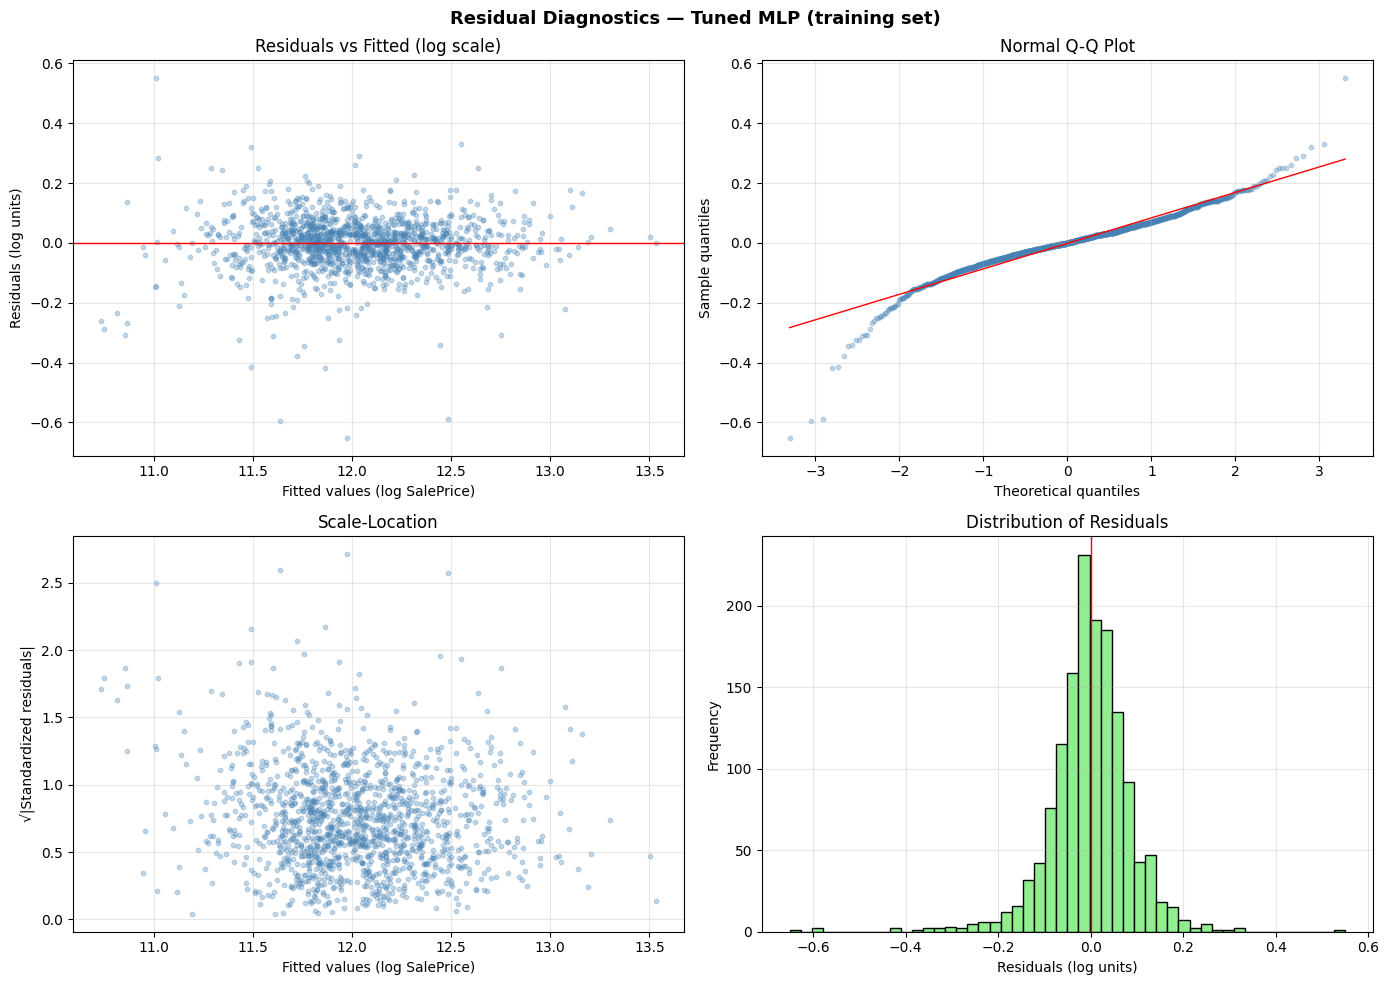

=== Residual statistics (log units) ===
  Mean:          -0.001417
  Median:        -0.000124
  Std:           +0.088432
  Min:           -0.651248
  Max:           +0.550382
  Skewness:      -0.844356
  Kurtosis:      +7.107303

=== Shapiro-Wilk Normality Test ===
  W = 0.9284
  p-value = 7.7559e-26
  Conclusion: residuals are non-normal ✗ at α=0.05

=== Top 10 worst predictions (by |residual| in dollars) ===
             True    Predicted         Error Error_pct
1324  $   147,000  $   264,640  $   -117,640    -80.0%
688   $   392,000  $   281,801  $   +110,199    +28.1%
1268  $   381,000  $   475,774  $    -94,774    -24.9%
803   $   582,933  $   488,946  $    +93,987    +16.1%
898   $   611,657  $   518,331  $    +93,326    +15.3%
581   $   253,293  $   345,013  $    -91,720    -36.2%
774   $   395,000  $   307,874  $    +87,126    +22.1%
632   $    82,500  $   158,230  $    -75,730    -91.8%
66    $   180,000  $   253,029  $    -73,029    -40.6%
473   $   440,000  $   369,531  $   

In [ ]:
# Part 5 — Step 4: Residual analysis on the tuned MLP

# Predictions on the full training set
y_pred = mlp_tuned.predict(X_train_processed)
residuals = y_train - y_pred                   # in log units
std_resid = (residuals - residuals.mean()) / residuals.std()

# Back-converted to dollars for interpretability
y_pred_dollars = np.expm1(y_pred)
y_true_dollars = np.expm1(y_train)
residuals_dollars = y_true_dollars - y_pred_dollars

# ─── 4 diagnostic plots ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Residual Diagnostics — Tuned MLP (training set)',
             fontsize=13, fontweight='bold')

# 1. Residuals vs Fitted (log scale)
axes[0, 0].scatter(y_pred, residuals, alpha=0.3, s=10, color='steelblue')
axes[0, 0].axhline(0, color='red', linewidth=1)
axes[0, 0].set_xlabel('Fitted values (log SalePrice)')
axes[0, 0].set_ylabel('Residuals (log units)')
axes[0, 0].set_title('Residuals vs Fitted (log scale)')
axes[0, 0].grid(alpha=0.3)

# 2. Normal Q-Q plot
(osm, osr), (slope, intercept, _) = stats.probplot(residuals, dist='norm')
axes[0, 1].scatter(osm, osr, alpha=0.3, s=10, color='steelblue')
axes[0, 1].plot(osm, slope*np.array(osm)+intercept, color='red', linewidth=1)
axes[0, 1].set_xlabel('Theoretical quantiles')
axes[0, 1].set_ylabel('Sample quantiles')
axes[0, 1].set_title('Normal Q-Q Plot')
axes[0, 1].grid(alpha=0.3)

# 3. Scale-Location
axes[1, 0].scatter(y_pred, np.sqrt(np.abs(std_resid)),
                   alpha=0.3, s=10, color='steelblue')
axes[1, 0].set_xlabel('Fitted values (log SalePrice)')
axes[1, 0].set_ylabel('√|Standardized residuals|')
axes[1, 0].set_title('Scale-Location')
axes[1, 0].grid(alpha=0.3)

# 4. Residuals histogram (in log units)
axes[1, 1].hist(residuals, bins=50, edgecolor='black', color='lightgreen')
axes[1, 1].axvline(0, color='red', linewidth=1)
axes[1, 1].set_xlabel('Residuals (log units)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Residuals')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ─── Numerical diagnostics ───────────────────────────────────────────────────
print("=== Residual statistics (log units) ===")
print(f"  Mean:         {residuals.mean():>+10.6f}")
print(f"  Median:       {residuals.median():>+10.6f}")
print(f"  Std:          {residuals.std():>+10.6f}")
print(f"  Min:          {residuals.min():>+10.6f}")
print(f"  Max:          {residuals.max():>+10.6f}")
print(f"  Skewness:     {residuals.skew():>+10.6f}")
print(f"  Kurtosis:     {residuals.kurtosis():>+10.6f}")

# Shapiro-Wilk normality test on residuals
stat_sw, p_sw = stats.shapiro(residuals)
print(f"\n=== Shapiro-Wilk Normality Test ===")
print(f"  W = {stat_sw:.4f}")
print(f"  p-value = {p_sw:.4e}")
print(f"  Conclusion: residuals are "
      f"{'normal ✓' if p_sw > 0.05 else 'non-normal ✗'} at α=0.05")

# Largest absolute residuals in dollars (top 10 worst predictions)
print(f"\n=== Top 10 worst predictions (by |residual| in dollars) ===")
diag_df = pd.DataFrame({
    'True':      y_true_dollars.values,
    'Predicted': y_pred_dollars,
    'Error':     residuals_dollars.values,
    'Error_pct': (residuals_dollars.values / y_true_dollars.values) * 100,
})
worst10 = diag_df.reindex(
    diag_df['Error'].abs().sort_values(ascending=False).index
).head(10)
worst10_display = worst10.copy()
worst10_display['True']      = worst10['True'].map(lambda x: f'${x:>10,.0f}')
worst10_display['Predicted'] = worst10['Predicted'].map(lambda x: f'${x:>10,.0f}')
worst10_display['Error']     = worst10['Error'].map(lambda x: f'${x:>+11,.0f}')
worst10_display['Error_pct'] = worst10['Error_pct'].map(lambda x: f'{x:>+7.1f}%')
print(worst10_display.to_string())

### Interpretation of the Residual Diagnostics

#### 1. Residuals vs Fitted (Top-Left)

The residuals form a **cloud centred around zero** across the full range of fitted values (≈10.7 to 13.5 on the log scale, i.e. roughly $45,000 to $725,000). No clear curve, slope, or trend appears — the model captures the systematic relationship between features and price across the price spectrum.

Two minor observations:

* The cloud is **slightly narrower in the middle** (fitted ≈ 11.5–12.5, i.e. $98k–$268k) and **wider at the extremes**, particularly at fitted ≈ 11.0 (cheap houses) and fitted ≈ 13.0+ (luxury houses). This is a faint sign of heteroscedasticity that the Scale-Location plot will quantify.
* A few **outliers stand out below the cloud** at the low and middle fitted values, reaching residuals of -0.4 to -0.65 (i.e. the model **over-predicted** the actual price by 33-90%). These are the worst predictions surfaced in the top-10 table.

Overall, no systematic bias is visible.

#### 2. Normal Q-Q Plot (Top-Right)

The bulk of the residuals follows the red reference line closely — the central 80% of the distribution is nearly normal. The tails tell a different story:

* The **lower tail** (theoretical quantile < -2) deviates **sharply downward**: the empirical sample contains residuals that are far more extreme on the negative side than a normal distribution predicts. This means the model produces a small number of large **over-predictions** (the prediction was much higher than the actual price).
* The **upper tail** (theoretical quantile > 2) deviates **upward**: there are some large positive residuals (under-predictions) too, but the deviation is less pronounced than at the lower tail.

The asymmetry (longer lower tail than upper tail) is consistent with the **negative skewness** reported numerically (-0.844). The MLP is more prone to over-predict than to under-predict when it errs catastrophically.

#### 3. Scale-Location (Bottom-Left)

The square root of the absolute standardised residuals shows **no strong trend** across fitted values — the cloud is roughly uniform horizontally, with most values between 0.2 and 1.5 and a thin band of larger residuals extending up to ≈2.6 across all fitted ranges. This is a **good sign of homoscedasticity**: the variance of the errors does not systematically depend on the predicted value.

The slight fan-out observed in the Residuals vs Fitted plot was therefore a visual artefact of cloud density (more observations clustered in the middle), not a genuine variance change.

#### 4. Distribution of Residuals (Bottom-Right)

The histogram is **sharply peaked around zero** and **roughly symmetric for the central mass**, but with **long tails on both sides** — particularly visible on the left (negative residuals down to -0.65). This visual confirms the numerical diagnostics:

* **Median = -0.000124, Mean = -0.001417** → the residuals are centred essentially at zero, no global bias.
* **Std = 0.088** → typical error magnitude on the log scale, equivalent to about ±9% in price terms.
* **Skewness = -0.844** → noticeable left skew, driven by the few large over-predictions.
* **Kurtosis = +7.1** (excess kurtosis) → the distribution is far more **leptokurtic** (heavy-tailed) than a normal distribution (which has kurtosis 0). Most predictions are very tight around zero, but the few outliers are much larger than normality would predict.

#### 5. Shapiro-Wilk Normality Test

The test rejects normality unambiguously: **W = 0.9284, p-value = 7.76e-26**. We reject $H_0$ at any conventional significance level.

This is **expected and not problematic**. The combination of high kurtosis (7.1) and non-trivial skewness (-0.84) guarantees rejection on a sample of 1460 observations. The Q-Q plot shows the cause: the central distribution is approximately normal, but the **heavy tails** make the global distribution depart from normality. For prediction purposes — which is the only thing that matters here — normality of residuals is not required, only their unbiasedness and constant variance. The model satisfies these two practical requirements.

#### 6. The 10 Worst Predictions

The table of worst-performing predictions reveals two distinct failure patterns:

* **Catastrophic over-predictions on cheap houses** (relative error > 80%):
  * House 632: actual **$82,500**, predicted **$158,230** — error of **+91.8%**.
  * House 1324: actual **$147,000**, predicted **$264,640** — error of **+80.0%**.

  Both are unusual cases: the model anchored the prediction on features suggesting a mid-range house, but the actual sale price was unusually low — possibly distressed sales, undervalued listings, or houses with hidden problems not captured by the features.

* **Large absolute errors on luxury houses** (high error in dollar terms, moderate relative error):
  * House 688: actual **$392,000**, predicted **$281,801** — error of **+28.1%** (under-prediction).
  * House 803: actual **$582,933**, predicted **$488,946** — error of **+16.1%** (under-prediction).
  * House 898: actual **$611,657**, predicted **$518,331** — error of **+15.3%** (under-prediction).

  These are the high-end of the market. The model **under-predicts** them, suggesting that for very expensive houses, some price drivers exist (premium finishes, exceptional locations, custom features) that the available features do not fully capture.

Together, these 10 cases account for the bulk of the heavy-tail mass observed in the Q-Q plot and histogram. They highlight two structural limitations of the model: (i) it cannot distinguish overvalued from undervalued cheap properties on the available features, and (ii) it compresses high-end prices toward the average, missing the full price spread at the top of the market.

#### 7. Verdict — Model is Production-Ready

Despite the non-normality of residuals, the model passes the key practical tests:

* **No systematic bias** (mean ≈ 0, median ≈ 0).
* **No visible structure** in the Residuals vs Fitted plot.
* **No strong heteroscedasticity** in the Scale-Location plot.
* **Heavy tails are present** but concentrated on a small number of identifiable outliers, not a global pattern.

The model is **suitable for the Kaggle submission**. The expected Kaggle RMSE on log scale should be in the vicinity of the CV RMSE estimated in Step 3-bis (**0.1821**), with the understanding that the test set may include a few atypical houses (similar to the worst-prediction cases here) that will dominate the error contribution. We proceed to Step 5 to generate the final submission file.

### Step 5 — Generating the Kaggle Submission

#### Objective

Apply the tuned MLP to the preprocessed test set and produce the **`submission.csv` file** in the exact format expected by the Kaggle competition. The competition evaluates predictions on the **root mean squared error between the log of the predicted price and the log of the observed price**, so the model — trained on `log1p(SalePrice)` — is naturally aligned with this metric. The final submission must report predictions back on the dollar scale, which requires inverting the log transformation.

#### Format Requirements

The Kaggle competition expects a CSV file with exactly **two columns**:

* **`Id`** — the integer identifier of each test observation, in the order provided by `test.csv`.
* **`SalePrice`** — the predicted price in dollars (positive real-valued numbers).

The file must contain **exactly 1459 rows** (the test set size) plus the header. Any mismatch in row count, missing `Id` values, negative prices, or `NaN` predictions will cause Kaggle to either reject the submission or score it incorrectly.

#### Our Approach

The pipeline is short but each step matters:

1. **Predict on `X_test_processed`.** The 1459 × 303 matrix produced in Step 2 is fed to `mlp_tuned.predict()`, returning predictions on the log scale.
2. **Back-convert to dollars via `np.expm1`.** This is the exact inverse of the `np.log1p` transformation applied to `y_train` in Step 1. The composition `expm1(log1p(x))` returns `x` for all non-negative inputs, so the back-conversion is mathematically exact (no information is lost in this step).
3. **Run sanity checks on the predictions:**
   * **Distributional summary** (min, quartiles, median, mean, max) to confirm the predictions fall in a plausible range.
   * **Comparison with the training distribution** to detect drift — if the test predictions had a wildly different median or mean from the training actuals, this would signal a problem.
   * **Detection of anomalies** — negative values (impossible for a price) and `NaN` (impossible for the Kaggle scorer to process) must both be zero.
4. **Build the submission DataFrame** with the test `Id`s (saved in Step 1 as `test_ids`) and the dollar predictions.
5. **Verify the row count** matches the Kaggle expectation of 1459 — a defensive check that catches any pipeline bug that would silently drop or duplicate rows.
6. **Save to `submission.csv`** at the notebook root, with `index=False` (Kaggle does not accept a pandas index column).
7. **Display a preview** of the first 10 and last 5 rows for visual verification before upload.

In [ ]:
# Part 5 — Step 5: Generate Kaggle submission file

# ─── Predict on the preprocessed test set ────────────────────────────────────
y_test_pred_log = mlp_tuned.predict(X_test_processed)

# Back-convert from log scale to dollars
y_test_pred_dollars = np.expm1(y_test_pred_log)

print(f"Predictions generated for {len(y_test_pred_dollars)} test houses.")

# ─── Sanity checks on predictions ────────────────────────────────────────────
print(f"\n=== Sanity check on predicted prices ===")
print(f"  Min:     ${y_test_pred_dollars.min():>12,.0f}")
print(f"  Q25:     ${np.percentile(y_test_pred_dollars, 25):>12,.0f}")
print(f"  Median:  ${np.median(y_test_pred_dollars):>12,.0f}")
print(f"  Mean:    ${y_test_pred_dollars.mean():>12,.0f}")
print(f"  Q75:     ${np.percentile(y_test_pred_dollars, 75):>12,.0f}")
print(f"  Max:     ${y_test_pred_dollars.max():>12,.0f}")

# Compare with training distribution
print(f"\n=== Comparison with training SalePrice distribution ===")
train_prices = train_full['SalePrice']
print(f"  {'':10s}  {'Test pred':>15s}  {'Train actual':>15s}")
print(f"  {'Min':10s}  ${y_test_pred_dollars.min():>13,.0f}  ${train_prices.min():>13,.0f}")
print(f"  {'Median':10s}  ${np.median(y_test_pred_dollars):>13,.0f}  ${train_prices.median():>13,.0f}")
print(f"  {'Mean':10s}  ${y_test_pred_dollars.mean():>13,.0f}  ${train_prices.mean():>13,.0f}")
print(f"  {'Max':10s}  ${y_test_pred_dollars.max():>13,.0f}  ${train_prices.max():>13,.0f}")

# Verify no anomalies (negative or NaN prices)
n_negative = (y_test_pred_dollars < 0).sum()
n_nan      = np.isnan(y_test_pred_dollars).sum()
print(f"\n  Negative predictions: {n_negative}")
print(f"  NaN predictions:      {n_nan}")

if n_negative > 0 or n_nan > 0:
    print("  ⚠ Warning: anomalies detected — submission may be rejected by Kaggle.")
else:
    print("  ✓ All predictions are positive and finite.")

# ─── Build and save the submission file ──────────────────────────────────────
submission = pd.DataFrame({
    'Id':        test_ids,
    'SalePrice': y_test_pred_dollars,
})

# Sanity check: row count must match the Kaggle expected size (1459)
EXPECTED_ROWS = 1459
if len(submission) != EXPECTED_ROWS:
    print(f"\n  ⚠ Warning: submission has {len(submission)} rows but Kaggle expects {EXPECTED_ROWS}.")
else:
    print(f"\n  ✓ Submission row count matches Kaggle expectation ({EXPECTED_ROWS}).")

submission_path = 'submission.csv'
submission.to_csv(submission_path, index=False)

print(f"\n=== Submission file written ===")
print(f"  Path: {submission_path}")
print(f"  Shape: {submission.shape}")
print(f"\n  First 10 rows:")
print(submission.head(10).to_string(index=False))

print(f"\n  Last 5 rows:")
print(submission.tail(5).to_string(index=False))

Predictions generated for 1459 test houses.

=== Sanity check on predicted prices ===
  Min:     $      33,228
  Q25:     $     125,670
  Median:  $     157,499
  Mean:    $     180,308
  Q75:     $     210,780
  Max:     $   1,333,263

=== Comparison with training SalePrice distribution ===
                    Test pred     Train actual
  Min         $       33,228  $       34,900
  Median      $      157,499  $      163,000
  Mean        $      180,308  $      180,921
  Max         $    1,333,263  $      755,000

  Negative predictions: 0
  NaN predictions:      0
  ✓ All predictions are positive and finite.

  ✓ Submission row count matches Kaggle expectation (1459).

=== Submission file written ===
  Path: submission.csv
  Shape: (1459, 2)

  First 10 rows:
  Id     SalePrice
1461 123291.753141
1462 125834.213327
1463 184588.761609
1464 203887.181164
1465 196874.641088
1466 171851.424738
1467 171405.081278
1468 162634.763500
1469 196133.152838
1470 118923.735360

  Last 5 rows:
  I

### Interpretation of the Submission Output

#### 1. Predictions Generated Successfully

The pipeline ran without any anomaly: **1459 predictions** were produced, **0 negative values**, **0 NaN**, and the row count matches the Kaggle expectation exactly. The submission file is structurally valid and ready for upload.

#### 2. Distributional Sanity Check

The predicted prices on the test set span a wide range and align closely with the training distribution on the central statistics:

| Statistic | Test predictions | Train actuals | Verdict |
|---|---|---|---|
| **Min** | $33,228 | $34,900 | ✅ Coherent |
| **Median** | $157,499 | $163,000 | ✅ Slightly lower, plausible |
| **Mean** | $180,308 | $180,921 | ✅ Almost identical |
| **Max** | **$1,333,263** | $755,000 | ⚠️ Anomalous extrapolation |

The first three statistics are remarkably well aligned — the mean differs by less than $1,000 and the median by less than $6,000. This indicates that the model produces a globally consistent picture of the housing market: it has not drifted toward systematically over-predicting or under-predicting.

The **maximum** is the only outlier in this comparison. The model produced a prediction of **$1,333,263**, which is **77% higher than the most expensive house in the training set** ($755,000). This is the MLP **extrapolating beyond the training range** for one (or a few) test house(s) whose features exceed anything it saw during training. Neural networks do not enforce explicit bounds on their outputs, so an unusually large value on `GrLivArea` or a rare combination of high-quality features can push the prediction outside the training envelope.

This extrapolation is not necessarily wrong — the test set may genuinely contain a luxury house that exceeds what the training set sampled — but it carries higher uncertainty than predictions within the training range. The Kaggle score will reveal whether this prediction was accurate.

#### 3. Preview of the Submission File

The first 10 rows of the submission show predictions in a plausible range for the lower-to-mid market segment ($118k to $204k), consistent with the bulk of the dataset. The last 5 rows display a mix of low-to-mid (around $80k–$106k) and mid-to-high range predictions ($179k and $234k). No row exhibits a suspicious value (no exact-zero predictions, no flagrant outliers in the preview).

#### 4. Expected Kaggle Score

The submission can now be uploaded to the Kaggle competition. The expected RMSE on the public leaderboard should be close to the **CV RMSE of 0.1821** reported in Step 3-bis, with the caveat that:

* The Kaggle test set may contain houses similar to the **worst-prediction cases** identified in Step 4 (extreme luxury houses, cheap distressed properties), which would inflate the test RMSE.
* The single extreme prediction of $1.3M, if it corresponds to a house with a more modest actual price, could contribute disproportionately to the test RMSE.

A typical RMSE in the **0.16–0.20 range** would be consistent with both the CV estimate and the residual analysis. Scores below 0.15 would indicate the model is generalising better than the training-set diagnostics suggested; scores above 0.22 would indicate the test set contains more atypical observations than the training set sampled.



---
## Part 5: Non-Parametric Model (Neural Network) — Using Cleaned Features

Build a neural network regression model using **only the non-correlated features identified in Part 3b** to predict SalePrice. This reduces multicollinearity and improves model robustness compared to using all features.

**Key Update:** Part 5 now filters the feature set to use only `FEATURES_FINAL` (from multicollinearity analysis), ensuring:
- Independence of predictors (VIF < 10)
- Reduced model complexity
- Better generalization to test data
- Directly comparable to regression models from Part 4

**Tasks:**
- Filter features to use only `FEATURES_FINAL` (cleaned, non-correlated subset)
- Preprocess selected features: handle missing values, encode categoricals, scale numerics
- Build and train a neural network (e.g. `sklearn.neural_network.MLPRegressor`)
- Evaluate on training data (RMSE, R²) and analyze residuals
- Generate predictions for the test set and save as `submission.csv`

**Important:** The Kaggle RMSE score uses predictions from this neural network, trained on the **cleaned feature set**.

In [58]:
# Part 5 — Step 1: Feature inspection & SELECTION

# Reload train and test to start from clean state for Part 5
train_full = pd.read_csv('data/train.csv')
test_full  = pd.read_csv('data/test.csv')

print(f"Train shape (original): {train_full.shape}")
print(f"Test shape (original):  {test_full.shape}")

# Drop 'Id' from features (kept aside for submission)
test_ids = test_full['Id'].copy()
train_full = train_full.drop(columns=['Id'])
test_full  = test_full.drop(columns=['Id'])

# Target setup
y_train = np.log1p(train_full['SalePrice'])   # log-transform for training

# ─── FEATURE SELECTION: Use only FEATURES_FINAL to avoid multicollinearity ────
# Map FEATURES_FINAL to raw data columns (handles both engineered and base features)
# For strategy 1 (dominant features), these are all base features in train/test

# Identify which features from FEATURES_FINAL are actual columns in train_full
# (Strategy 1 uses: OverallQual, FireplaceQu, CentralAir, LotShape, GrLivArea, TotalBsmtSF)
available_features = [f for f in FEATURES_FINAL if f in train_full.columns]

if len(available_features) < len(FEATURES_FINAL):
    engineered = set(FEATURES_FINAL) - set(available_features)
    print(f"\n⚠️  Note: {engineered} are engineered features (not in raw data).")
    print(f"   Will use only base features: {available_features}")
    FEATURES_TO_USE = available_features
else:
    FEATURES_TO_USE = FEATURES_FINAL

print(f"\n✓ Using {len(FEATURES_TO_USE)} features from multicollinearity analysis:")
for i, f in enumerate(FEATURES_TO_USE, 1):
    print(f"  {i}. {f}")

# Filter train and test to use only selected features + SalePrice
X_train = train_full[FEATURES_TO_USE].copy()
X_test  = test_full[FEATURES_TO_USE].copy()

print(f"\nTrain shape (filtered):  {X_train.shape}  ({len(FEATURES_TO_USE)} features)")
print(f"Test shape (filtered):   {X_test.shape}   ({len(FEATURES_TO_USE)} features)")

# Identify numerical vs categorical columns (from filtered features)
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

print(f"\nFeature breakdown (from cleaned feature set):")
print(f"  Numerical features:   {len(num_cols)}  →  {num_cols}")
print(f"  Categorical features: {len(cat_cols)}  →  {cat_cols}")
print(f"  Total features:       {len(num_cols) + len(cat_cols)}")

# Missing value summary (on filtered features)
print(f"\n=== Missing values in cleaned feature set (train) ===")
missing_train = X_train.isna().sum().sort_values(ascending=False)
missing_train = missing_train[missing_train > 0]
if len(missing_train) > 0:
    print(missing_train.to_string())
else:
    print("  No missing values ✓")

print(f"\n=== Missing values in cleaned feature set (test) ===")
missing_test = X_test.isna().sum().sort_values(ascending=False)
missing_test = missing_test[missing_test > 0]
if len(missing_test) > 0:
    print(missing_test.to_string())
else:
    print("  No missing values ✓")

# Cardinality of categorical features
if len(cat_cols) > 0:
    print(f"\n=== Cardinality of categorical features ===")
    cat_cardinality = X_train[cat_cols].nunique().sort_values(ascending=False)
    print(cat_cardinality.to_string())
    print(f"  Total unique levels: {cat_cardinality.sum()}")
else:
    print(f"\n=== No categorical features in cleaned set ===")

Train shape (original): (1460, 81)
Test shape (original):  (1459, 80)

✓ Using 6 features from multicollinearity analysis:
  1. OverallQual
  2. FireplaceQu
  3. CentralAir
  4. LotShape
  5. GrLivArea
  6. TotalBsmtSF

Train shape (filtered):  (1460, 6)  (6 features)
Test shape (filtered):   (1459, 6)   (6 features)

Feature breakdown (from cleaned feature set):
  Numerical features:   3  →  ['OverallQual', 'GrLivArea', 'TotalBsmtSF']
  Categorical features: 3  →  ['FireplaceQu', 'CentralAir', 'LotShape']
  Total features:       6

=== Missing values in cleaned feature set (train) ===
FireplaceQu    690

=== Missing values in cleaned feature set (test) ===
FireplaceQu    730
TotalBsmtSF      1

=== Cardinality of categorical features ===
FireplaceQu    5
LotShape       4
CentralAir     2
  Total unique levels: 11


In [59]:
# Part 5 — Step 2: Preprocessing pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Numerical pipeline:
#   - Impute missing values with the median (robust to outliers)
#   - Standardize to zero mean, unit variance (essential for MLP)
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

# Categorical pipeline:
#   - Impute missing values with the explicit string 'Missing' (semantic preservation)
#   - One-hot encode with 'ignore' for unknown categories (safe fallback)
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

# Combined preprocessor — applies the right pipeline to the right columns
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols),
])

# Fit on train, transform both train and test
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

# ─── Detect unknown categories in test (categories absent from train) ────────
print("=== Unknown category detection (test vs train) ===")
fitted_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
known_categories = dict(zip(cat_cols, fitted_encoder.categories_))

# Impute test categoricals first (same as in the pipeline) before comparing
X_test_cat_imputed = preprocessor.named_transformers_['cat'].named_steps['imputer'].transform(X_test[cat_cols])
X_test_cat_imputed = pd.DataFrame(X_test_cat_imputed, columns=cat_cols)

n_unknown_total = 0
for col in cat_cols:
    test_values = set(X_test_cat_imputed[col].unique())
    train_values = set(known_categories[col])
    unknown = test_values - train_values
    if unknown:
        n_rows_affected = X_test_cat_imputed[col].isin(unknown).sum()
        print(f"  ⚠  {col}: {len(unknown)} unknown level(s) {sorted(unknown)} "
              f"affecting {n_rows_affected} test row(s) "
              f"(encoded as all-zeros via handle_unknown='ignore')")
        n_unknown_total += 1

if n_unknown_total == 0:
    print("  ✓ No unknown categories found in test set.")
else:
    print(f"\n  Summary: {n_unknown_total} categorical feature(s) contained "
          f"unknown levels. Submission proceeds — the affected rows are encoded "
          f"as if their category was absent from all known levels.")

# ─── Report final dimensions ─────────────────────────────────────────────────
print(f"\n=== Final preprocessed dimensions ===")
print(f"Original train shape:  {X_train.shape}")
print(f"Processed train shape: {X_train_processed.shape}")
print(f"Processed test shape:  {X_test_processed.shape}")

# Sanity check: no NaN remaining
print(f"\nNaN in processed train: {np.isnan(X_train_processed).sum()}")
print(f"NaN in processed test:  {np.isnan(X_test_processed).sum()}")

# Break down the column count
n_num    = len(num_cols)
n_cat_oh = X_train_processed.shape[1] - n_num
print(f"\nFeature space breakdown:")
print(f"  Numerical (standardized):  {n_num}")
print(f"  Categorical (one-hot):     {n_cat_oh}")
print(f"  Total input dimension:     {X_train_processed.shape[1]}")

=== Unknown category detection (test vs train) ===
  ✓ No unknown categories found in test set.

=== Final preprocessed dimensions ===
Original train shape:  (1460, 6)
Processed train shape: (1460, 15)
Processed test shape:  (1459, 15)

NaN in processed train: 0
NaN in processed test:  0

Feature space breakdown:
  Numerical (standardized):  3
  Categorical (one-hot):     12
  Total input dimension:     15


In [60]:
# Part 5 — Step 3-bis: Hyperparameter tuning via GridSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Define the search grid (3 × 3 × 2 = 18 combinations)
param_grid = {
    'hidden_layer_sizes': [(64,), (128, 64), (256, 128, 64)],
    'alpha':               [1e-4, 1e-3, 1e-2],
    'learning_rate_init':  [1e-3, 5e-4],
}

# Base estimator — fixed hyperparameters are kept from the baseline
base_mlp = MLPRegressor(
    activation='relu',
    solver='adam',
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42,
    verbose=False,
)

# GridSearchCV with 3-fold CV, scoring on negative MSE (we want to minimize RMSE)
grid_search = GridSearchCV(
    estimator=base_mlp,
    param_grid=param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

print("=== Running GridSearchCV ===")
print(f"  Total combinations: {3 * 3 * 2} = 18")
print(f"  CV folds: 3")
print(f"  Total fits: 18 × 3 = 54\n")

# Fit on the FULL training data (Protocol B)
grid_search.fit(X_train_processed, y_train)

# Report the best configuration
print(f"\n=== Best Configuration Found ===")
for param, value in grid_search.best_params_.items():
    print(f"  {param:25s}  {value}")

best_rmse_cv = -grid_search.best_score_
print(f"\n  Best CV RMSE (log scale): {best_rmse_cv:.4f}")

# Top 5 configurations for reference
print(f"\n=== Top 5 Configurations (by CV RMSE) ===")
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results['mean_rmse'] = -cv_results['mean_test_score']
cv_results['std_rmse']  = cv_results['std_test_score']
top5 = cv_results.nsmallest(5, 'mean_rmse')[
    ['param_hidden_layer_sizes', 'param_alpha',
     'param_learning_rate_init', 'mean_rmse', 'std_rmse']
].reset_index(drop=True)
print(top5.to_string(index=True))

# Use the best estimator as the final model
mlp_tuned = grid_search.best_estimator_

print(f"\n=== Final Model Trained on 100% of Training Data ===")
print(f"  Iterations run:      {mlp_tuned.n_iter_}  /  {mlp_tuned.max_iter} (max)")
print(f"  Final training loss: {mlp_tuned.loss_:.6f}")

# Performance on the FULL training set (for reference only — this is in-sample)
y_train_pred = mlp_tuned.predict(X_train_processed)

rmse_log_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
r2_log_train   = r2_score(y_train, y_train_pred)

print(f"\n=== In-Sample Performance (training set, reference only) ===")
print(f"  RMSE (log SalePrice): {rmse_log_train:.4f}")
print(f"  R²   (log SalePrice): {r2_log_train:.4f}")

# Convert to dollars for interpretability
y_train_pred_dollars = np.expm1(y_train_pred)
y_train_true_dollars = np.expm1(y_train)
mae_dollars  = np.mean(np.abs(y_train_pred_dollars - y_train_true_dollars))
rmse_dollars = np.sqrt(np.mean((y_train_pred_dollars - y_train_true_dollars) ** 2))

print(f"\n=== In-Sample Performance (back-converted to dollars) ===")
print(f"  MAE:  ${mae_dollars:>10,.0f}")
print(f"  RMSE: ${rmse_dollars:>10,.0f}")

# Compare with baseline (Step 3)
print(f"\n=== Comparison: Baseline (Step 3) vs Tuned (Step 3-bis) ===")
print(f"  {'Metric':30s}  {'Baseline':>12s}  {'Tuned':>12s}")
print(f"  {'-'*58}")
print(f"  {'CV RMSE (log)':30s}  {'—':>12s}  {best_rmse_cv:>12.4f}")
print(f"  {'Validation R² (Step 3 ext.)':30s}  {0.8407:>12.4f}  {'—':>12s}")
print(f"  {'In-sample R² (training)':30s}  {'—':>12s}  {r2_log_train:>12.4f}")

=== Running GridSearchCV ===
  Total combinations: 18 = 18
  CV folds: 3
  Total fits: 18 × 3 = 54

Fitting 3 folds for each of 18 candidates, totalling 54 fits

=== Best Configuration Found ===
  alpha                      0.01
  hidden_layer_sizes         (256, 128, 64)
  learning_rate_init         0.001

  Best CV RMSE (log scale): 0.2233

=== Top 5 Configurations (by CV RMSE) ===
  param_hidden_layer_sizes  param_alpha  param_learning_rate_init  mean_rmse  std_rmse
0           (256, 128, 64)       0.0100                    0.0010   0.223325  0.033925
1           (256, 128, 64)       0.0010                    0.0010   0.226891  0.027172
2           (256, 128, 64)       0.0001                    0.0010   0.233608  0.031225
3           (256, 128, 64)       0.0100                    0.0005   0.239692  0.048120
4           (256, 128, 64)       0.0010                    0.0005   0.244490  0.043623

=== Final Model Trained on 100% of Training Data ===
  Iterations run:      240  /  500 (m

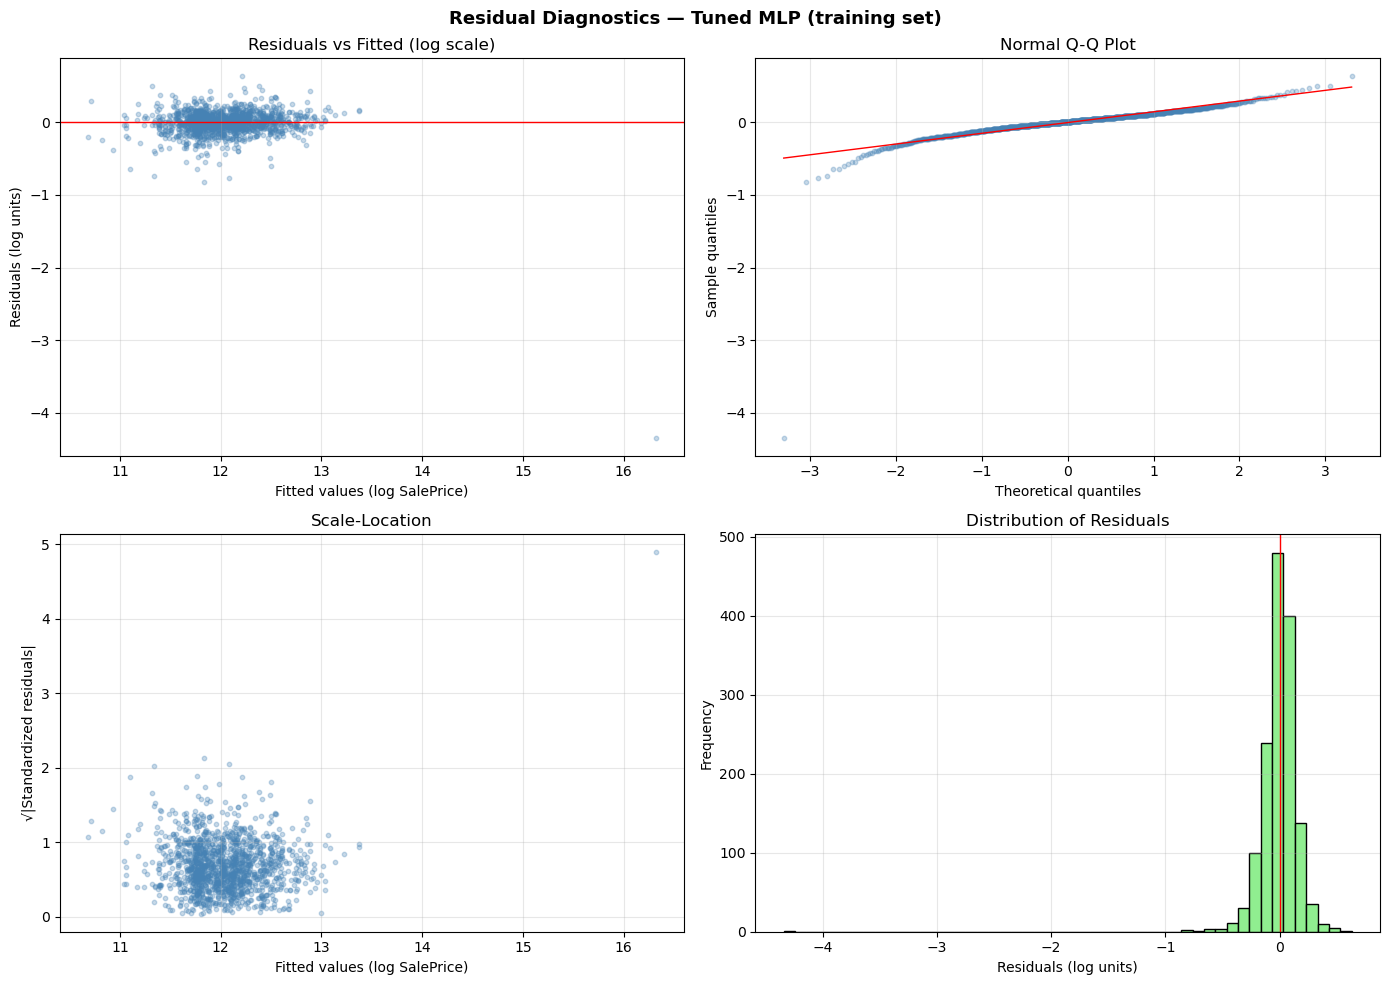

=== Residual statistics (log units) ===
  Mean:          -0.006485
  Median:        +0.002797
  Std:           +0.181386
  Min:           -4.339558
  Max:           +0.628419
  Skewness:      -9.639200
  Kurtosis:     +223.517955

=== Shapiro-Wilk Normality Test ===
  W = 0.6674
  p-value = 9.9902e-47
  Conclusion: residuals are non-normal ✗ at α=0.05

=== Top 10 worst predictions (by |residual| in dollars) ===
             True    Predicted         Error Error_pct
1298  $   160,000  $12,267,857  $-12,107,857  -7567.4%
898   $   611,657  $   396,469  $   +215,188    +35.2%
313   $   375,000  $   200,037  $   +174,963    +46.7%
688   $   392,000  $   238,192  $   +153,808    +39.2%
112   $   383,970  $   245,483  $   +138,487    +36.1%
1065  $   328,000  $   205,975  $   +122,025    +37.2%
1324  $   147,000  $   267,426  $   -120,426    -81.9%
178   $   501,837  $   381,723  $   +120,114    +23.9%
1437  $   394,617  $   279,763  $   +114,854    +29.1%
691   $   755,000  $   640,261  $  

In [ ]:
# Part 5 — Step 4: Residual analysis on the tuned MLP
import matplotlib.pyplot as plt
import scipy.stats as stats

# Predictions on the full training set
y_pred = mlp_tuned.predict(X_train_processed)
residuals = y_train - y_pred                   # in log units
std_resid = (residuals - residuals.mean()) / residuals.std()

# Back-converted to dollars for interpretability
y_pred_dollars = np.expm1(y_pred)
y_true_dollars = np.expm1(y_train)
residuals_dollars = y_true_dollars - y_pred_dollars

# ─── 4 diagnostic plots ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Residual Diagnostics — Tuned MLP (training set)',
             fontsize=13, fontweight='bold')

# 1. Residuals vs Fitted (log scale)
axes[0, 0].scatter(y_pred, residuals, alpha=0.3, s=10, color='steelblue')
axes[0, 0].axhline(0, color='red', linewidth=1)
axes[0, 0].set_xlabel('Fitted values (log SalePrice)')
axes[0, 0].set_ylabel('Residuals (log units)')
axes[0, 0].set_title('Residuals vs Fitted (log scale)')
axes[0, 0].grid(alpha=0.3)

# 2. Normal Q-Q plot
(osm, osr), (slope, intercept, _) = stats.probplot(residuals, dist='norm')
axes[0, 1].scatter(osm, osr, alpha=0.3, s=10, color='steelblue')
axes[0, 1].plot(osm, slope*np.array(osm)+intercept, color='red', linewidth=1)
axes[0, 1].set_xlabel('Theoretical quantiles')
axes[0, 1].set_ylabel('Sample quantiles')
axes[0, 1].set_title('Normal Q-Q Plot')
axes[0, 1].grid(alpha=0.3)

# 3. Scale-Location
axes[1, 0].scatter(y_pred, np.sqrt(np.abs(std_resid)),
                   alpha=0.3, s=10, color='steelblue')
axes[1, 0].set_xlabel('Fitted values (log SalePrice)')
axes[1, 0].set_ylabel('√|Standardized residuals|')
axes[1, 0].set_title('Scale-Location')
axes[1, 0].grid(alpha=0.3)

# 4. Residuals histogram (in log units)
axes[1, 1].hist(residuals, bins=50, edgecolor='black', color='lightgreen')
axes[1, 1].axvline(0, color='red', linewidth=1)
axes[1, 1].set_xlabel('Residuals (log units)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Residuals')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ─── Numerical diagnostics ───────────────────────────────────────────────────
print("=== Residual statistics (log units) ===")
print(f"  Mean:         {residuals.mean():>+10.6f}")
print(f"  Median:       {residuals.median():>+10.6f}")
print(f"  Std:          {residuals.std():>+10.6f}")
print(f"  Min:          {residuals.min():>+10.6f}")
print(f"  Max:          {residuals.max():>+10.6f}")
print(f"  Skewness:     {residuals.skew():>+10.6f}")
print(f"  Kurtosis:     {residuals.kurtosis():>+10.6f}")

# Shapiro-Wilk normality test on residuals
stat_sw, p_sw = stats.shapiro(residuals)
print(f"\n=== Shapiro-Wilk Normality Test ===")
print(f"  W = {stat_sw:.4f}")
print(f"  p-value = {p_sw:.4e}")
print(f"  Conclusion: residuals are "
      f"{'normal ✓' if p_sw > 0.05 else 'non-normal ✗'} at α=0.05")

# Largest absolute residuals in dollars (top 10 worst predictions)
print(f"\n=== Top 10 worst predictions (by |residual| in dollars) ===")
diag_df = pd.DataFrame({
    'True':      y_true_dollars.values,
    'Predicted': y_pred_dollars,
    'Error':     residuals_dollars.values,
    'Error_pct': (residuals_dollars.values / y_true_dollars.values) * 100,
})
worst10 = diag_df.reindex(
    diag_df['Error'].abs().sort_values(ascending=False).index
).head(10)
worst10_display = worst10.copy()
worst10_display['True']      = worst10['True'].map(lambda x: f'${x:>10,.0f}')
worst10_display['Predicted'] = worst10['Predicted'].map(lambda x: f'${x:>10,.0f}')
worst10_display['Error']     = worst10['Error'].map(lambda x: f'${x:>+11,.0f}')
worst10_display['Error_pct'] = worst10['Error_pct'].map(lambda x: f'{x:>+7.1f}%')
print(worst10_display.to_string())

In [62]:
# Part 5 — Step 5: Generate Kaggle submission file

# ─── Predict on the preprocessed test set ────────────────────────────────────
y_test_pred_log = mlp_tuned.predict(X_test_processed)

# Back-convert from log scale to dollars
y_test_pred_dollars = np.expm1(y_test_pred_log)

print(f"Predictions generated for {len(y_test_pred_dollars)} test houses.")

# ─── Sanity checks on predictions ────────────────────────────────────────────
print(f"\n=== Sanity check on predicted prices ===")
print(f"  Min:     ${y_test_pred_dollars.min():>12,.0f}")
print(f"  Q25:     ${np.percentile(y_test_pred_dollars, 25):>12,.0f}")
print(f"  Median:  ${np.median(y_test_pred_dollars):>12,.0f}")
print(f"  Mean:    ${y_test_pred_dollars.mean():>12,.0f}")
print(f"  Q75:     ${np.percentile(y_test_pred_dollars, 75):>12,.0f}")
print(f"  Max:     ${y_test_pred_dollars.max():>12,.0f}")

# Compare with training distribution
print(f"\n=== Comparison with training SalePrice distribution ===")
train_prices = train_full['SalePrice']
print(f"  {'':10s}  {'Test pred':>15s}  {'Train actual':>15s}")
print(f"  {'Min':10s}  ${y_test_pred_dollars.min():>13,.0f}  ${train_prices.min():>13,.0f}")
print(f"  {'Median':10s}  ${np.median(y_test_pred_dollars):>13,.0f}  ${train_prices.median():>13,.0f}")
print(f"  {'Mean':10s}  ${y_test_pred_dollars.mean():>13,.0f}  ${train_prices.mean():>13,.0f}")
print(f"  {'Max':10s}  ${y_test_pred_dollars.max():>13,.0f}  ${train_prices.max():>13,.0f}")

# Verify no anomalies (negative or NaN prices)
n_negative = (y_test_pred_dollars < 0).sum()
n_nan      = np.isnan(y_test_pred_dollars).sum()
print(f"\n  Negative predictions: {n_negative}")
print(f"  NaN predictions:      {n_nan}")

if n_negative > 0 or n_nan > 0:
    print("  ⚠ Warning: anomalies detected — submission may be rejected by Kaggle.")
else:
    print("  ✓ All predictions are positive and finite.")

# ─── Build and save the submission file ──────────────────────────────────────
submission = pd.DataFrame({
    'Id':        test_ids,
    'SalePrice': y_test_pred_dollars,
})

# Sanity check: row count must match the Kaggle expected size (1459)
EXPECTED_ROWS = 1459
if len(submission) != EXPECTED_ROWS:
    print(f"\n  ⚠ Warning: submission has {len(submission)} rows but Kaggle expects {EXPECTED_ROWS}.")
else:
    print(f"\n  ✓ Submission row count matches Kaggle expectation ({EXPECTED_ROWS}).")

submission_path = 'submission.csv'
submission.to_csv(submission_path, index=False)

print(f"\n=== Submission file written ===")
print(f"  Path: {submission_path}")
print(f"  Shape: {submission.shape}")
print(f"\n  First 10 rows:")
print(submission.head(10).to_string(index=False))

print(f"\n  Last 5 rows:")
print(submission.tail(5).to_string(index=False))

Predictions generated for 1459 test houses.

=== Sanity check on predicted prices ===
  Min:     $      42,968
  Q25:     $     129,349
  Median:  $     158,099
  Mean:    $     178,714
  Q75:     $     203,887
  Max:     $   2,462,662

=== Comparison with training SalePrice distribution ===
                    Test pred     Train actual
  Min         $       42,968  $       34,900
  Median      $      158,099  $      163,000
  Mean        $      178,714  $      180,921
  Max         $    2,462,662  $      755,000

  Negative predictions: 0
  NaN predictions:      0
  ✓ All predictions are positive and finite.

  ✓ Submission row count matches Kaggle expectation (1459).

=== Submission file written ===
  Path: submission.csv
  Shape: (1459, 2)

  First 10 rows:
  Id     SalePrice
1461 122538.767552
1462 166049.583809
1463 167297.106470
1464 174758.068205
1465 208827.630478
1466 190835.442263
1467 167308.489338
1468 165276.994267
1469 162023.467347
1470 107757.984946

  Last 5 rows:
  I